# part 1

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  quad = float(e.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)         # scalaire
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)        # scalaire


MLE success: True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
σ̂_e=0.04000 (true 0.04)
sigma_u_hat=1.00371 (true 1.0)
MSE(beta_hat, beta_true) = 0.018319


C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)


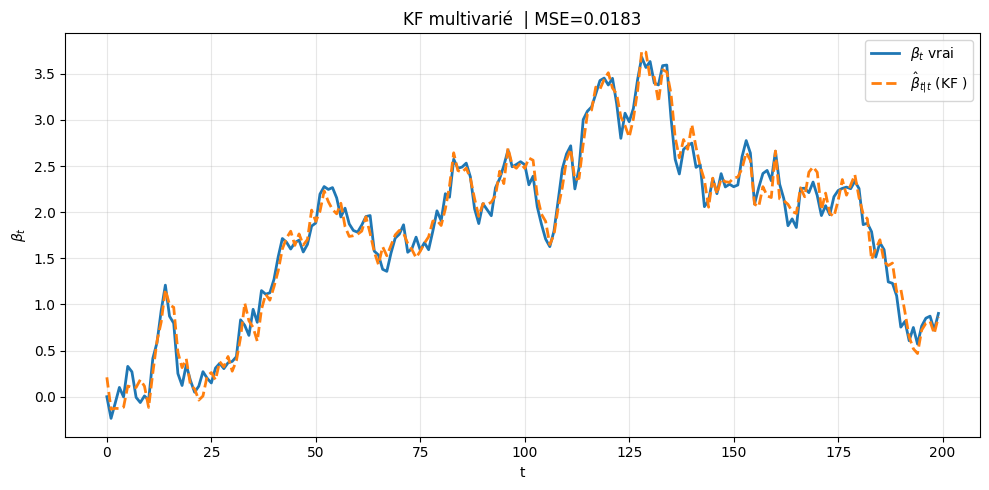

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================================
# 1) Kalman multivarié (obs vector y_t, état scalaire beta_t)
# ==========================================================

def kf_loglike_multivariate(Y_list, Q, su, beta0=0.0, P0=1e6):
    """
    Y_list: liste de vecteurs y_t (numpy array shape (N_t,))
    Modèle:
      beta_t = beta_{t-1} + xi_t,  xi_t ~ N(0,Q)
      y_t    = 1_{N_t} * beta_t + u_t, u_t ~ N(0, su^2 I_{N_t})

    Retour: log-vraisemblance (Kalman) multivariée
    """
    beta_pred = beta0
    P_pred = P0
    loglik = 0.0

    for y_t in Y_list:
        y_t = np.asarray(y_t)
        n = y_t.size

        H = np.ones((n, 1))              # (n x 1)
        R = (su**2) * np.eye(n)          # (n x n)

        # Innovation
        e = y_t.reshape(-1, 1) - H * beta_pred  # (n x 1)

        # S = H P H' + R  (n x n)
        S = P_pred * (H @ H.T) + R

        # log|S| + e' S^{-1} e
        sign, logdetS = np.linalg.slogdet(S)
        if sign <= 0:
            return -np.inf  # cas pathologique (devrait pas arriver si su>0)

        Sinv_e = np.linalg.solve(S, e)
        quad = float(e.T @ Sinv_e)

        loglik += -0.5 * (n * np.log(2*np.pi) + logdetS + quad)

        # Gain K = P H' S^{-1}   -> (1 x n)
        # beta_upd = beta_pred + K e
        # Ici, K e = P * H' * S^{-1} e
        He = float(H.T @ Sinv_e)         # scalaire
        beta_upd = beta_pred + P_pred * He

        # P_upd = P - P H' S^{-1} H P
        Sinv_H = np.linalg.solve(S, H)   # (n x 1)
        HSH = float(H.T @ Sinv_H)        # scalaire
        P_upd = P_pred - (P_pred**2) * HSH

        # Predict next
        beta_pred = beta_upd
        P_pred = P_upd + Q

    return loglik


def kf_filter_multivariate(Y_list, Q, su, beta0=0.0, P0=1e6):
    """
    Filtre KF multivarié -> renvoie beta_{t|t} et P_{t|t} pour t=1..T
    """
    T = len(Y_list)
    beta_filt = np.zeros(T)
    P_filt = np.zeros(T)

    beta_pred = beta0
    P_pred = P0

    for t, y_t in enumerate(Y_list):
        y_t = np.asarray(y_t)
        n = y_t.size

        H = np.ones((n, 1))
        R = (su**2) * np.eye(n)

        e = y_t.reshape(-1, 1) - H * beta_pred
        S = P_pred * (H @ H.T) + R

        Sinv_e = np.linalg.solve(S, e)
        He = float(H.T @ Sinv_e)
        beta_upd = beta_pred + P_pred * He

        Sinv_H = np.linalg.solve(S, H)
        HSH = float(H.T @ Sinv_H)
        P_upd = P_pred - (P_pred**2) * HSH

        beta_filt[t] = beta_upd
        P_filt[t] = P_upd

        beta_pred = beta_upd
        P_pred = P_upd + Q

    return beta_filt, P_filt


# ==========================================================
# 2) MLE (Q, sigma_u) via log-vraisemblance multivariée
# ==========================================================

def mle_multivariate_kf(Y_list, beta0=0.0, P0=1e6,
                        x0=(np.log(0.04), np.log(1.0))):
    """
    Estime directement :
        sigma_xi2 (variance d'état)
        sigma_v2  (variance observation)
    par MLE.

    Optimisation sur (log sigma_xi2, log sigma_v2)
    """

    def objective(params):
        log_sigma_xi2, log_sigma_v2 = params

        sigma_xi2 = np.exp(log_sigma_xi2)
        sigma_v2  = np.exp(log_sigma_v2)

        # su = sqrt(sigma_v2) car ton filtre prend l'écart-type
        su = np.sqrt(sigma_v2)

        ll = kf_loglike_multivariate(
            Y_list,
            Q=sigma_xi2,
            su=su,
            beta0=beta0,
            P0=P0
        )
        return -ll

    res = minimize(objective, np.array(x0), method="L-BFGS-B")

    log_sigma_xi2_hat, log_sigma_v2_hat = res.x

    return {
        "sigma_xi2_hat": float(np.exp(log_sigma_xi2_hat)),
        "sigma_v2_hat":  float(np.exp(log_sigma_v2_hat)),
        "success": bool(res.success),
        "message": res.message
    }


# ==========================================================
# 3) Exemple : simulation panel + estimation + filtre
# ==========================================================

if __name__ == "__main__":
    rng = np.random.default_rng(123)

    T = 200
    N_t = rng.integers(20, 61, size=T)  # panel potentiellement déséquilibré

    Q_true = 0.04
    su_true = 1.0

    # vrai beta_t (random walk)
    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0, np.sqrt(Q_true))

    # données individuelles Y_it : y_t = beta_t * 1 + u_t
    Y_list = []
    for t in range(T):
        n = int(N_t[t])
        u_t = rng.normal(0, su_true, size=n)
        y_t = beta_true[t] + u_t
        Y_list.append(y_t)

    # MLE multivariée
    fit = mle_multivariate_kf(Y_list)
    print("MLE success:", fit["success"], "|", fit["message"])
    print(f"σ̂_e={fit['sigma_xi2_hat']:.5f} (true {Q_true})")
    print(f"sigma_u_hat={fit['sigma_v2_hat']:.5f} (true {su_true})")

    # Filtre KF multivarié
    beta_hat, P_hat = kf_filter_multivariate(
    Y_list,
    fit["sigma_xi2_hat"],
    np.sqrt(fit["sigma_v2_hat"])
)


    mse = np.mean((beta_hat - beta_true)**2)
    print(f"MSE(beta_hat, beta_true) = {mse:.6f}")

    # Graphe
    plt.figure(figsize=(10,5))
    plt.plot(beta_true, label=r"$\beta_t$ vrai", linewidth=2)
    plt.plot(beta_hat, "--", label=r"$\hat\beta_{t|t}$ (KF )", linewidth=2)
    plt.xlabel("t")
    plt.ylabel(r"$\beta_t$")
    plt.title(f"KF multivarié  | MSE={mse:.4f}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [4]:
import numpy as np

def mc_bias_var_params(MC=200, T=120, Nmin=20, Nmax=60,
                       Q_true=0.04, su_true=1.0, seed=123):
    rng = np.random.default_rng(seed)

    Q_hats = []
    su_hats = []
    success = 0

    for _ in range(MC):
        N_t = rng.integers(Nmin, Nmax + 1, size=T)

        # beta vrai
        beta_true = np.zeros(T)
        for t in range(1, T):
            beta_true[t] = beta_true[t-1] + rng.normal(0, np.sqrt(Q_true))

        # panel Y_list
        Y_list = []
        for t in range(T):
            n = int(N_t[t])
            u_t = rng.normal(0, su_true, size=n)
            y_t = beta_true[t] + u_t
            Y_list.append(y_t)

        fit = mle_multivariate_kf(Y_list)
        if fit["success"]:
            success += 1
            Q_hats.append(fit["sigma_xi2_hat"])
            su_hats.append(fit["sigma_v2_hat"])

    Q_hats = np.array(Q_hats)
    su_hats = np.array(su_hats)

    # stats Monte Carlo
    out = {
        "MC_total": MC,
        "MC_success": success,
        "Q_mean": float(Q_hats.mean()),
        "Q_bias": float(Q_hats.mean() - Q_true),
        "Q_var": float(Q_hats.var(ddof=1)),
        "Q_mse": float(np.mean((Q_hats - Q_true)**2)),

        "su_mean": float(su_hats.mean()),
        "su_bias": float(su_hats.mean() - su_true),
        "su_var": float(su_hats.var(ddof=1)),
        "su_mse": float(np.mean((su_hats - su_true)**2)),
    }
    return out

# Exemple d'utilisation
stats = mc_bias_var_params(MC=500, T=200, Q_true=0.04, su_true=1.0)
print(stats)


C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  quad = float(e.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)         # scalaire
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)        # scalaire


{'MC_total': 500, 'MC_success': 497, 'Q_mean': 0.03959225723025003, 'Q_bias': -0.00040774276974996776, 'Q_var': 4.491789959741625e-05, 'Q_mse': 4.499377569609919e-05, 'su_mean': 0.9989059444913625, 'su_bias': -0.0010940555086375037, 'su_var': 0.0002524155117179703, 'su_mse': 0.00025310459088075517}


C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  quad = float(e.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)         # scalaire
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_19420\2525240889.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)        # scalaire



Statistiques globales pour beta :
     Metric     Value
0      Bias  0.000928
1  Variance  0.018264
2       MSE  0.018265
Nombre de réplications réussies : 497

Tableau global des paramètres :
        Paramètre  Valeur vraie   Moyenne     Biais  Variance       MSE
0  $\sigma_\xi^2$          0.04  0.039592 -0.000408  0.000045  0.000045
1    $\sigma_v^2$          1.00  0.998906 -0.001094  0.000252  0.000253

Premières lignes du tableau par date :
   t      Bias  Variance       MSE
0  1  0.013524  0.028106  0.028232
1  2 -0.009840  0.021589  0.021643
2  3  0.002244  0.017946  0.017915
3  4 -0.000278  0.019397  0.019358
4  5  0.010442  0.017489  0.017563


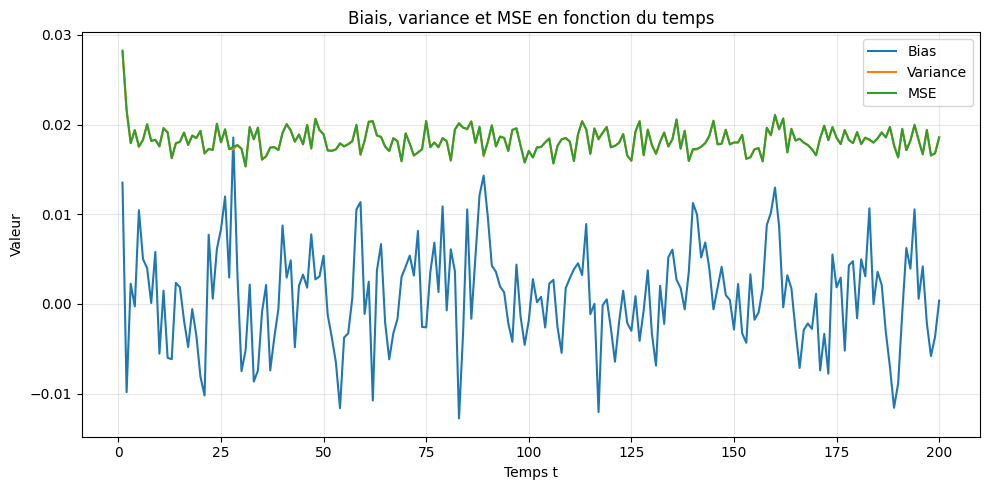

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def mc_bias_var_params_and_beta(
    mle_multivariate_kf,
    kf_filter_from_params,
    MC=200,
    T=120,
    Nmin=20,
    Nmax=60,
    Q_true=0.04,
    su_true=1.0,
    beta0=0.0,
    P0=1e6,
    seed=123,
):
    
    rng = np.random.default_rng(seed)

    Q_hats = []
    su_hats = []

    beta_true_all = []
    beta_hat_all = []

    success = 0

    for _ in range(MC):
        N_t = rng.integers(Nmin, Nmax + 1, size=T)

        # Génération du beta vrai
        beta_true = np.zeros(T)
        beta_true[0] = beta0
        for t in range(1, T):
            beta_true[t] = beta_true[t - 1] + rng.normal(0.0, np.sqrt(Q_true))

        # Génération du panel déséquilibré
        Y_list = []
        for t in range(T):
            n = int(N_t[t])
            u_t = rng.normal(0.0, np.sqrt(su_true), size=n)
            y_t = beta_true[t] + u_t
            Y_list.append(y_t)

        # Estimation des paramètres
        fit = mle_multivariate_kf(Y_list)
        if not fit.get("success", False):
            continue

        success += 1
        Q_hat = float(fit["sigma_xi2_hat"])
        su_hat = float(fit["sigma_v2_hat"])

        Q_hats.append(Q_hat)
        su_hats.append(su_hat)

        # Filtrage de beta_t avec paramètres estimés
        beta_hat = np.asarray(
            kf_filter_from_params(Y_list, Q_hat, su_hat, beta0=beta0, P0=P0),
            dtype=float
        )

        if beta_hat.shape[0] != T:
            raise ValueError(
                f"kf_filter_from_params doit retourner un array de taille T={T}, "
                f"mais a retourné {beta_hat.shape[0]}"
            )

        beta_true_all.append(beta_true)
        beta_hat_all.append(beta_hat)

    if success == 0:
        raise RuntimeError("Aucune réplication Monte Carlo n'a convergé.")

    Q_hats = np.asarray(Q_hats, dtype=float)
    su_hats = np.asarray(su_hats, dtype=float)

    beta_true_all = np.asarray(beta_true_all, dtype=float) # shape = (success, T)
    beta_hat_all = np.asarray(beta_hat_all, dtype=float) # shape = (success, T)

    # ------------------------------------------------------------------
    # 1) Tableau global des paramètres
    # ------------------------------------------------------------------
    param_table = pd.DataFrame({
        "Paramètre": [r"$\sigma_\xi^2$", r"$\sigma_v^2$"],
        "Valeur vraie": [Q_true, su_true],
        "Moyenne": [Q_hats.mean(), su_hats.mean()],
        "Biais": [Q_hats.mean() - Q_true, su_hats.mean() - su_true],
        "Variance": [Q_hats.var(ddof=1), su_hats.var(ddof=1)],
        "MSE": [np.mean((Q_hats - Q_true) ** 2), np.mean((su_hats - su_true) ** 2)],
    })

    # ------------------------------------------------------------------
    # 2) Métriques par date pour beta_hat_t
    # ------------------------------------------------------------------
    errors = beta_hat_all - beta_true_all # shape = (success, T)
    beta_bias_total = float(errors.mean())
    beta_var_total = float(errors.var(ddof=1))
    beta_mse_total = float(np.mean(errors**2))

    beta_bias_t = errors.mean(axis=0)
    beta_var_t = errors.var(axis=0, ddof=1)
    beta_mse_t = np.mean(errors ** 2, axis=0)

    beta_global_table = pd.DataFrame({
    "Metric": ["Bias", "Variance", "MSE"],
    "Value": [beta_bias_total, beta_var_total, beta_mse_total]
     })

    beta_time_table = pd.DataFrame({
        "t": np.arange(1, T + 1),
        "Bias": beta_bias_t,
        "Variance": beta_var_t,
        "MSE": beta_mse_t,
    })

    results = {
        "MC_total": MC,
        "MC_success": success,
        "param_table": param_table,
        "beta_time_table": beta_time_table,
        "Q_hats": Q_hats,
        "su_hats": su_hats,
        "beta_true_all": beta_true_all,
        "beta_hat_all": beta_hat_all,
    }
    results["beta_global"] = beta_global_table
    return results


def plot_beta_metrics_over_time(beta_time_table, title="Biais, variance et MSE en fonction du temps"):
    """
    Graphe unique avec Bias, Variance et MSE au cours du temps.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(beta_time_table["t"], beta_time_table["Bias"], label="Bias")
    plt.plot(beta_time_table["t"], beta_time_table["Variance"], label="Variance")
    plt.plot(beta_time_table["t"], beta_time_table["MSE"], label="MSE")
    plt.xlabel("Temps t")
    plt.ylabel("Valeur")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
def kf_filter_from_params(Y_list, Q_hat, su_hat, beta0=0.0, P0=1e6):
    T = len(Y_list)
    beta_hat = np.zeros(T)
    b, P = beta0, P0

    for t in range(T):
        y_t = np.asarray(Y_list[t], dtype=float)
        n = len(y_t)
        one = np.ones(n)

        # innovation
        v_t = y_t - one * b
        S_t = P * np.outer(one, one) + su_hat * np.eye(n)

        # gain (état scalaire)
        K_t = P * one @ np.linalg.inv(S_t)

        # update
        b = b + K_t @ v_t
        P = (1.0 - K_t @ one) * P

        beta_hat[t] = b

        # predict
        P = P + Q_hat

    return beta_hat
results = mc_bias_var_params_and_beta(
    mle_multivariate_kf=mle_multivariate_kf,
    kf_filter_from_params=kf_filter_from_params,
    MC=500,
    T=200,
    Nmin=20,
    Nmax=60,
    Q_true=0.04,
    su_true=1.0,
    seed=123,
)

print("\nStatistiques globales pour beta :")
print(results["beta_global"].round(6))
print("Nombre de réplications réussies :", results["MC_success"])
print("\nTableau global des paramètres :")
print(results["param_table"].round(6))

print("\nPremières lignes du tableau par date :")
print(results["beta_time_table"].head().round(6))

plot_beta_metrics_over_time(results["beta_time_table"])

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\264588608.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  quad = float(e.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\264588608.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)         # scalaire
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\264588608.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)        # scalaire
C:\Users\ReM

MC success: 297/300


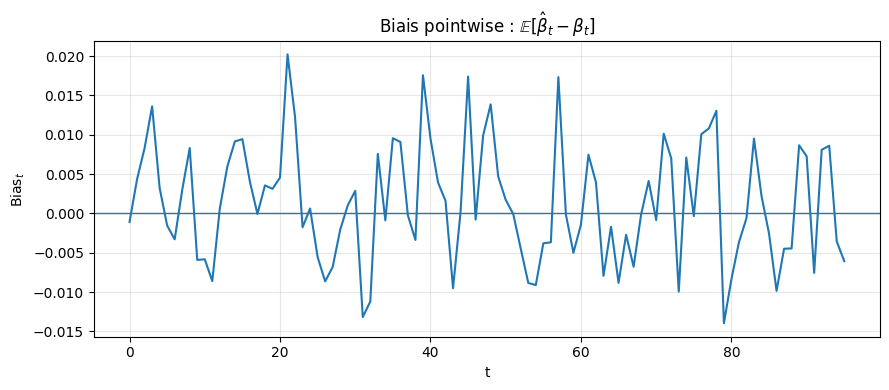

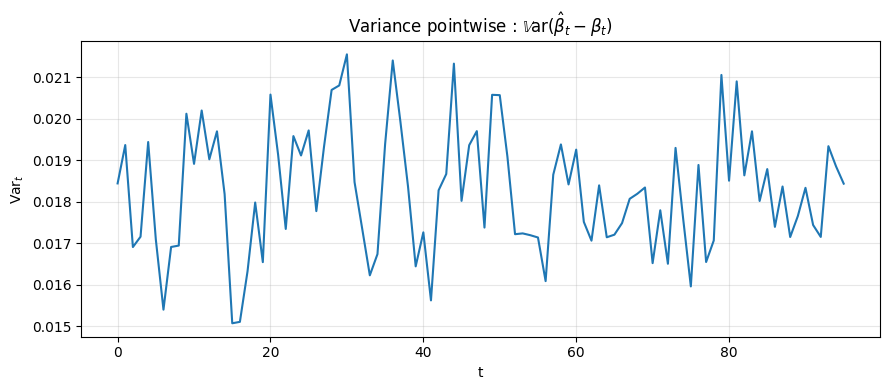

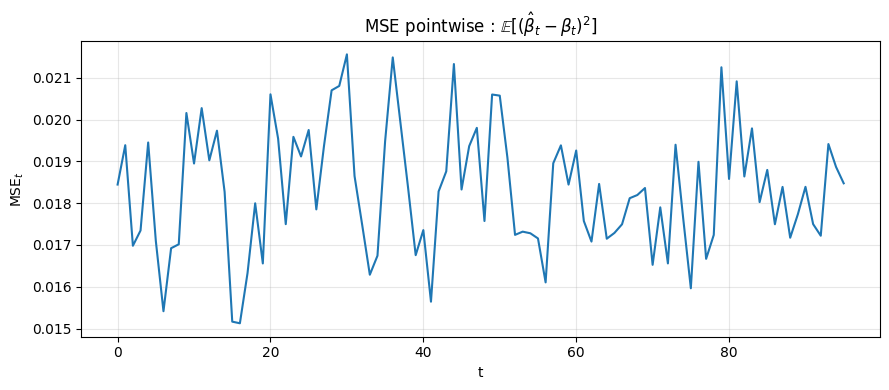

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_panel_list(T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng):
    N_t = rng.integers(Nmin, Nmax + 1, size=T)

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(sigma_xi2_true))

    Y_list = []
    for t in range(T):
        n = int(N_t[t])
        v = rng.normal(0.0, np.sqrt(sigma_v2_true), size=n)
        Y_list.append(beta_true[t] + v)

    return beta_true, Y_list


def mc_bias_var_beta(T=120, MC=300, Nmin=20, Nmax=60,
                     sigma_xi2_true=0.04, sigma_v2_true=1.0,
                     seed=123, burn_frac=0.0):
    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    # stocker les erreurs (MC x T)
    errors = np.zeros((MC, T))
    ok_count = 0

    for m in range(MC):
        beta_true, Y_list = simulate_panel_list(
            T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng
        )

        fit = mle_multivariate_kf(Y_list)   # doit retourner sigma_xi2_hat, sigma_v2_hat
        if not fit["success"]:
            # si ça rate, on saute cette réplication
            errors[m, :] = np.nan
            continue

        ok_count += 1
        xi2_hat = fit["sigma_xi2_hat"]
        v2_hat  = fit["sigma_v2_hat"]

        beta_hat, _ = kf_filter_multivariate(Y_list, Q=xi2_hat, su=np.sqrt(v2_hat))

        errors[m, :] = beta_hat - beta_true

    # garder seulement les runs OK
    errors_ok = errors[~np.isnan(errors).any(axis=1)]
    print(f"MC success: {errors_ok.shape[0]}/{MC}")

    # biais(t), variance(t), mse(t)
    bias_t = errors_ok.mean(axis=0)
    var_t  = errors_ok.var(axis=0, ddof=1)
    mse_t  = bias_t**2 + var_t

    # optionnel : enlever un burn-in pour l'affichage
    return bias_t[burn:], var_t[burn:], mse_t[burn:]


def plot_bias_var_mse(bias_t, var_t, mse_t):
    t = np.arange(len(bias_t))

    plt.figure(figsize=(9, 4))
    plt.plot(t, bias_t)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{Bias}_t$")
    plt.title(r"Biais pointwise : $\mathbb{E}[\hat\beta_t-\beta_t]$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(t, var_t)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{Var}_t$")
    plt.title(r"Variance pointwise : $\mathbb{V}\mathrm{ar}(\hat\beta_t-\beta_t)$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(t, mse_t)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{MSE}_t$")
    plt.title(r"MSE pointwise : $\mathbb{E}[(\hat\beta_t-\beta_t)^2]$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------- RUN ----------------
if __name__ == "__main__":
    bias_t, var_t, mse_t = mc_bias_var_beta(
        T=120, MC=300, Nmin=20, Nmax=60,
        sigma_xi2_true=0.04, sigma_v2_true=1.0,
        seed=123,
        burn_frac=0.2  # mets 0.0 si tu veux tout afficher
    )
    plot_bias_var_mse(bias_t, var_t, mse_t)


C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\759880188.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  quad = float(e.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\759880188.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)            # scalaire
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\759880188.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)           # scalaire


MLE success: True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
sigma_xi2_hat=0.03432 (true 0.04)
sigma_v2_hat =1.01515 (true 1.0)
MSE(beta_hat, beta_true) = 0.014876


C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\759880188.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  He = float(H.T @ Sinv_e)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_2688\759880188.py:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  HSH = float(H.T @ Sinv_H)


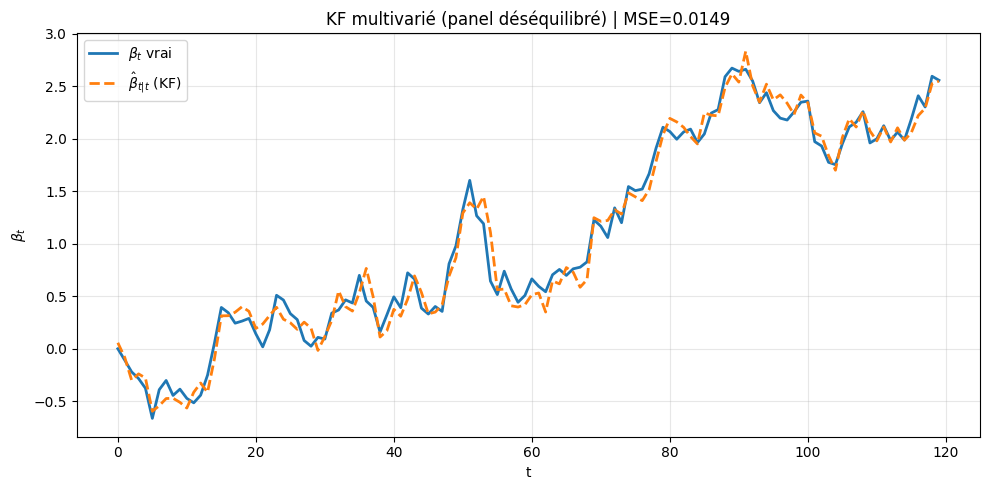

[MC beta] success: 296/300


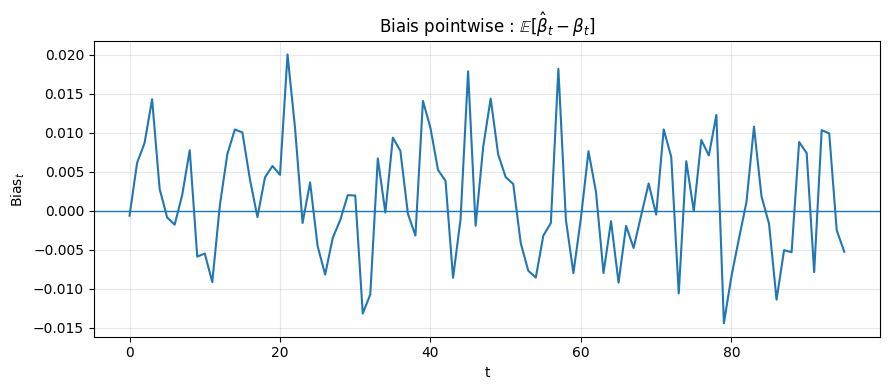

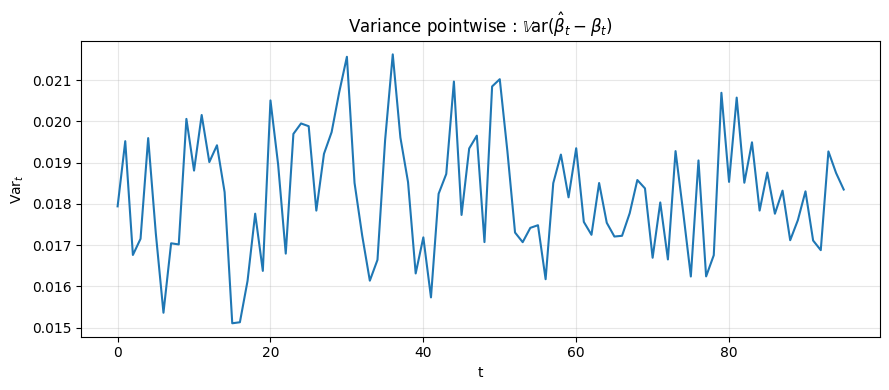

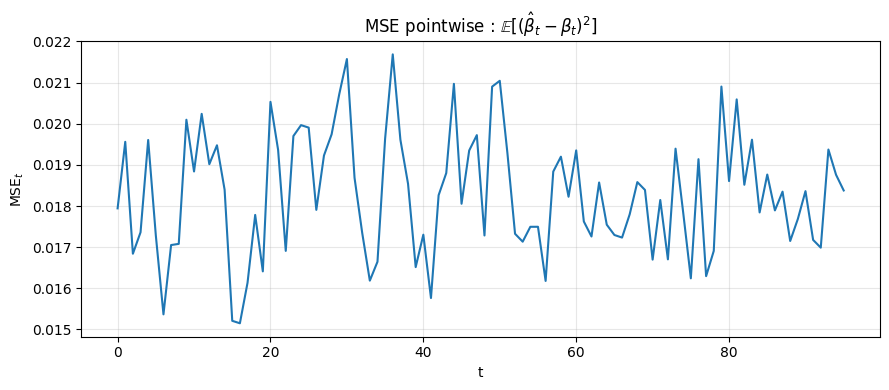

[MC params] success: 296/300

MC parameter stats:
MC_total: 300
MC_success: 296
sigma_xi2_mean: 0.03977286627682005
sigma_xi2_bias: -0.00022713372317995084
sigma_xi2_var: 7.551854971483132e-05
sigma_xi2_mse: 7.531500920751381e-05
sigma_v2_mean: 0.9998068619224346
sigma_v2_bias: -0.00019313807756538015
sigma_v2_var: 0.0004361489939281465
sigma_v2_mse: 0.0004347128199143138


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================================
# 1) KF multivarié (obs vector y_t, état scalaire beta_t)
#    Modèle:
#      beta_t = beta_{t-1} + xi_t,  xi_t ~ N(0, sigma_xi2)
#      y_t    = 1_{N_t} * beta_t + v_t, v_t ~ N(0, sigma_v2 I_{N_t})
# ==========================================================

def kf_loglike_multivariate(Y_list, sigma_xi2, sigma_v2, beta0=0.0, P0=1e6):
    """
    Log-vraisemblance KF (innovations), avec dimension N_t variable.
    sigma_xi2 = Var(xi_t)
    sigma_v2  = Var(v_it)
    """
    beta_pred = beta0
    P_pred = P0
    loglik = 0.0

    for y_t in Y_list:
        y_t = np.asarray(y_t)
        n = y_t.size

        H = np.ones((n, 1))                 # (n x 1)
        R = sigma_v2 * np.eye(n)            # (n x n)

        e = y_t.reshape(-1, 1) - H * beta_pred           # (n x 1)
        S = P_pred * (H @ H.T) + R                       # (n x n)

        sign, logdetS = np.linalg.slogdet(S)
        if sign <= 0:
            return -np.inf

        Sinv_e = np.linalg.solve(S, e)
        quad = float(e.T @ Sinv_e)

        loglik += -0.5 * (n * np.log(2*np.pi) + logdetS + quad)

        # update
        He = float(H.T @ Sinv_e)            # scalaire
        beta_upd = beta_pred + P_pred * He

        Sinv_H = np.linalg.solve(S, H)      # (n x 1)
        HSH = float(H.T @ Sinv_H)           # scalaire
        P_upd = P_pred - (P_pred**2) * HSH

        # predict next
        beta_pred = beta_upd
        P_pred = P_upd + sigma_xi2

    return loglik


def kf_filter_multivariate(Y_list, sigma_xi2, sigma_v2, beta0=0.0, P0=1e6):
    """
    Filtre KF multivarié -> renvoie beta_{t|t}, P_{t|t}.
    """
    T = len(Y_list)
    beta_filt = np.zeros(T)
    P_filt = np.zeros(T)

    beta_pred = beta0
    P_pred = P0

    for t, y_t in enumerate(Y_list):
        y_t = np.asarray(y_t)
        n = y_t.size

        H = np.ones((n, 1))
        R = sigma_v2 * np.eye(n)

        e = y_t.reshape(-1, 1) - H * beta_pred
        S = P_pred * (H @ H.T) + R

        Sinv_e = np.linalg.solve(S, e)
        He = float(H.T @ Sinv_e)
        beta_upd = beta_pred + P_pred * He

        Sinv_H = np.linalg.solve(S, H)
        HSH = float(H.T @ Sinv_H)
        P_upd = P_pred - (P_pred**2) * HSH

        beta_filt[t] = beta_upd
        P_filt[t] = P_upd

        beta_pred = beta_upd
        P_pred = P_upd + sigma_xi2

    return beta_filt, P_filt


# ==========================================================
# 2) MLE : estimer sigma_xi2 et sigma_v2
# ==========================================================

def mle_multivariate_kf(Y_list, beta0=0.0, P0=1e6, x0=(np.log(0.04), np.log(1.0))):
    """
    MLE sur (log sigma_xi2, log sigma_v2) pour garantir positivité.
    """
    def objective(params):
        log_sigma_xi2, log_sigma_v2 = params
        sigma_xi2 = np.exp(log_sigma_xi2)
        sigma_v2  = np.exp(log_sigma_v2)
        ll = kf_loglike_multivariate(Y_list, sigma_xi2, sigma_v2, beta0=beta0, P0=P0)
        return -ll

    res = minimize(objective, np.array(x0), method="L-BFGS-B")
    log_sigma_xi2_hat, log_sigma_v2_hat = res.x

    return {
        "sigma_xi2_hat": float(np.exp(log_sigma_xi2_hat)),
        "sigma_v2_hat":  float(np.exp(log_sigma_v2_hat)),
        "success": bool(res.success),
        "message": res.message
    }


# ==========================================================
# 3) Simulation utilitaire : panel déséquilibré
# ==========================================================

def simulate_panel_list(T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng):
    """
    Simule beta_true (RW) + Y_list (liste de vecteurs y_t de taille N_t variable).
    """
    N_t = rng.integers(Nmin, Nmax + 1, size=T)

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(sigma_xi2_true))

    Y_list = []
    for t in range(T):
        n = int(N_t[t])
        v = rng.normal(0.0, np.sqrt(sigma_v2_true), size=n)
        Y_list.append(beta_true[t] + v)

    return beta_true, Y_list, N_t


# ==========================================================
# 4) MC: biais(t), variance(t), MSE(t) de (beta_hat - beta_true)
# ==========================================================

def mc_bias_var_mse_beta(T=120, MC=300, Nmin=20, Nmax=60,
                         sigma_xi2_true=0.04, sigma_v2_true=1.0,
                         seed=123, burn_frac=0.0):
    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    errors = np.full((MC, T), np.nan)
    ok = 0

    for m in range(MC):
        beta_true, Y_list, _ = simulate_panel_list(T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng)

        fit = mle_multivariate_kf(Y_list)
        if not fit["success"]:
            continue

        ok += 1
        beta_hat, _ = kf_filter_multivariate(Y_list, fit["sigma_xi2_hat"], fit["sigma_v2_hat"])
        errors[m, :] = beta_hat - beta_true

    errors_ok = errors[~np.isnan(errors).any(axis=1)]
    print(f"[MC beta] success: {errors_ok.shape[0]}/{MC}")

    bias_t = errors_ok.mean(axis=0)
    var_t  = errors_ok.var(axis=0, ddof=1)
    mse_t  = bias_t**2 + var_t

    return bias_t[burn:], var_t[burn:], mse_t[burn:]


def plot_bias_var_mse(bias_t, var_t, mse_t):
    t = np.arange(len(bias_t))

    plt.figure(figsize=(9, 4))
    plt.plot(t, bias_t)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{Bias}_t$")
    plt.title(r"Biais pointwise : $\mathbb{E}[\hat\beta_t-\beta_t]$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(t, var_t)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{Var}_t$")
    plt.title(r"Variance pointwise : $\mathbb{V}\mathrm{ar}(\hat\beta_t-\beta_t)$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(t, mse_t)
    plt.xlabel("t")
    plt.ylabel(r"$\mathrm{MSE}_t$")
    plt.title(r"MSE pointwise : $\mathbb{E}[(\hat\beta_t-\beta_t)^2]$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==========================================================
# 5) MC: biais/variance/MSE des paramètres estimés (sigma_xi2_hat, sigma_v2_hat)
# ==========================================================

def mc_bias_var_params(MC=300, T=120, Nmin=20, Nmax=60,
                       sigma_xi2_true=0.04, sigma_v2_true=1.0, seed=123):
    rng = np.random.default_rng(seed)

    xi2_hats = []
    v2_hats = []
    ok = 0

    for _ in range(MC):
        _, Y_list, _ = simulate_panel_list(T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng)

        fit = mle_multivariate_kf(Y_list)
        if not fit["success"]:
            continue

        ok += 1
        xi2_hats.append(fit["sigma_xi2_hat"])
        v2_hats.append(fit["sigma_v2_hat"])

    xi2_hats = np.array(xi2_hats)
    v2_hats  = np.array(v2_hats)

    print(f"[MC params] success: {ok}/{MC}")

    out = {
        "MC_total": MC,
        "MC_success": ok,

        "sigma_xi2_mean": float(xi2_hats.mean()),
        "sigma_xi2_bias": float(xi2_hats.mean() - sigma_xi2_true),
        "sigma_xi2_var":  float(xi2_hats.var(ddof=1)),
        "sigma_xi2_mse":  float(np.mean((xi2_hats - sigma_xi2_true)**2)),

        "sigma_v2_mean": float(v2_hats.mean()),
        "sigma_v2_bias": float(v2_hats.mean() - sigma_v2_true),
        "sigma_v2_var":  float(v2_hats.var(ddof=1)),
        "sigma_v2_mse":  float(np.mean((v2_hats - sigma_v2_true)**2)),
    }
    return out


# ==========================================================
# 6) Démo 1 simulation: beta vrai vs beta filtré + MSE
# ==========================================================

def demo_one_run(T=120, Nmin=20, Nmax=60, sigma_xi2_true=0.04, sigma_v2_true=1.0, seed=123):
    rng = np.random.default_rng(seed)
    beta_true, Y_list, N_t = simulate_panel_list(T, Nmin, Nmax, sigma_xi2_true, sigma_v2_true, rng)

    fit = mle_multivariate_kf(Y_list)
    print("MLE success:", fit["success"], "|", fit["message"])
    print(f"sigma_xi2_hat={fit['sigma_xi2_hat']:.5f} (true {sigma_xi2_true})")
    print(f"sigma_v2_hat ={fit['sigma_v2_hat']:.5f} (true {sigma_v2_true})")

    beta_hat, _ = kf_filter_multivariate(Y_list, fit["sigma_xi2_hat"], fit["sigma_v2_hat"])
    mse = float(np.mean((beta_hat - beta_true)**2))
    print(f"MSE(beta_hat, beta_true) = {mse:.6f}")

    plt.figure(figsize=(10, 5))
    plt.plot(beta_true, label=r"$\beta_t$ vrai", linewidth=2)
    plt.plot(beta_hat, "--", label=r"$\hat\beta_{t|t}$ (KF)", linewidth=2)
    plt.xlabel("t")
    plt.ylabel(r"$\beta_t$")
    plt.title(f"KF multivarié (panel déséquilibré) | MSE={mse:.4f}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================================
# RUN (un seul script propre)
# ==========================================================

if __name__ == "__main__":
    # Paramètres "vrais"
    sigma_xi2_true = 0.04
    sigma_v2_true  = 1.0

    # (A) Une simulation : tracer beta vrai vs beta filtré
    demo_one_run(
        T=120, Nmin=20, Nmax=60,
        sigma_xi2_true=sigma_xi2_true,
        sigma_v2_true=sigma_v2_true,
        seed=123
    )

    # (B) Monte Carlo : biais(t), var(t), MSE(t) de (beta_hat - beta_true)
    bias_t, var_t, mse_t = mc_bias_var_mse_beta(
        T=120, MC=300, Nmin=20, Nmax=60,
        sigma_xi2_true=sigma_xi2_true,
        sigma_v2_true=sigma_v2_true,
        seed=123,
        burn_frac=0.2
    )
    plot_bias_var_mse(bias_t, var_t, mse_t)

    # (C) Monte Carlo : biais/variance/MSE des paramètres estimés
    stats = mc_bias_var_params(
        MC=300, T=120, Nmin=20, Nmax=60,
        sigma_xi2_true=sigma_xi2_true,
        sigma_v2_true=sigma_v2_true,
        seed=123
    )
    print("\nMC parameter stats:")
    for k, v in stats.items():
        print(f"{k}: {v}")


N: [5, 10, 20, 40, 60, 100, 120, 150, 200]
Bias: [-2.65576707e-04  4.22709534e-04  3.10800475e-05 -1.75743910e-04
  5.90875330e-04  3.33783454e-04  1.04593274e-04  2.61802090e-04
 -1.30839596e-04]
Var: [0.07184413 0.04620664 0.02917505 0.01739691 0.01264508 0.0083939
 0.00709067 0.00586757 0.00449847]
MSE: [0.07184375 0.04620653 0.02917487 0.01739684 0.01264535 0.00839396
 0.00709063 0.0058676  0.00449846]
sigma_xi2_hat: [0.03992284 0.0395579  0.03999686 0.04029373 0.04021967 0.040165
 0.03984629 0.03960191 0.03985836]
sigma_u2_hat: [1.00009191 0.99918299 0.99878946 0.9999754  0.99916755 0.99959979
 1.00024652 0.99967845 1.00022121]


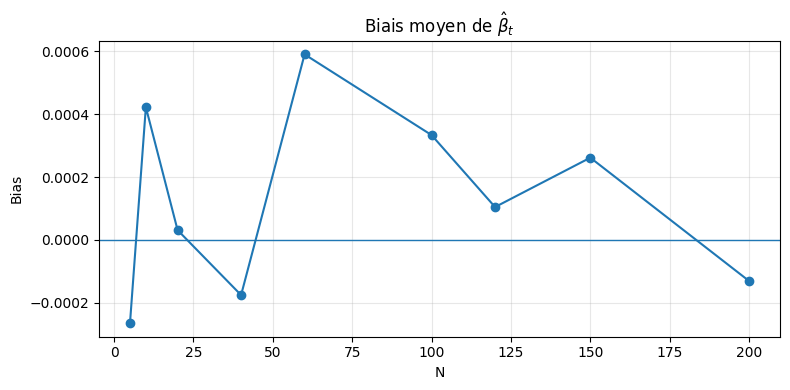

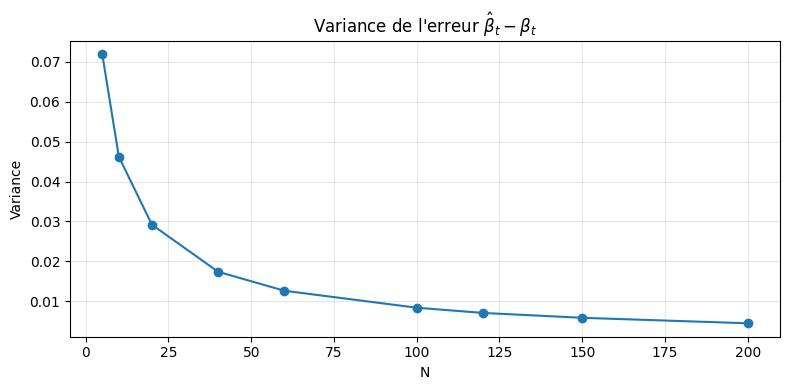

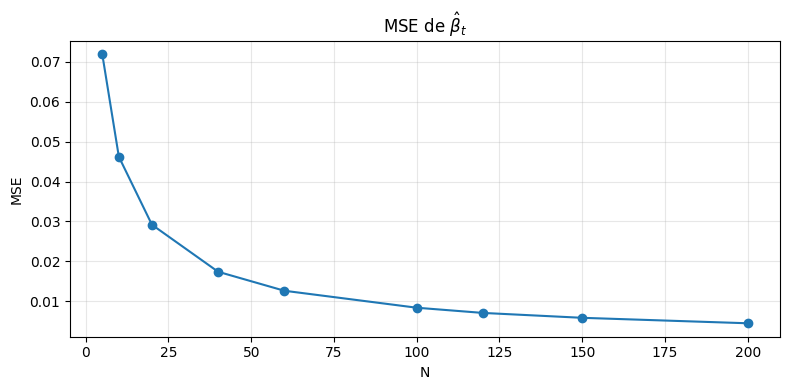

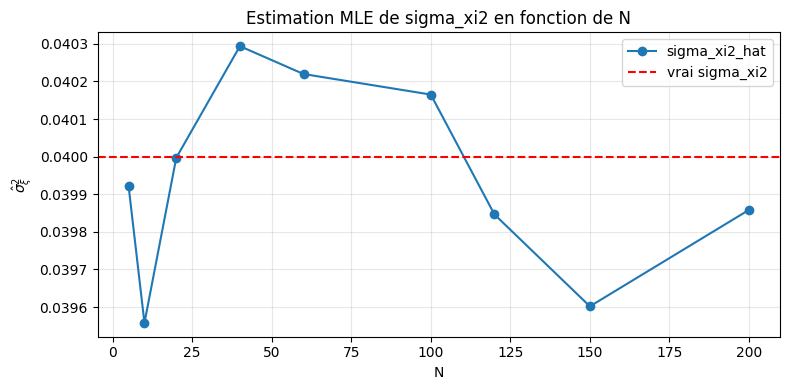

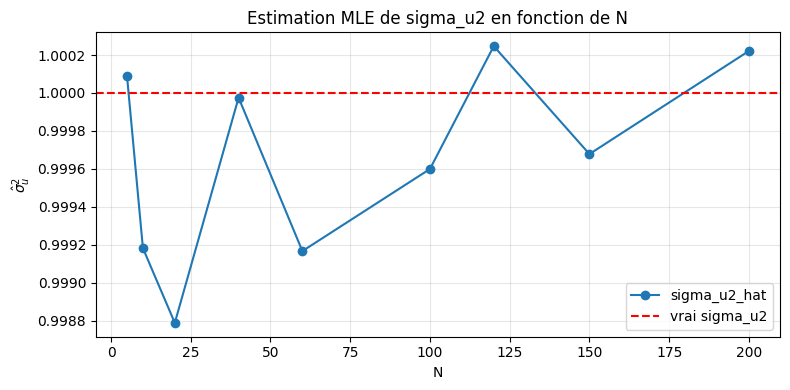

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================================================
# KF multivarié (état scalaire)
# =========================================================
def kf_filter_multivariate(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    """
    Filtre de Kalman multivarié pour :
      y_it = beta_t + u_it,   u_it ~ N(0, sigma_u2)
      beta_t = beta_{t-1} + xi_t,  xi_t ~ N(0, sigma_xi2)

    Y : array (T, N)
    """
    T, N = Y.shape
    beta_filt = np.zeros(T)
    P_filt = np.zeros(T)

    beta_pred = beta0
    P_pred = P0

    H = np.ones((N, 1))         # matrice de mesure
    R = sigma_u2 * np.eye(N)    # covariance observation

    for t in range(T):
        y_t = Y[t].reshape(-1, 1)

        # Innovation
        e_t = y_t - H * beta_pred
        S_t = (H @ H.T) * P_pred + R
        K_t = (P_pred * H.T) @ np.linalg.inv(S_t)  # (1xN)

        # Update
        beta_pred = beta_pred + (K_t @ e_t).item()
        P_pred = (1 - (K_t @ H).item()) * P_pred

        beta_filt[t] = beta_pred
        P_filt[t] = P_pred

        # Prediction
        P_pred = P_pred + sigma_xi2

    return beta_filt, P_filt


# =========================================================
# Log-vraisemblance (innovations) - formule fermée panel
# (équivalente au KF multivarié, mais plus stable pour MLE)
# =========================================================
def kf_loglike_panel(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    """
    Log-vraisemblance via innovations pour le modèle :
      y_t = 1_N * beta_t + u_t,  u_t ~ N(0, sigma_u2 I_N)
      beta_t = beta_{t-1} + xi_t, xi_t ~ N(0, sigma_xi2)

    Fermé car S_t = sigma_u2 I + P 11'
    """
    T, N = Y.shape
    b = beta0
    P = P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        y = Y[t]
        e = y - b
        one_e = e.sum()
        ee = float(e @ e)

        # log det(S_t)
        logdetS = (N - 1) * np.log(sigma_u2) + np.log(sigma_u2 + N * P)

        # e' S^{-1} e  (Woodbury)
        quad = (ee / sigma_u2) - (P / (sigma_u2 * (sigma_u2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        # update
        b = b + P * one_e / (sigma_u2 + N * P)
        P = P * sigma_u2 / (sigma_u2 + N * P)

        # predict
        P = P + sigma_xi2

    return ll


def mle_params_panel(Y, beta0=0.0, P0=1e6):
    """
    MLE de (sigma_xi2, sigma_u2) en optimisant sur log-variances.
    """
    def objective(theta):
        sx2 = np.exp(theta[0])
        su2 = np.exp(theta[1])
        return -kf_loglike_panel(Y, sx2, su2, beta0=beta0, P0=P0)

    x0 = np.log([0.04, 1.0])
    res = minimize(objective, x0, method="L-BFGS-B")
    sx2_hat = float(np.exp(res.x[0]))
    su2_hat = float(np.exp(res.x[1]))
    return sx2_hat, su2_hat, res.success


# =========================================================
# Simulation + MC
# =========================================================
def simulate_panel(T, N, sigma_xi2, sigma_u2, rng):
    beta = np.zeros(T)
    for t in range(1, T):
        beta[t] = beta[t-1] + rng.normal(0, np.sqrt(sigma_xi2))

    U = rng.normal(0, np.sqrt(sigma_u2), size=(T, N))
    Y = beta[:, None] + U
    return beta, Y


def mc_full_results_multivariate_with_mle(list_N, T, MC,
                                          sigma_xi2_true, sigma_u2_true,
                                          seed=123, beta0=0.0, P0=1e6,
                                          burn_frac=0.2):

    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    bias_list = []
    var_list = []
    mse_list = []

    sigma_xi2_mean_list = []
    sigma_u2_mean_list = []

    for N in list_N:

        all_errors = []
        xi2_hats = []
        u2_hats = []

        for _ in range(MC):
            beta_true, Y = simulate_panel(T, N, sigma_xi2_true, sigma_u2_true, rng)

            sx2_hat, su2_hat, ok = mle_params_panel(Y, beta0=beta0, P0=P0)
            if not ok:
                continue

            xi2_hats.append(sx2_hat)
            u2_hats.append(su2_hat)

            beta_hat, _ = kf_filter_multivariate(
                Y, sx2_hat, su2_hat, beta0=beta0, P0=P0
            )

            errors = beta_hat[burn:] - beta_true[burn:]
            all_errors.extend(errors)

        all_errors = np.array(all_errors)

        bias_list.append(np.mean(all_errors))
        var_list.append(np.var(all_errors, ddof=1))
        mse_list.append(np.mean(all_errors**2))

        sigma_xi2_mean_list.append(np.mean(xi2_hats))
        sigma_u2_mean_list.append(np.mean(u2_hats))

    return (np.array(bias_list),
            np.array(var_list),
            np.array(mse_list),
            np.array(sigma_xi2_mean_list),
            np.array(sigma_u2_mean_list))

# =========================================================
# RUN
# =========================================================
if __name__ == "__main__":

    list_N = [5, 10, 20, 40, 60, 100, 120, 150, 200]
    T = 100
    MC = 2000

    (bias_N, var_N, mse_N,
     sigma_xi2_hat_N,
     sigma_u2_hat_N) = mc_full_results_multivariate_with_mle(
        list_N=list_N,
        T=T,
        MC=MC,
        sigma_xi2_true=0.04,
        sigma_u2_true=1.0
    )

    print("N:", list_N)
    print("Bias:", bias_N)
    print("Var:", var_N)
    print("MSE:", mse_N)
    print("sigma_xi2_hat:", sigma_xi2_hat_N)
    print("sigma_u2_hat:", sigma_u2_hat_N)
    # --------- Graphes ---------

    plt.figure(figsize=(8,4))
    plt.plot(list_N, bias_N, marker="o")
    plt.axhline(0, linewidth=1)
    plt.xlabel("N")
    plt.ylabel("Bias")
    plt.title("Biais moyen de $\hat{\\beta}_t$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_N, var_N, marker="o")
    plt.xlabel("N")
    plt.ylabel("Variance")
    plt.title("Variance de l'erreur $\hat{\\beta}_t - \\beta_t$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_N, mse_N, marker="o")
    plt.xlabel("N")
    plt.ylabel("MSE")
    plt.title("MSE de $\hat{\\beta}_t$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

        # --------- Paramètres estimés ---------

    plt.figure(figsize=(8,4))
    plt.plot(list_N, sigma_xi2_hat_N, marker="o", label="sigma_xi2_hat")
    plt.axhline(0.04, color="r", linestyle="--", label="vrai sigma_xi2")
    plt.xlabel("N")
    plt.ylabel(r"$\hat{\sigma}_\xi^2$")
    plt.title("Estimation MLE de sigma_xi2 en fonction de N")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_N, sigma_u2_hat_N, marker="o", label="sigma_u2_hat")
    plt.axhline(1.0, color="r", linestyle="--", label="vrai sigma_u2")
    plt.xlabel("N")
    plt.ylabel(r"$\hat{\sigma}_u^2$")
    plt.title("Estimation MLE de sigma_u2 en fonction de N")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

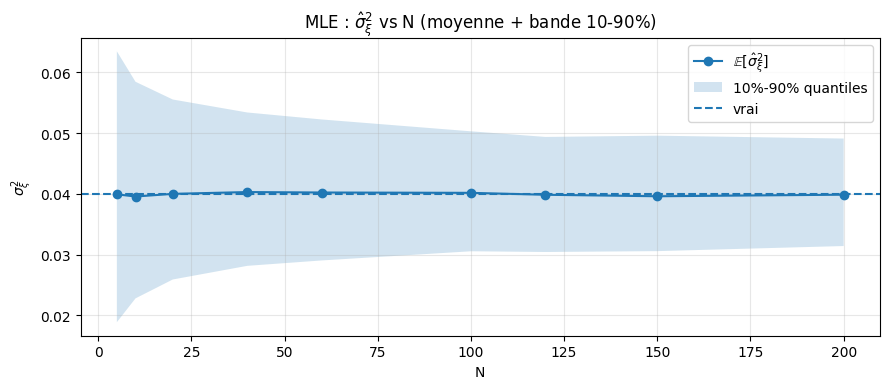

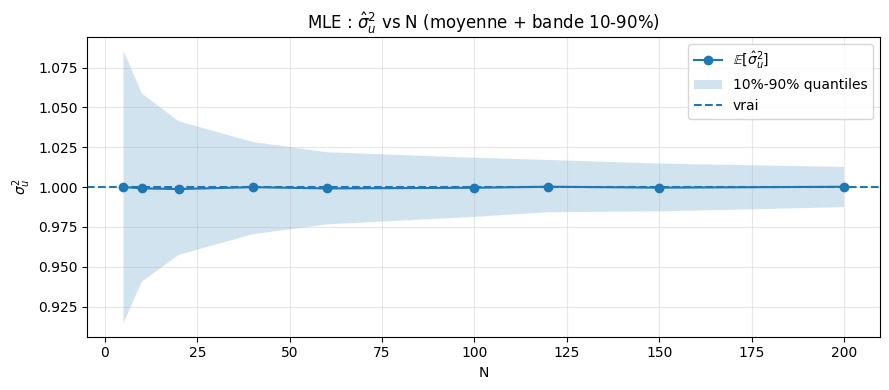

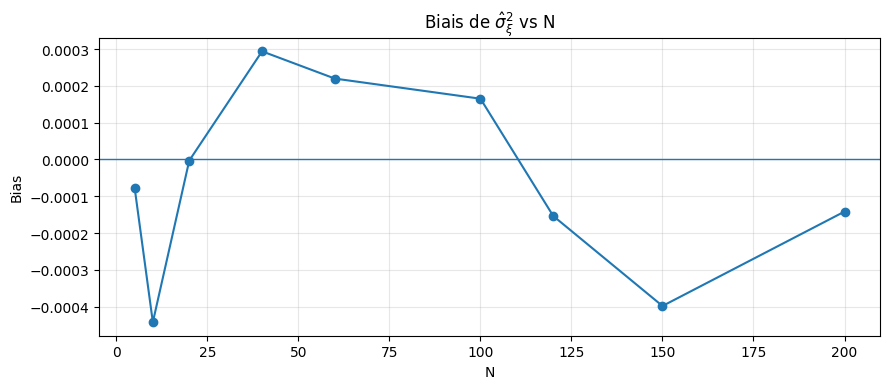

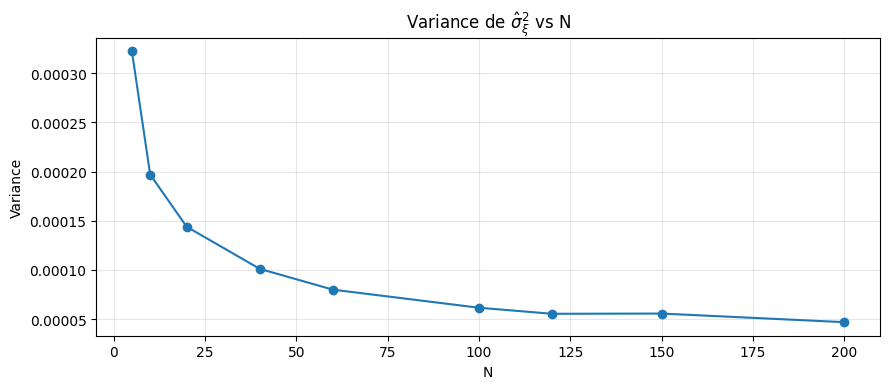

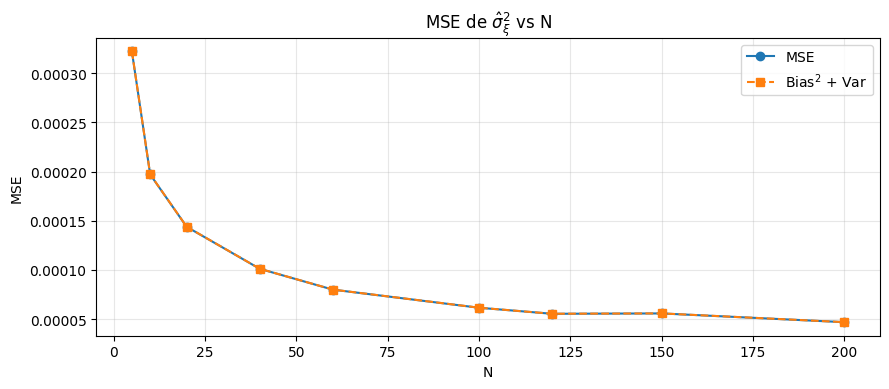

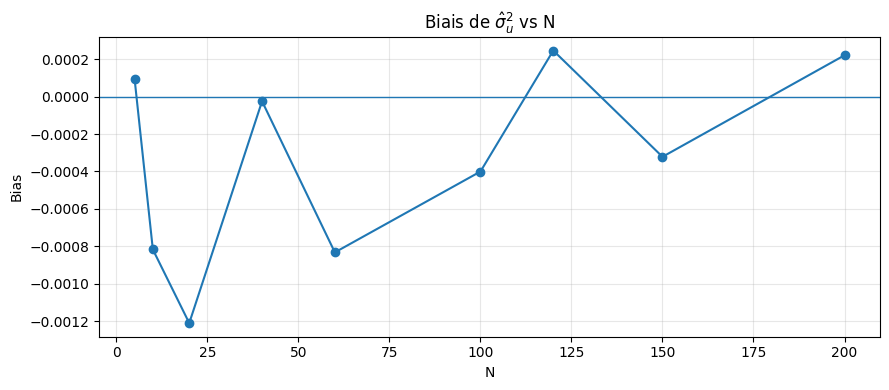

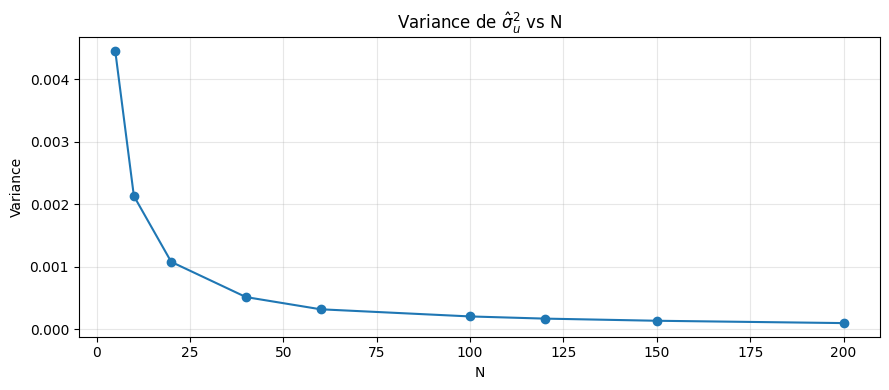

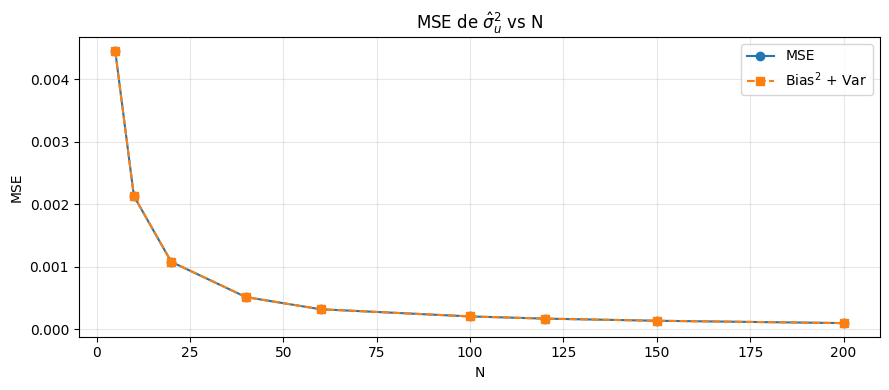

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def mc_params_stats_vs_N(list_N, T, MC,
                         sigma_xi2_true, sigma_u2_true,
                         seed=123, beta0=0.0, P0=1e6):

    rng = np.random.default_rng(seed)

    # sorties par N
    xi2_mean = []
    xi2_bias = []
    xi2_var  = []
    xi2_mse  = []
    xi2_q10  = []
    xi2_q90  = []

    u2_mean = []
    u2_bias = []
    u2_var  = []
    u2_mse  = []
    u2_q10  = []
    u2_q90  = []

    success_rate = []

    for N in list_N:
        xi2_hats = []
        u2_hats  = []
        ok = 0

        for _ in range(MC):
            _, Y = simulate_panel(T, N, sigma_xi2_true, sigma_u2_true, rng)
            sx2_hat, su2_hat, success = mle_params_panel(Y, beta0=beta0, P0=P0)
            if not success:
                continue
            ok += 1
            xi2_hats.append(sx2_hat)
            u2_hats.append(su2_hat)

        xi2_hats = np.array(xi2_hats)
        u2_hats  = np.array(u2_hats)

        success_rate.append(ok / MC)

        # --- sigma_xi^2 stats ---
        m_xi2 = xi2_hats.mean()
        b_xi2 = m_xi2 - sigma_xi2_true
        v_xi2 = xi2_hats.var(ddof=1)
        mse_xi2 = np.mean((xi2_hats - sigma_xi2_true)**2)

        xi2_mean.append(m_xi2)
        xi2_bias.append(b_xi2)
        xi2_var.append(v_xi2)
        xi2_mse.append(mse_xi2)
        xi2_q10.append(np.quantile(xi2_hats, 0.10))
        xi2_q90.append(np.quantile(xi2_hats, 0.90))

        # --- sigma_u^2 stats ---
        m_u2 = u2_hats.mean()
        b_u2 = m_u2 - sigma_u2_true
        v_u2 = u2_hats.var(ddof=1)
        mse_u2 = np.mean((u2_hats - sigma_u2_true)**2)

        u2_mean.append(m_u2)
        u2_bias.append(b_u2)
        u2_var.append(v_u2)
        u2_mse.append(mse_u2)
        u2_q10.append(np.quantile(u2_hats, 0.10))
        u2_q90.append(np.quantile(u2_hats, 0.90))

    return {
        "N": np.array(list_N),
        "xi2_mean": np.array(xi2_mean),
        "xi2_bias": np.array(xi2_bias),
        "xi2_var":  np.array(xi2_var),
        "xi2_mse":  np.array(xi2_mse),
        "xi2_q10":  np.array(xi2_q10),
        "xi2_q90":  np.array(xi2_q90),

        "u2_mean": np.array(u2_mean),
        "u2_bias": np.array(u2_bias),
        "u2_var":  np.array(u2_var),
        "u2_mse":  np.array(u2_mse),
        "u2_q10":  np.array(u2_q10),
        "u2_q90":  np.array(u2_q90),

        "success_rate": np.array(success_rate)
    }


def plot_param_stats_vs_N(stats, sigma_xi2_true, sigma_u2_true):
    N = stats["N"]

    # --- Means with quantile bands ---
    plt.figure(figsize=(9,4))
    plt.plot(N, stats["xi2_mean"], marker="o", label=r"$\mathbb{E}[\hat\sigma_\xi^2]$")
    plt.fill_between(N, stats["xi2_q10"], stats["xi2_q90"], alpha=0.2, label="10%-90% quantiles")
    plt.axhline(sigma_xi2_true, linestyle="--", label="vrai")
    plt.xlabel("N")
    plt.ylabel(r"$\sigma_\xi^2$")
    plt.title(r"MLE : $\hat\sigma_\xi^2$ vs N (moyenne + bande 10-90%)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["u2_mean"], marker="o", label=r"$\mathbb{E}[\hat\sigma_u^2]$")
    plt.fill_between(N, stats["u2_q10"], stats["u2_q90"], alpha=0.2, label="10%-90% quantiles")
    plt.axhline(sigma_u2_true, linestyle="--", label="vrai")
    plt.xlabel("N")
    plt.ylabel(r"$\sigma_u^2$")
    plt.title(r"MLE : $\hat\sigma_u^2$ vs N (moyenne + bande 10-90%)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Bias / Var / MSE ---
    plt.figure(figsize=(9,4))
    plt.plot(N, stats["xi2_bias"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.xlabel("N")
    plt.ylabel("Bias")
    plt.title(r"Biais de $\hat\sigma_\xi^2$ vs N")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["xi2_var"], marker="o")
    plt.xlabel("N")
    plt.ylabel("Variance")
    plt.title(r"Variance de $\hat\sigma_\xi^2$ vs N")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["xi2_mse"], marker="o", label="MSE")
    plt.plot(N, stats["xi2_bias"]**2 + stats["xi2_var"], marker="s", linestyle="--",
             label=r"Bias$^2$ + Var")
    plt.xlabel("N")
    plt.ylabel("MSE")
    plt.title(r"MSE de $\hat\sigma_\xi^2$ vs N")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["u2_bias"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.xlabel("N")
    plt.ylabel("Bias")
    plt.title(r"Biais de $\hat\sigma_u^2$ vs N")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["u2_var"], marker="o")
    plt.xlabel("N")
    plt.ylabel("Variance")
    plt.title(r"Variance de $\hat\sigma_u^2$ vs N")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(N, stats["u2_mse"], marker="o", label="MSE")
    plt.plot(N, stats["u2_bias"]**2 + stats["u2_var"], marker="s", linestyle="--",
             label=r"Bias$^2$ + Var")
    plt.xlabel("N")
    plt.ylabel("MSE")
    plt.title(r"MSE de $\hat\sigma_u^2$ vs N")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    list_N = [5, 10, 20, 40, 60, 100, 120, 150, 200]
    T = 100
    MC = 2000  # <- ici

    sigma_xi2_true = 0.04
    sigma_u2_true  = 1.0

    stats = mc_params_stats_vs_N(
        list_N=list_N, T=T, MC=MC,
        sigma_xi2_true=sigma_xi2_true,
        sigma_u2_true=sigma_u2_true,
        seed=123
    )

    plot_param_stats_vs_N(stats, sigma_xi2_true, sigma_u2_true)


In [20]:
print(stats["xi2_mean"])

[0.03992284 0.0395579  0.03999686 0.04029373 0.04021967 0.040165
 0.03984629 0.03960191 0.03985836]


T: [20]
Bias: [-0.00059609]
Var : [0.01309043]
MSE : [0.0130867]
sigma_xi2_hat mean: [0.0386842]
sigma_u2_hat  mean: [0.99990953]
success rate: [1.]


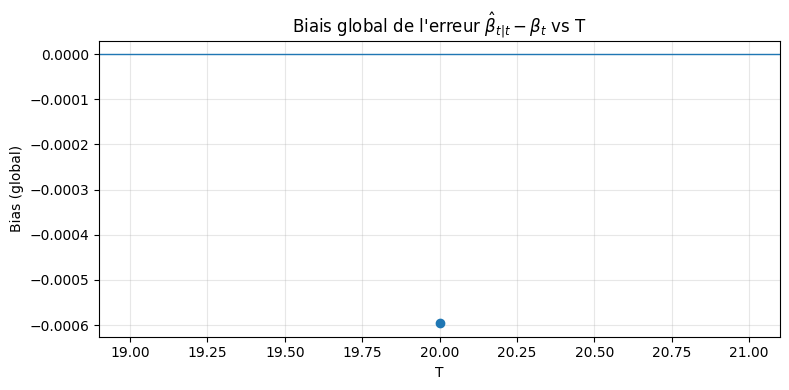

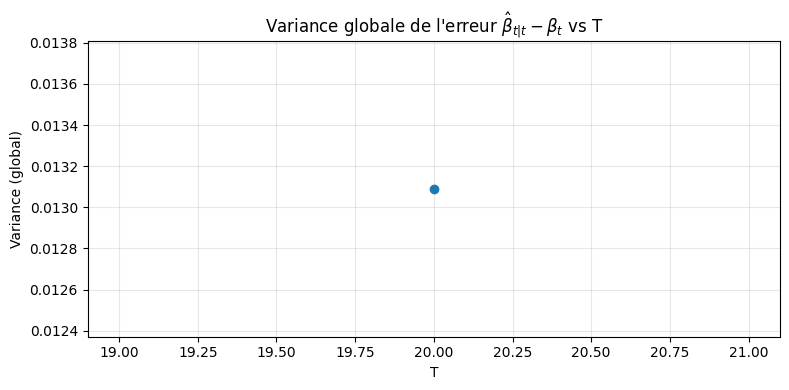

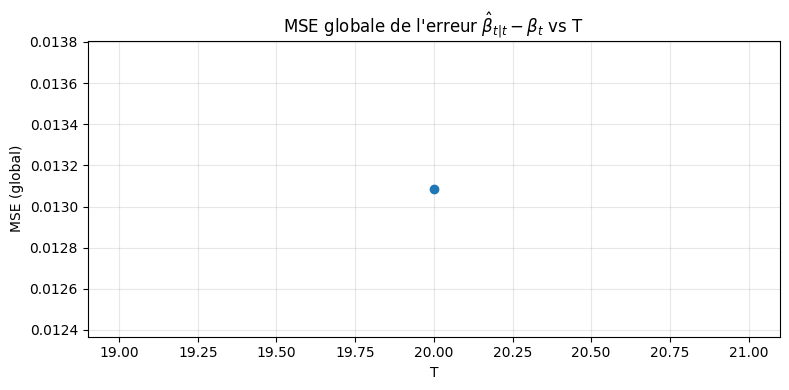

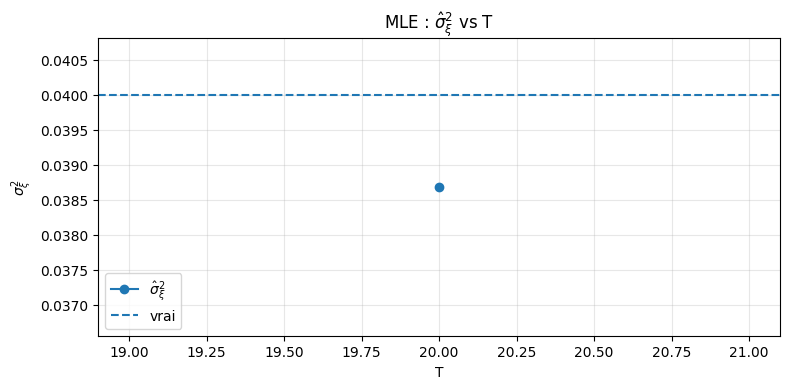

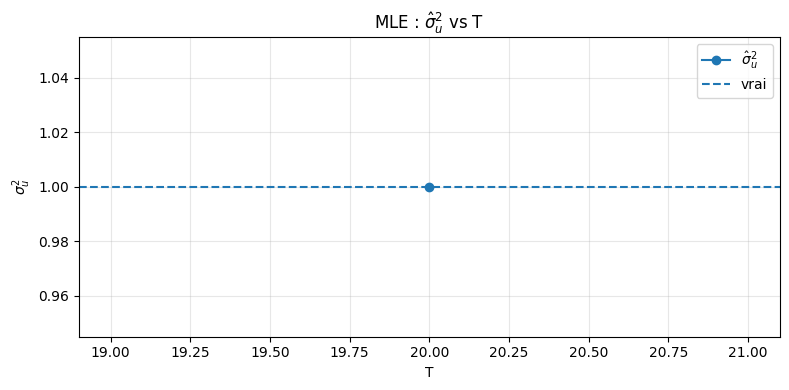

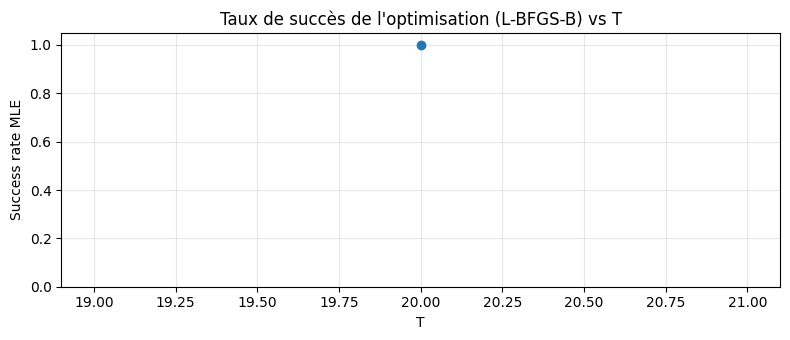

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# =========================================================
# Log-vraisemblance (innovations) - formule fermée panel
# =========================================================
def kf_loglike_panel(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    T, N = Y.shape
    b = beta0
    P = P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        y = Y[t]
        e = y - b
        one_e = e.sum()
        ee = float(e @ e)

        logdetS = (N - 1) * np.log(sigma_u2) + np.log(sigma_u2 + N * P)
        quad = (ee / sigma_u2) - (P / (sigma_u2 * (sigma_u2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        # update
        b = b + P * one_e / (sigma_u2 + N * P)
        P = P * sigma_u2 / (sigma_u2 + N * P)

        # predict
        P = P + sigma_xi2

    return ll


def mle_params_panel(Y, beta0=0.0, P0=1e6):
    """MLE de (sigma_xi2, sigma_u2) en optimisant sur log-variances."""
    def objective(theta):
        sx2 = np.exp(theta[0])
        su2 = np.exp(theta[1])
        return -kf_loglike_panel(Y, sx2, su2, beta0=beta0, P0=P0)

    res = minimize(objective, np.log([0.04, 1.0]), method="L-BFGS-B")
    return float(np.exp(res.x[0])), float(np.exp(res.x[1])), bool(res.success)


# =========================================================
# Filtre KF panel (état scalaire) : retourne beta_{t|t}
# =========================================================
def kf_filter_panel(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    T, N = Y.shape
    b = beta0
    P = P0

    beta_filt = np.zeros(T)
    P_filt = np.zeros(T)

    for t in range(T):
        e = Y[t] - b
        one_e = e.sum()

        # update
        b = b + P * one_e / (sigma_u2 + N * P)
        P = P * sigma_u2 / (sigma_u2 + N * P)

        beta_filt[t] = b
        P_filt[t] = P

        # predict
        P = P + sigma_xi2

    return beta_filt, P_filt


# =========================================================
# Simulation
# =========================================================
def simulate_panel(T, N, sigma_xi2, sigma_u2, rng):
    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t - 1] + rng.normal(0, np.sqrt(sigma_xi2))

    Y = beta_true[:, None] + rng.normal(0, np.sqrt(sigma_u2), size=(T, N))
    return beta_true, Y


# =========================================================
# MC : Bias/Var/MSE de l'erreur + paramètres estimés, vs T
# =========================================================
def mc_results_vs_T_indep_seeds(list_T, N, MC,
                               sigma_xi2_true, sigma_u2_true,
                               seed=123, beta0=0.0, P0=1e6, burn_frac=0.2):

    bias_list, var_list, mse_list = [], [], []
    xi2_mean_list, u2_mean_list, succ_list = [], [], []

    for j, T in enumerate(list_T):
        rng = np.random.default_rng(seed + 1000*j)  # <- seed différent par T
        burn = int(burn_frac * T)

        all_errors = []
        xi2_hats, u2_hats = [], []
        ok = 0

        for _ in range(MC):
            beta_true, Y = simulate_panel(T, N, sigma_xi2_true, sigma_u2_true, rng)

            sx2_hat, su2_hat, success = mle_params_panel(Y, beta0=beta0, P0=P0)
            if not success:
                continue

            ok += 1
            xi2_hats.append(sx2_hat)
            u2_hats.append(su2_hat)

            beta_hat, _ = kf_filter_panel(Y, sx2_hat, su2_hat, beta0=beta0, P0=P0)
            all_errors.extend(beta_hat[burn:] - beta_true[burn:])

        all_errors = np.array(all_errors)

        bias_list.append(all_errors.mean())
        var_list.append(all_errors.var(ddof=1))
        mse_list.append((all_errors**2).mean())

        xi2_mean_list.append(np.mean(xi2_hats))
        u2_mean_list.append(np.mean(u2_hats))
        succ_list.append(ok/MC)

    return (np.array(bias_list), np.array(var_list), np.array(mse_list),
            np.array(xi2_mean_list), np.array(u2_mean_list), np.array(succ_list))

# =========================================================
# RUN
# =========================================================
if __name__ == "__main__":

    sigma_xi2_true = 0.04
    sigma_u2_true  = 1.0

    N  = 60
    MC = 2000
    list_T = [20, 50, 100, 150, 200, 300, 400, 600, 800, 1000]

    bias_T, var_T, mse_T, xi2_hat_T, u2_hat_T, succ_T = mc_results_vs_T_indep_seeds(
        list_T=list_T,
        N=N,
        MC=MC,
        sigma_xi2_true=sigma_xi2_true,
        sigma_u2_true=sigma_u2_true,
        burn_frac=0.2
    )

    print("T:", list_T)
    print("Bias:", bias_T)
    print("Var :", var_T)
    print("MSE :", mse_T)
    print("sigma_xi2_hat mean:", xi2_hat_T)
    print("sigma_u2_hat  mean:", u2_hat_T)
    print("success rate:", succ_T)

    # --- Graphes : erreurs beta ---
    plt.figure(figsize=(8,4))
    plt.plot(list_T, bias_T, marker="o")
    plt.axhline(0, linewidth=1)
    plt.xlabel("T")
    plt.ylabel("Bias (global)")
    plt.title(r"Biais global de l'erreur $\hat\beta_{t|t}-\beta_t$ vs T")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_T, var_T, marker="o")
    plt.xlabel("T")
    plt.ylabel("Variance (global)")
    plt.title(r"Variance globale de l'erreur $\hat\beta_{t|t}-\beta_t$ vs T")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_T, mse_T, marker="o")
    plt.xlabel("T")
    plt.ylabel("MSE (global)")
    plt.title(r"MSE globale de l'erreur $\hat\beta_{t|t}-\beta_t$ vs T")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Graphes : paramètres MLE ---
    plt.figure(figsize=(8,4))
    plt.plot(list_T, xi2_hat_T, marker="o", label=r"$\hat\sigma_\xi^2$")
    plt.axhline(sigma_xi2_true, linestyle="--", label="vrai")
    plt.xlabel("T")
    plt.ylabel(r"$\sigma_\xi^2$")
    plt.title(r"MLE : $\hat\sigma_\xi^2$ vs T")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(list_T, u2_hat_T, marker="o", label=r"$\hat\sigma_u^2$")
    plt.axhline(sigma_u2_true, linestyle="--", label="vrai")
    plt.xlabel("T")
    plt.ylabel(r"$\sigma_u^2$")
    plt.title(r"MLE : $\hat\sigma_u^2$ vs T")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- (optionnel) taux de succès de l'optimisation ---
    plt.figure(figsize=(8,3.5))
    plt.plot(list_T, succ_T, marker="o")
    plt.ylim(0, 1.05)
    plt.xlabel("T")
    plt.ylabel("Success rate MLE")
    plt.title("Taux de succès de l'optimisation (L-BFGS-B) vs T")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


T: [20, 50, 100, 150, 200, 300, 400, 600, 800, 1000]
Bias: [ 1.51946870e-03  5.43719388e-04 -1.27320757e-04 -1.82230311e-04
  1.89196651e-04  1.33908866e-04  9.63204038e-05  1.53355203e-04
  7.19027939e-05 -1.65034890e-04]
Var : [0.01282212 0.01274084 0.01265286 0.01269066 0.01260817 0.01267484
 0.01264456 0.01265004 0.01267341 0.01266981]
MSE : [0.01282402 0.01274098 0.0126528  0.01269064 0.01260817 0.01267483
 0.01264455 0.01265005 0.0126734  0.01266983]
sigma_xi2_hat mean: [0.03954894 0.04011653 0.04013269 0.03979872 0.0398367  0.03978074
 0.04007388 0.0401464  0.04005571 0.0400204 ]
sigma_u2_hat mean: [0.99920366 1.00063556 0.99979631 1.00034498 1.00033155 1.00028526
 0.99999929 1.00000064 0.99991858 1.00002211]
Var(sigma_xi2_hat): [4.22404384e-04 1.52579412e-04 7.98503879e-05 5.03052600e-05
 3.82391507e-05 2.46311637e-05 1.90794670e-05 1.27308963e-05
 9.10557572e-06 7.59243669e-06]
Var(sigma_u2_hat): [1.70026412e-03 6.65618410e-04 3.33292309e-04 2.21045852e-04
 1.64041469e-04 1.10

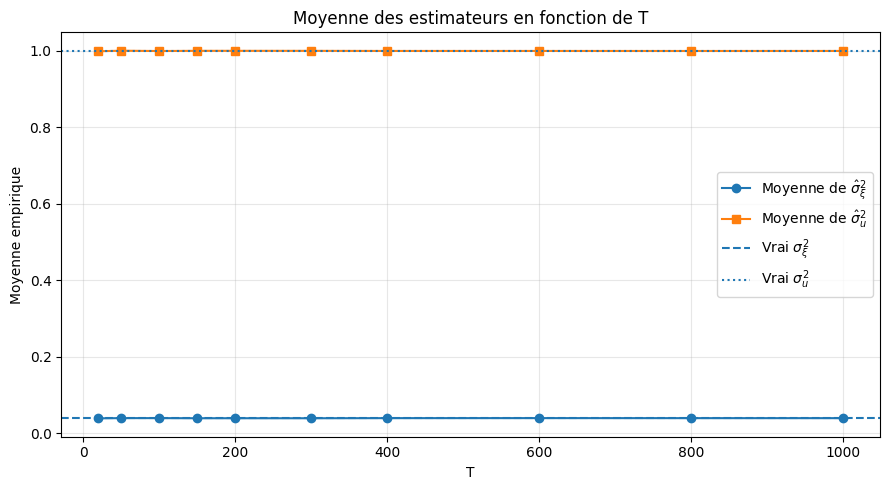

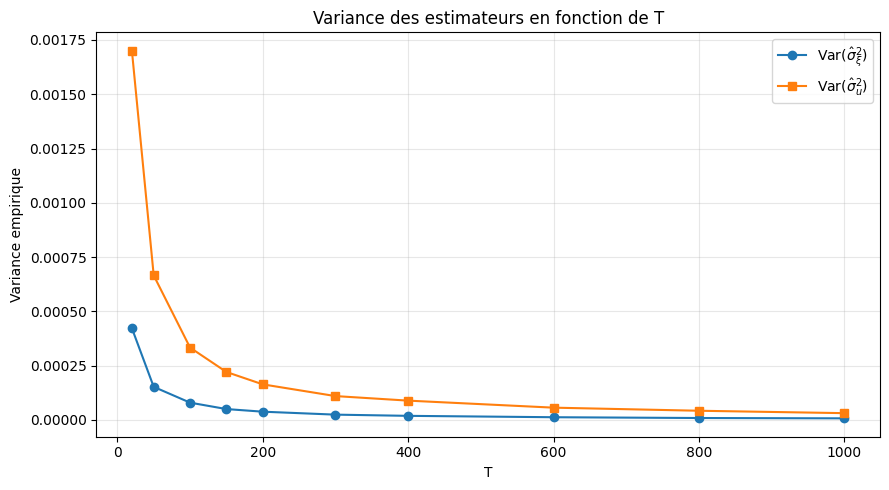

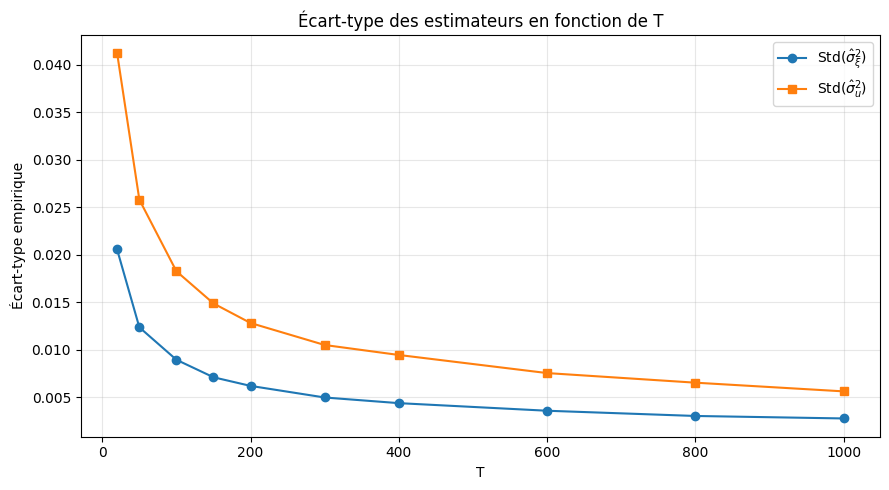

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def mc_results_vs_T_indep_seeds(list_T, N, MC,
                               sigma_xi2_true, sigma_u2_true,
                               seed=123, beta0=0.0, P0=1e6, burn_frac=0.2):

    bias_list, var_list, mse_list = [], [], []
    xi2_mean_list, u2_mean_list, succ_list = [], [], []

    # nouvelles listes : variance des estimateurs
    xi2_var_list, u2_var_list = [], []
    xi2_std_list, u2_std_list = [], []

    for j, T in enumerate(list_T):
        rng = np.random.default_rng(seed + 1000*j)
        burn = int(burn_frac * T)

        all_errors = []
        xi2_hats, u2_hats = [], []
        ok = 0

        for _ in range(MC):
            beta_true, Y = simulate_panel(T, N, sigma_xi2_true, sigma_u2_true, rng)

            sx2_hat, su2_hat, success = mle_params_panel(Y, beta0=beta0, P0=P0)
            if not success:
                continue

            ok += 1
            xi2_hats.append(sx2_hat)
            u2_hats.append(su2_hat)

            beta_hat, _ = kf_filter_panel(Y, sx2_hat, su2_hat, beta0=beta0, P0=P0)
            all_errors.extend(beta_hat[burn:] - beta_true[burn:])

        all_errors = np.array(all_errors)
        xi2_hats = np.array(xi2_hats)
        u2_hats = np.array(u2_hats)

        bias_list.append(all_errors.mean())
        var_list.append(all_errors.var(ddof=1))
        mse_list.append((all_errors**2).mean())

        xi2_mean_list.append(np.mean(xi2_hats))
        u2_mean_list.append(np.mean(u2_hats))

        # variance / écart-type des paramètres estimés
        xi2_var_list.append(np.var(xi2_hats, ddof=1))
        u2_var_list.append(np.var(u2_hats, ddof=1))

        xi2_std_list.append(np.std(xi2_hats, ddof=1))
        u2_std_list.append(np.std(u2_hats, ddof=1))

        succ_list.append(ok / MC)

    return (
        np.array(bias_list),
        np.array(var_list),
        np.array(mse_list),
        np.array(xi2_mean_list),
        np.array(u2_mean_list),
        np.array(xi2_var_list),
        np.array(u2_var_list),
        np.array(xi2_std_list),
        np.array(u2_std_list),
        np.array(succ_list)
    )


def plot_parameter_variance_vs_T(list_T, xi2_var_T, u2_var_T):
    plt.figure(figsize=(9, 5))
    plt.plot(list_T, xi2_var_T, marker="o", label=r"Var$(\hat{\sigma}_\xi^2)$")
    plt.plot(list_T, u2_var_T, marker="s", label=r"Var$(\hat{\sigma}_u^2)$")
    plt.xlabel("T")
    plt.ylabel("Variance empirique")
    plt.title("Variance des estimateurs en fonction de T")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_parameter_std_vs_T(list_T, xi2_std_T, u2_std_T):
    plt.figure(figsize=(9, 5))
    plt.plot(list_T, xi2_std_T, marker="o", label=r"Std$(\hat{\sigma}_\xi^2)$")
    plt.plot(list_T, u2_std_T, marker="s", label=r"Std$(\hat{\sigma}_u^2)$")
    plt.xlabel("T")
    plt.ylabel("Écart-type empirique")
    plt.title("Écart-type des estimateurs en fonction de T")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_parameter_means_vs_T(list_T, xi2_hat_T, u2_hat_T, sigma_xi2_true, sigma_u2_true):
    plt.figure(figsize=(9, 5))
    plt.plot(list_T, xi2_hat_T, marker="o", label=r"Moyenne de $\hat{\sigma}_\xi^2$")
    plt.plot(list_T, u2_hat_T, marker="s", label=r"Moyenne de $\hat{\sigma}_u^2$")
    plt.axhline(sigma_xi2_true, linestyle="--", label=r"Vrai $\sigma_\xi^2$")
    plt.axhline(sigma_u2_true, linestyle=":", label=r"Vrai $\sigma_u^2$")
    plt.xlabel("T")
    plt.ylabel("Moyenne empirique")
    plt.title("Moyenne des estimateurs en fonction de T")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":

    sigma_xi2_true = 0.04
    sigma_u2_true = 1.0

    N = 60
    MC = 2000
    list_T = [20, 50, 100, 150, 200, 300, 400, 600, 800, 1000]

    (
        bias_T, var_T, mse_T,
        xi2_hat_T, u2_hat_T,
        xi2_var_T, u2_var_T,
        xi2_std_T, u2_std_T,
        succ_T
    ) = mc_results_vs_T_indep_seeds(
        list_T=list_T,
        N=N,
        MC=MC,
        sigma_xi2_true=sigma_xi2_true,
        sigma_u2_true=sigma_u2_true,
        burn_frac=0.2
    )

    print("T:", list_T)
    print("Bias:", bias_T)
    print("Var :", var_T)
    print("MSE :", mse_T)
    print("sigma_xi2_hat mean:", xi2_hat_T)
    print("sigma_u2_hat mean:", u2_hat_T)
    print("Var(sigma_xi2_hat):", xi2_var_T)
    print("Var(sigma_u2_hat):", u2_var_T)
    print("success rate:", succ_T)

    plot_parameter_means_vs_T(list_T, xi2_hat_T, u2_hat_T, sigma_xi2_true, sigma_u2_true)
    plot_parameter_variance_vs_T(list_T, xi2_var_T, u2_var_T)
    plot_parameter_std_vs_T(list_T, xi2_std_T, u2_std_T)


T: [  20   50  100  150  200  300  400  600  800 1000]
xi2_mean: [0.043405 0.040335 0.039861 0.040034 0.039606 0.040231 0.039937 0.040031
 0.039971 0.040071]
xi2_bias: [ 3.405e-03  3.350e-04 -1.390e-04  3.400e-05 -3.940e-04  2.310e-04
 -6.300e-05  3.100e-05 -2.900e-05  7.100e-05]
xi2_var: [2.35575e-03 6.84780e-04 3.22320e-04 2.03370e-04 1.50850e-04 1.03180e-04
 7.18500e-05 4.55700e-05 3.57500e-05 2.84600e-05]
xi2_mse: [2.36617e-03 6.84550e-04 3.22170e-04 2.03270e-04 1.50930e-04 1.03180e-04
 7.18200e-05 4.55500e-05 3.57300e-05 2.84500e-05]

u2_mean: [0.995532 0.999697 0.999447 0.998457 1.00241  0.999245 0.999751 1.000037
 1.000593 0.999869]
u2_bias: [-4.468e-03 -3.030e-04 -5.530e-04 -1.543e-03  2.410e-03 -7.550e-04
 -2.490e-04  3.700e-05  5.930e-04 -1.310e-04]
u2_var: [0.02151719 0.00886979 0.00439443 0.00289949 0.00210467 0.00137523
 0.00109336 0.00072049 0.0005193  0.00044041]
u2_mse: [0.0215264  0.00886545 0.00439254 0.00290042 0.00210943 0.00137511
 0.00109288 0.00072013 0.00051939 

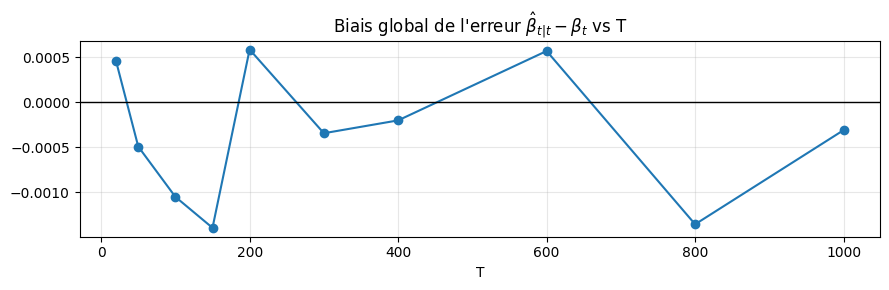

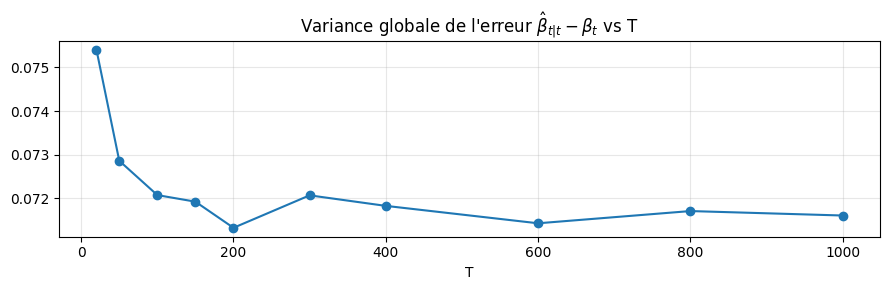

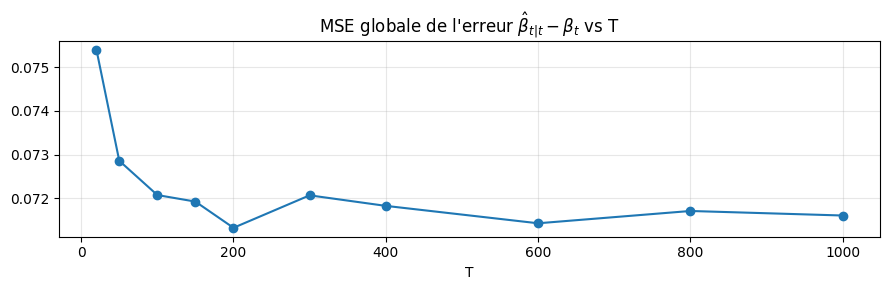

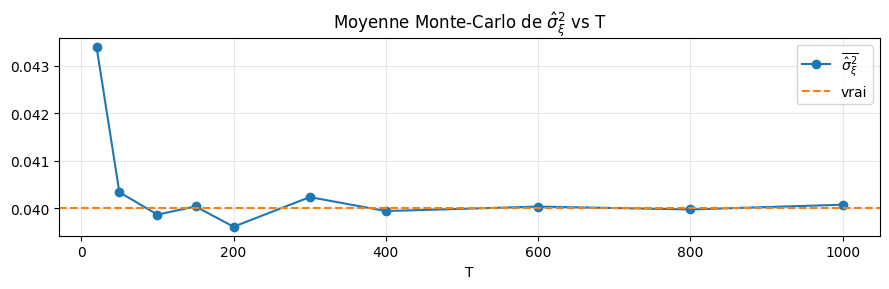

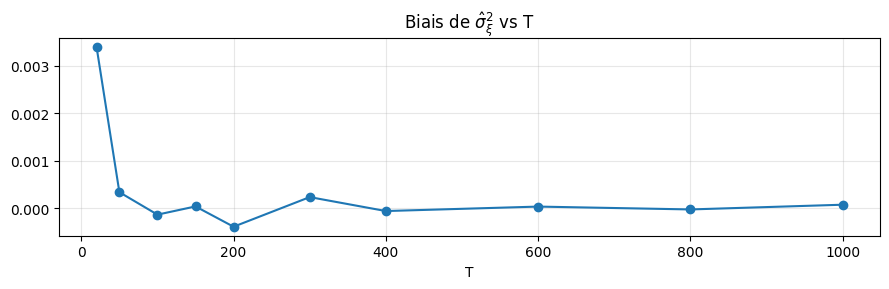

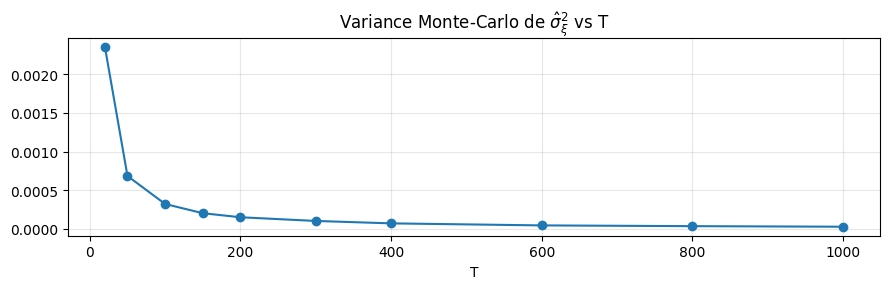

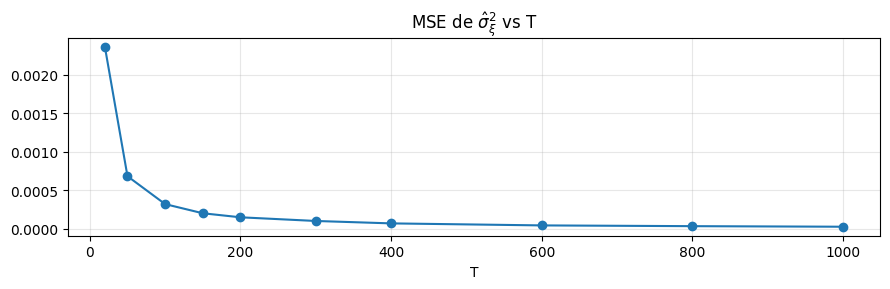

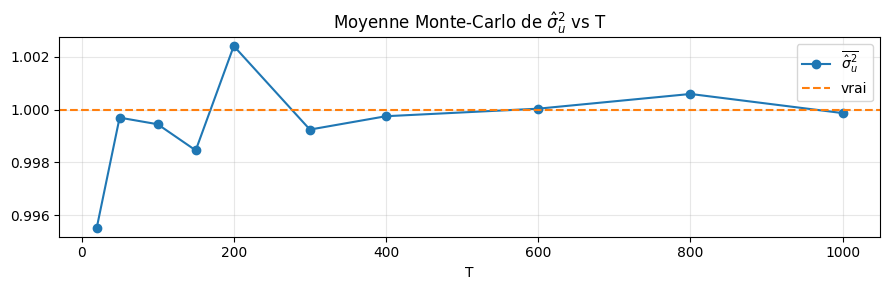

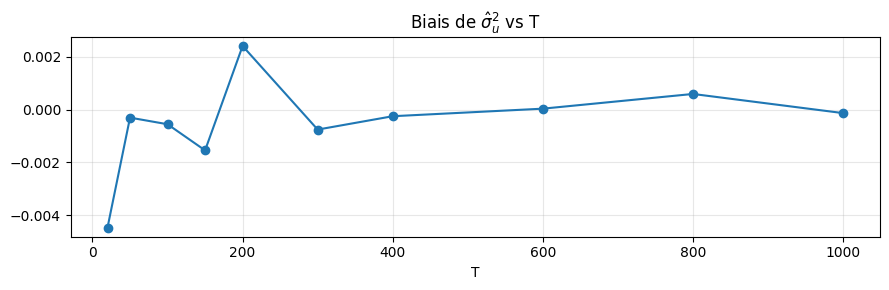

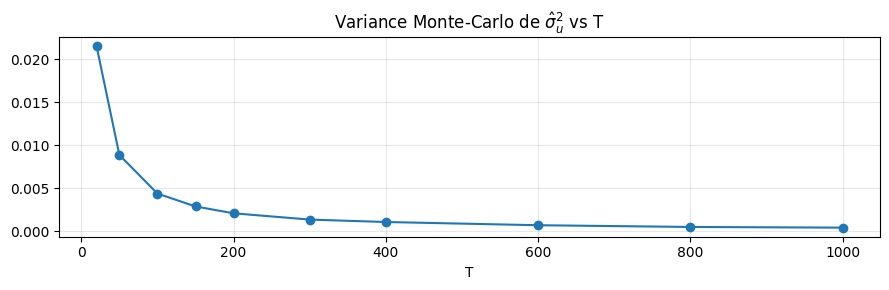

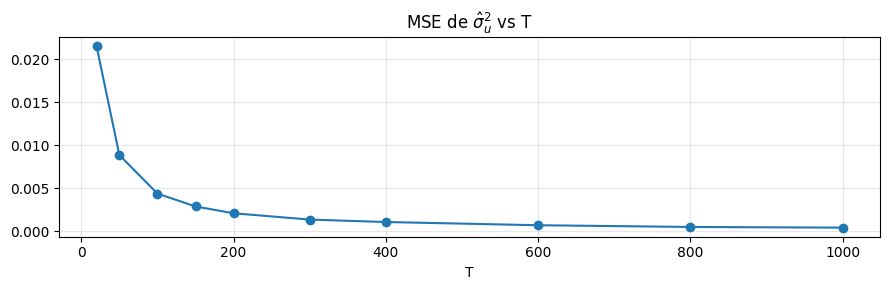

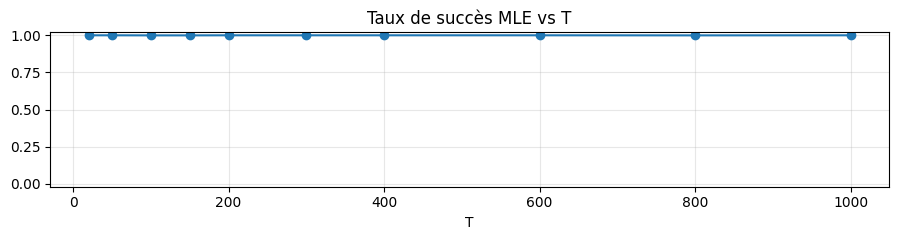

In [3]:
# --------------------------------------------------------
# Ajoute ce bloc après tes définitions existantes
# (simulate_panel, mle_params_panel, kf_filter_panel, ...)
# --------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def mc_results_vs_T_with_param_stats(list_T, N, MC,
                                     sigma_xi2_true, sigma_u2_true,
                                     seed=123, beta0=0.0, P0=1e6,
                                     burn_frac=0.2):
    """
    Monte-Carlo over different T:
      - bias/var/mse global of beta error (as before)
      - bias/var/mse for estimated params sigma_xi2 and sigma_u2
    Returns dict of arrays indexed by list_T.
    """
    # outputs for beta errors
    bias_list = []
    var_list  = []
    mse_list  = []

    # outputs for params
    xi2_mean = []
    xi2_bias = []
    xi2_var  = []
    xi2_mse  = []

    u2_mean = []
    u2_bias = []
    u2_var  = []
    u2_mse  = []

    success_rate = []

    for j, T in enumerate(list_T):
        # seed different per T to decorrelate experiments
        rng = np.random.default_rng(seed + 1000*j)
        burn = int(burn_frac * T)

        # collect across MC
        all_errors = []
        xi2_hats = []
        u2_hats  = []
        ok = 0

        for _ in range(MC):
            beta_true, Y = simulate_panel(T, N, sigma_xi2_true, sigma_u2_true, rng)

            # MLE des paramètres
            sx2_hat, su2_hat, success = mle_params_panel(Y, beta0=beta0, P0=P0)
            if not success:
                # skip replication if optimisation failed
                continue

            ok += 1
            xi2_hats.append(sx2_hat)
            u2_hats.append(su2_hat)

            # filtre (avec params estimés)
            beta_hat, _ = kf_filter_panel(Y, sx2_hat, su2_hat, beta0=beta0, P0=P0)

            # erreurs à partir du burn-in
            errs = beta_hat[burn:] - beta_true[burn:]
            all_errors.extend(errs)

        all_errors = np.array(all_errors)

        # === stats beta errors ===
        bias_list.append(np.mean(all_errors) if all_errors.size>0 else np.nan)
        var_list.append(np.var(all_errors, ddof=1) if all_errors.size>1 else np.nan)
        mse_list.append(np.mean(all_errors**2) if all_errors.size>0 else np.nan)

        # === stats params ===
        xi2_hats = np.array(xi2_hats)
        u2_hats  = np.array(u2_hats)

        success_rate.append(ok / MC)

        if xi2_hats.size == 0:
            xi2_mean.append(np.nan); xi2_bias.append(np.nan); xi2_var.append(np.nan); xi2_mse.append(np.nan)
        else:
            m_x = xi2_hats.mean()
            xi2_mean.append(m_x)
            xi2_bias.append(m_x - sigma_xi2_true)
            xi2_var.append(xi2_hats.var(ddof=1))
            xi2_mse.append(np.mean((xi2_hats - sigma_xi2_true)**2))

        if u2_hats.size == 0:
            u2_mean.append(np.nan); u2_bias.append(np.nan); u2_var.append(np.nan); u2_mse.append(np.nan)
        else:
            m_u = u2_hats.mean()
            u2_mean.append(m_u)
            u2_bias.append(m_u - sigma_u2_true)
            u2_var.append(u2_hats.var(ddof=1))
            u2_mse.append(np.mean((u2_hats - sigma_u2_true)**2))

    return {
        "T": np.array(list_T),
        "beta_bias": np.array(bias_list),
        "beta_var": np.array(var_list),
        "beta_mse": np.array(mse_list),
        "xi2_mean": np.array(xi2_mean),
        "xi2_bias": np.array(xi2_bias),
        "xi2_var": np.array(xi2_var),
        "xi2_mse": np.array(xi2_mse),
        "u2_mean": np.array(u2_mean),
        "u2_bias": np.array(u2_bias),
        "u2_var": np.array(u2_var),
        "u2_mse": np.array(u2_mse),
        "success_rate": np.array(success_rate)
    }


def plot_results_vs_T(stats, sigma_xi2_true, sigma_u2_true):
    T = stats["T"]

    # Beta error: bias / var / mse
    plt.figure(figsize=(9,3))
    plt.plot(T, stats["beta_bias"], marker="o")
    plt.axhline(0, linewidth=1, color="k")
    plt.title("Biais global de l'erreur $\hat\\beta_{t|t}-\\beta_t$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["beta_var"], marker="o")
    plt.title("Variance globale de l'erreur $\hat\\beta_{t|t}-\\beta_t$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["beta_mse"], marker="o")
    plt.title("MSE globale de l'erreur $\hat\\beta_{t|t}-\\beta_t$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # Param sigma_xi2 : mean, bias, var, mse
    plt.figure(figsize=(9,3))
    plt.plot(T, stats["xi2_mean"], marker="o", label=r"$\overline{\hat\sigma_\xi^2}$")
    plt.axhline(sigma_xi2_true, linestyle="--", color="C1", label="vrai")
    plt.title(r"Moyenne Monte-Carlo de $\hat\sigma_\xi^2$ vs T")
    plt.xlabel("T"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["xi2_bias"], marker="o")
    plt.title(r"Biais de $\hat\sigma_\xi^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["xi2_var"], marker="o")
    plt.title(r"Variance Monte-Carlo de $\hat\sigma_\xi^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["xi2_mse"], marker="o")
    plt.title(r"MSE de $\hat\sigma_\xi^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # Param sigma_u2 : mean, bias, var, mse
    plt.figure(figsize=(9,3))
    plt.plot(T, stats["u2_mean"], marker="o", label=r"$\overline{\hat\sigma_u^2}$")
    plt.axhline(sigma_u2_true, linestyle="--", color="C1", label="vrai")
    plt.title(r"Moyenne Monte-Carlo de $\hat\sigma_u^2$ vs T")
    plt.xlabel("T"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["u2_bias"], marker="o")
    plt.title(r"Biais de $\hat\sigma_u^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["u2_var"], marker="o")
    plt.title(r"Variance Monte-Carlo de $\hat\sigma_u^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,3))
    plt.plot(T, stats["u2_mse"], marker="o")
    plt.title(r"MSE de $\hat\sigma_u^2$ vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # success rate
    plt.figure(figsize=(9,2.5))
    plt.plot(T, stats["success_rate"], marker="o")
    plt.ylim(-0.02, 1.02)
    plt.title("Taux de succès MLE vs T")
    plt.xlabel("T"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# ---------------- RUN exemple ----------------
if __name__ == "__main__":
    list_T = [20, 50, 100, 150, 200, 300, 400, 600, 800, 1000]
    N = 5
    MC = 2000           # MC plus grand pour param stats
    Q_true = 0.04
    V_true = 1.0

    stats = mc_results_vs_T_with_param_stats(list_T, N, MC, Q_true, V_true,
                                            seed=123, burn_frac=0.2)

    # affichage synthétique
    print("T:", stats["T"])
    print("xi2_mean:", np.round(stats["xi2_mean"], 6))
    print("xi2_bias:", np.round(stats["xi2_bias"], 6))
    print("xi2_var:", np.round(stats["xi2_var"], 8))
    print("xi2_mse:", np.round(stats["xi2_mse"], 8))
    print()
    print("u2_mean:", np.round(stats["u2_mean"], 6))
    print("u2_bias:", np.round(stats["u2_bias"], 6))
    print("u2_var:", np.round(stats["u2_var"], 8))
    print("u2_mse:", np.round(stats["u2_mse"], 8))
    print("success rate:", np.round(stats["success_rate"], 3))

    # tracer les figures
    plot_results_vs_T(stats, Q_true, V_true)

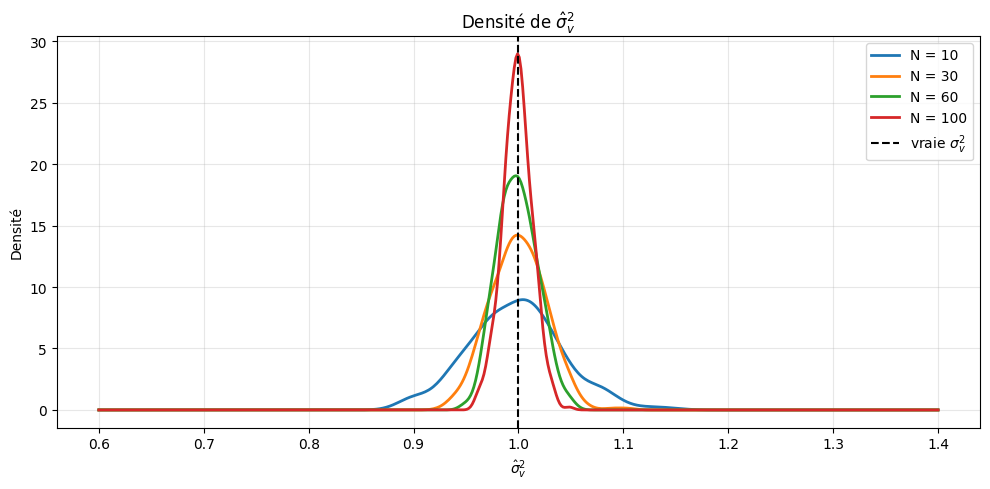

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gaussian_kde

# =====================================================
# Log-vraisemblance KF multivariée (sigma_xi2 connu)
# =====================================================

def kf_loglike_panel_sigma_u(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    T, N = Y.shape
    b = beta0
    P = P0
    ll = 0.0
    const = -0.5 * N * np.log(2*np.pi)

    for t in range(T):
        y = Y[t]
        e = y - b
        one_e = e.sum()
        ee = np.dot(e, e)

        logdetS = (N - 1)*np.log(sigma_u2) + np.log(sigma_u2 + N*P)
        quad = (ee / sigma_u2) - (P / (sigma_u2*(sigma_u2 + N*P))) * (one_e**2)

        ll += const - 0.5*(logdetS + quad)

        # KF update
        K = P / (sigma_u2 + N*P)
        b = b + K * one_e
        P = P * sigma_u2 / (sigma_u2 + N*P)

        # prediction
        P = P + sigma_xi2

    return ll


# =====================================================
# MLE de sigma_u^2 (sigma_xi^2 connu)
# =====================================================

def mle_sigma_u_panel(Y, sigma_xi2):
    def objective(log_su2):
        su2 = np.exp(log_su2)
        return -kf_loglike_panel_sigma_u(Y, sigma_xi2, su2)

    res = minimize(objective, x0=[0.0], method="L-BFGS-B")
    return np.exp(res.x[0])


# =====================================================
# Monte Carlo : distribution de sigma_u^2
# =====================================================

def mc_sigma_u2_distribution(N, T, MC, sigma_xi2, sigma_u2, seed=123):
    rng = np.random.default_rng(seed)
    samples = []

    for _ in range(MC):
        beta = np.zeros(T)
        for t in range(1, T):
            beta[t] = beta[t-1] + rng.normal(0, np.sqrt(sigma_xi2))

        U = rng.normal(0, np.sqrt(sigma_u2), size=(T, N))
        Y = beta[:, None] + U

        su2_hat = mle_sigma_u_panel(Y, sigma_xi2)
        samples.append(su2_hat)

    return np.array(samples)


# =====================================================
# PARAMÈTRES
# =====================================================

T = 100
MC = 400
sigma_xi2_true = 0.05
sigma_u2_true = 1.0

N_list = [10, 30, 60, 100]

# =====================================================
# SIMULATION
# =====================================================

densities = {}
for N in N_list:
    densities[N] = mc_sigma_u2_distribution(
        N, T, MC, sigma_xi2_true, sigma_u2_true
    )

# =====================================================
# GRAPHE DE DENSITÉ
# =====================================================

xs = np.linspace(0.6, 1.4, 500)

plt.figure(figsize=(10,5))

for N in N_list:
    kde = gaussian_kde(densities[N])
    plt.plot(xs, kde(xs), label=f"N = {N}", linewidth=2)

plt.axvline(sigma_u2_true, color="black", linestyle="--", label="vraie $\\sigma_v^2$")

plt.xlabel(r"$\hat{\sigma}_v^2$")
plt.ylabel("Densité")
plt.title(r"Densité de $\hat{\sigma}_v^2$ ")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


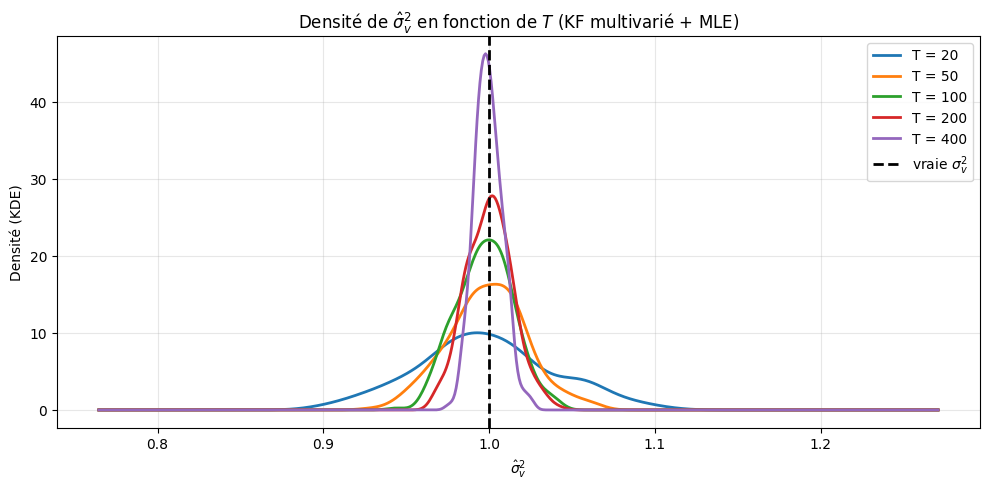

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gaussian_kde

# =====================================================
# Log-vraisemblance KF multivariée (sigma_xi2 connu)
# Modèle :
#   beta_t = beta_{t-1} + xi_t,  xi_t ~ N(0, sigma_xi2)
#   Y_t    = 1_N * beta_t + u_t, u_t  ~ N(0, sigma_u2 I_N)
# =====================================================

def kf_loglike_panel_sigma_u(Y, sigma_xi2, sigma_u2, beta0=0.0, P0=1e6):
    T, N = Y.shape
    b = beta0
    P = P0
    ll = 0.0
    const = -0.5 * N * np.log(2*np.pi)

    for t in range(T):
        y = Y[t]
        e = y - b
        one_e = e.sum()
        ee = np.dot(e, e)

        # S_t = sigma_u2 I_N + P 1 1'
        logdetS = (N - 1)*np.log(sigma_u2) + np.log(sigma_u2 + N*P)
        quad = (ee / sigma_u2) - (P / (sigma_u2*(sigma_u2 + N*P))) * (one_e**2)

        ll += const - 0.5*(logdetS + quad)

        # KF update (forme fermée, état scalaire)
        K = P / (sigma_u2 + N*P)
        b = b + K * one_e
        P = P * sigma_u2 / (sigma_u2 + N*P)

        # prediction
        P = P + sigma_xi2

    return ll


def mle_sigma_u2_panel(Y, sigma_xi2):
    # optimisation sur log(sigma_u2) pour garantir sigma_u2 > 0
    def objective(log_su2):
        su2 = np.exp(log_su2)
        return -kf_loglike_panel_sigma_u(Y, sigma_xi2, su2)

    res = minimize(objective, x0=[0.0], method="L-BFGS-B")
    return np.exp(res.x[0])


# =====================================================
# Simulation Monte-Carlo : distribution de sigma_u^2 pour un T donné
# =====================================================

def mc_sigma_u2_distribution_T(T, N, MC, sigma_xi2_true, sigma_u2_true, seed=123):
    rng = np.random.default_rng(seed)
    samples = []

    for _ in range(MC):
        # beta_t random walk
        beta = np.zeros(T)
        for t in range(1, T):
            beta[t] = beta[t-1] + rng.normal(0, np.sqrt(sigma_xi2_true))

        # panel Y_{t,i}
        U = rng.normal(0, np.sqrt(sigma_u2_true), size=(T, N))
        Y = beta[:, None] + U

        # MLE sigma_u^2
        su2_hat = mle_sigma_u2_panel(Y, sigma_xi2_true)
        samples.append(su2_hat)

    return np.array(samples)


# =====================================================
# PARAMÈTRES
# =====================================================

N_fixed = 60
MC = 300
sigma_xi2_true = 0.05
sigma_u2_true = 1.0

T_list = [20, 50, 100, 200, 400]

# =====================================================
# SIMULATION
# =====================================================

samples_by_T = {}
for T in T_list:
    samples_by_T[T] = mc_sigma_u2_distribution_T(
        T=T, N=N_fixed, MC=MC,
        sigma_xi2_true=sigma_xi2_true,
        sigma_u2_true=sigma_u2_true,
        seed=123 + T
    )

# =====================================================
# GRAPHE KDE
# =====================================================

# grille x adaptée aux valeurs simulées
all_samples = np.concatenate(list(samples_by_T.values()))
xmin = max(1e-6, all_samples.min() * 0.85)
xmax = all_samples.max() * 1.15
xs = np.linspace(xmin, xmax, 600)

plt.figure(figsize=(10,5))

for T in T_list:
    kde = gaussian_kde(samples_by_T[T])
    plt.plot(xs, kde(xs), linewidth=2, label=f"T = {T}")

plt.axvline(sigma_u2_true, color="black", linestyle="--", linewidth=2,
            label=r"vraie $\sigma_v^2$")

plt.xlabel(r"$\hat{\sigma}_v^2$")
plt.ylabel("Densité (KDE)")
plt.title(r"Densité de $\hat{\sigma}_v^2$ en fonction de $T$ (KF multivarié + MLE)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Part 2

moyenne sigma_u^2 (N=10)  : 1.0015634273795184
moyenne sigma_u^2 (N=100) : 1.0027245121705963


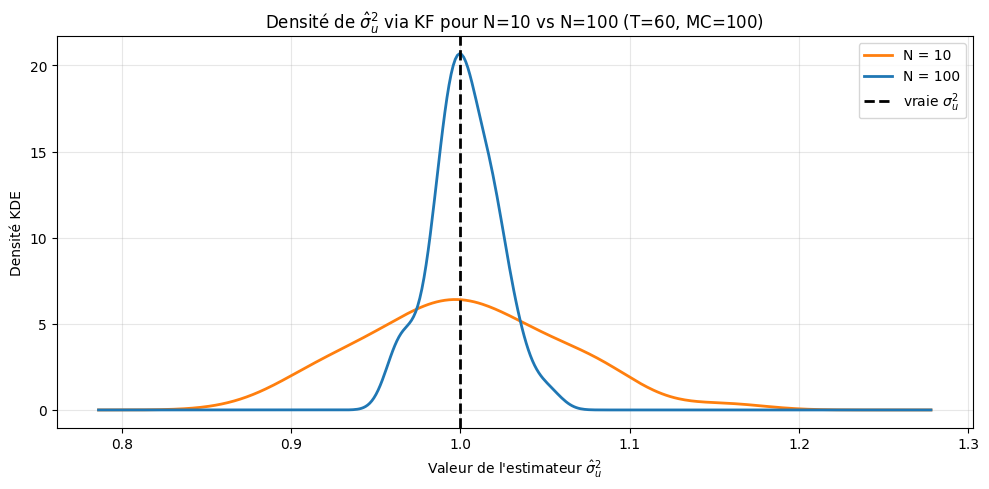

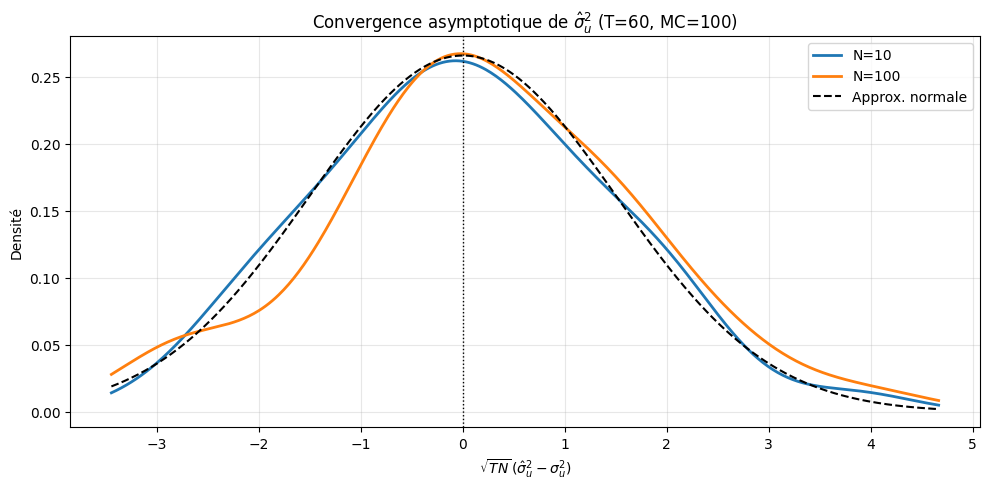

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import gaussian_kde

# =====================================================
# 1. Kalman FILTER avec données INDIVIDUELLES Y_it
#    (on boucle sur i = 1..N à chaque t)
# =====================================================

def kf_loglike_individual(Y, Q, su, beta0=0.0, P0=1e6):
    """
    Log-vraisemblance du modèle :
        beta_t = beta_{t-1} + xi_t,   xi_t ~ N(0, Q)
        Y_it   = beta_t + u_it,      u_it ~ N(0, su^2)
    en utilisant T x N données individuelles Y[t, i].

    On fait les mises à jour Kalman pour chaque individu i
    au même instant t.
    """
    T, N = Y.shape
    beta_pred = beta0
    P_pred = P0
    loglik = 0.0

    for t in range(T):
        # Mises à jour à l'instant t pour chacun des N individus
        for i in range(N):
            y_it = Y[t, i]
            e_it = y_it - beta_pred             # innovation
            S_it = P_pred + su**2               # variance de l'innovation
            loglik += -0.5 * (
                np.log(2*np.pi) + np.log(S_it) + (e_it**2) / S_it
            )
            K_it = P_pred / S_it                # gain de Kalman
            beta_pred = beta_pred + K_it * e_it
            P_pred = (1.0 - K_it) * P_pred

        # Prédiction pour t+1 (processus random walk)
        P_pred = P_pred + Q

    return loglik


def kf_filter_individual(Y, Q, su, beta0=0.0, P0=1e6):
    """
    Même modèle que ci-dessus, mais on renvoie la suite filtrée beta_{t|t}.
    """
    T, N = Y.shape
    beta_upd = np.zeros(T)
    P_upd = np.zeros(T)

    beta_pred = beta0
    P_pred = P0

    for t in range(T):
        # Updates successifs pour i = 1..N
        for i in range(N):
            y_it = Y[t, i]
            e_it = y_it - beta_pred
            S_it = P_pred + su**2
            K_it = P_pred / S_it
            beta_pred = beta_pred + K_it * e_it
            P_pred = (1.0 - K_it) * P_pred

        beta_upd[t] = beta_pred
        P_upd[t] = P_pred

        # prédiction pour t+1
        P_pred = P_pred + Q

    return beta_upd, P_upd


# =====================================================
# 2. MLE de sigma_u avec Q connu (via Kalman individuel)
# =====================================================

def mle_sigma_u_individual(Y, Q_true, beta0=0.0, P0=1e6):
    """
    Estime sigma_u par MLE en maximisant la log-vraisemblance
    donnée par kf_loglike_individual, en supposant Q = Q_true connu.
    On travaille sur log(su) pour imposer su > 0.
    """
    def objective(log_su):
        su = np.exp(log_su)  # su > 0
        return -kf_loglike_individual(Y, Q_true, su, beta0=beta0, P0=P0)

    x0 = np.array([0.0])  # départ sur log(1.0)
    res = minimize(objective, x0, method="L-BFGS-B")
    su_hat = np.exp(res.x[0])
    return su_hat


# =====================================================
# 3. Monte Carlo pour la distribution de sigma_u^2
#    avec données individuelles
# =====================================================

def mc_sigma_u2_individual(N, T=120, MC=500,
                           Q_true=0.04, su_true=1.0, seed=123):
    """
    MC réalisations de l’estimateur sigma_u^2 via :
      - simulation d’un panel Y_it (N obs / période)
      - estimation de sigma_u via MLE Kalman (Q fixé)
    """
    rng = np.random.default_rng(seed)
    sigma2_samples = []

    for _ in range(MC):
        # 1) simuler beta_t (random walk)
        beta = np.zeros(T)
        for t in range(1, T):
            beta[t] = beta[t-1] + rng.normal(0, np.sqrt(Q_true))

        # 2) simuler le panel Y_it
        U = rng.normal(0, su_true, size=(T, N))  # u_it
        Y = beta[:, None] + U                    # Y_it = beta_t + u_it

        # 3) MLE de sigma_u via Kalman individuel
        su_hat = mle_sigma_u_individual(Y, Q_true)
        sigma2_samples.append(su_hat**2)

    return np.array(sigma2_samples)


# =====================================================
# 4. Expérience : N petit vs N grand
# =====================================================

T = 60
MC = 100
N_small = 10
N_large = 100
Q_true = 0.05
su_true = 1.0

sigma2_small = mc_sigma_u2_individual(N_small, T=T, MC=MC,
                                      Q_true=Q_true, su_true=su_true, seed=123)
sigma2_large = mc_sigma_u2_individual(N_large, T=T, MC=MC,
                                      Q_true=Q_true, su_true=su_true, seed=456)

print("moyenne sigma_u^2 (N=10)  :", sigma2_small.mean())
print("moyenne sigma_u^2 (N=100) :", sigma2_large.mean())

# =====================================================
# 5. Tracé des densités (KDE)
# =====================================================

xs = np.linspace(
    min(sigma2_small.min(), sigma2_large.min()) * 0.9,
    max(sigma2_small.max(), sigma2_large.max()) * 1.1,
    400
)

kde_small = gaussian_kde(sigma2_small)
kde_large = gaussian_kde(sigma2_large)

plt.figure(figsize=(10, 5))
plt.plot(xs, kde_small(xs), label=f"N = {N_small}", color="tab:orange", linewidth=2)
plt.plot(xs, kde_large(xs), label=f"N = {N_large}", color="tab:blue", linewidth=2)

plt.axvline(su_true**2, color="k", linestyle="--", linewidth=2, label=r"vraie $\sigma_u^2$")

plt.xlabel(r"Valeur de l'estimateur $\hat{\sigma}_u^2$")
plt.ylabel("Densité KDE")
plt.title(
    rf"Densité de $\hat\sigma_u^2$ via KF pour N={N_small} vs N={N_large} "
    rf"(T={T}, MC={MC})"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
from scipy.stats import gaussian_kde, norm

# -----------------------------------------------------
# Transformation asymptotique
# -----------------------------------------------------
Z_small = np.sqrt(T * N_small) * (sigma2_small - su_true**2)
Z_large = np.sqrt(T * N_large) * (sigma2_large - su_true**2)

# Grille
xs = np.linspace(
    min(Z_small.min(), Z_large.min()) * 1.1,
    max(Z_small.max(), Z_large.max()) * 1.1,
    500
)

kde_small = gaussian_kde(Z_small)
kde_large = gaussian_kde(Z_large)

# -----------------------------------------------------
# Tracé
# -----------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(xs, kde_small(xs), label=f"N={N_small}", linewidth=2)
plt.plot(xs, kde_large(xs), label=f"N={N_large}", linewidth=2)

# Gaussienne standard (repère visuel)
plt.plot(xs, norm.pdf(xs, 0, np.std(Z_large)),
         "k--", label="Approx. normale")

plt.axvline(0, color="k", linestyle=":", linewidth=1)

plt.xlabel(r"$\sqrt{TN}\,(\hat\sigma_u^2 - \sigma_u^2)$")
plt.ylabel("Densité")
plt.title(
    rf"Convergence asymptotique de $\hat\sigma_u^2$ "
    rf"(T={T}, MC={MC})"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



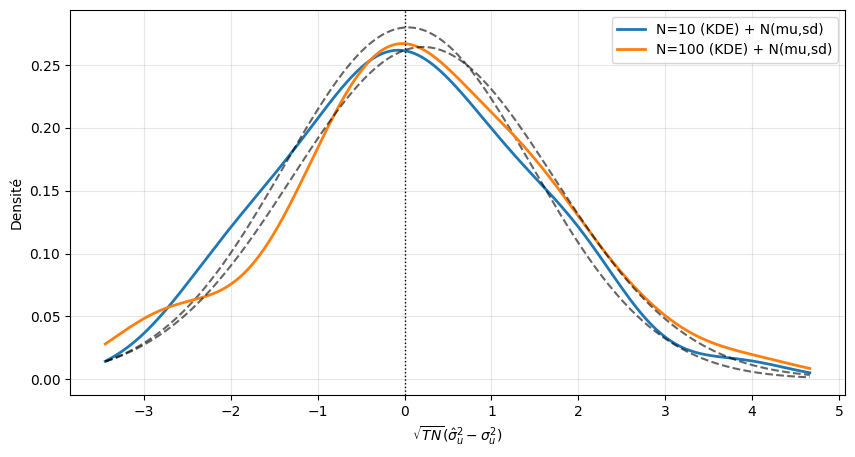


N=10
  mean=0.0383, std=1.4253
  skew=0.2209 (normal=0)
  kurtosis(excess)=-0.1467 (normal=0)
  KS stat=0.0475, p-value=0.9697

N=100
  mean=0.2110, std=1.5093
  skew=0.0393 (normal=0)
  kurtosis(excess)=0.1113 (normal=0)
  KS stat=0.0504, p-value=0.9501


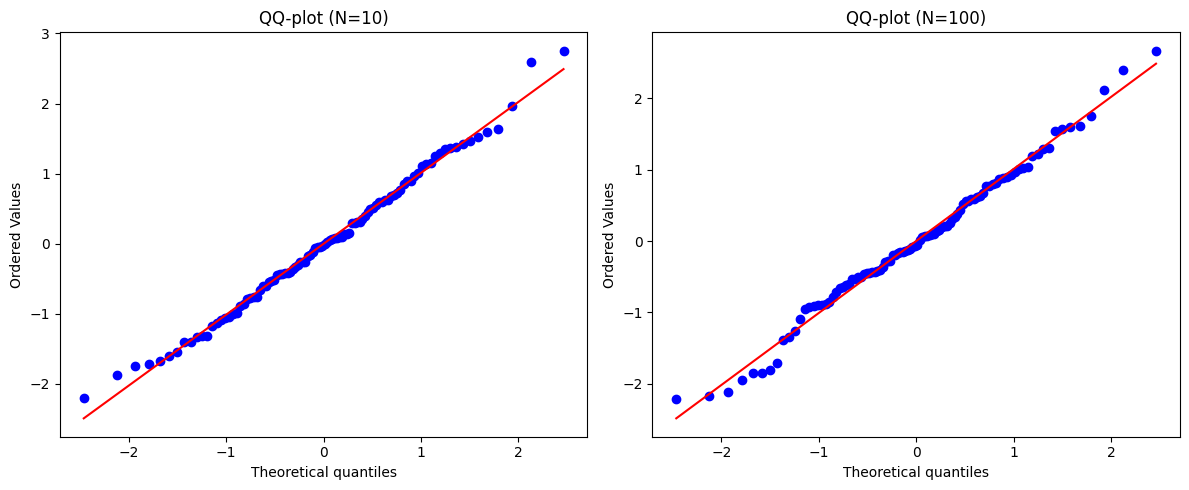

In [26]:
from scipy.stats import norm, gaussian_kde

def plot_kde_and_fitted_normal(Z, label, xs):
    kde = gaussian_kde(Z)
    mu, sd = Z.mean(), Z.std(ddof=1)
    plt.plot(xs, kde(xs), linewidth=2, label=label)
    plt.plot(xs, norm.pdf(xs, mu, sd), "k--", alpha=0.6)

xs = np.linspace(min(Z_small.min(), Z_large.min())*1.1,
                 max(Z_small.max(), Z_large.max())*1.1, 600)

plt.figure(figsize=(10,5))
plot_kde_and_fitted_normal(Z_small, "N=10 (KDE) + N(mu,sd)", xs)
plot_kde_and_fitted_normal(Z_large, "N=100 (KDE) + N(mu,sd)", xs)
plt.axvline(0, color="k", linestyle=":", linewidth=1)
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel(r"$\sqrt{TN}(\hat\sigma_u^2-\sigma_u^2)$")
plt.ylabel("Densité")
plt.show()
import scipy.stats as st
import matplotlib.pyplot as plt

def normal_diagnostics(Z, name):
    mu, sd = Z.mean(), Z.std(ddof=1)
    skew = st.skew(Z, bias=False)
    kurt = st.kurtosis(Z, fisher=True, bias=False)  # 0 si normal
    ks = st.kstest((Z - mu)/sd, 'norm')  # test sur version standardisée
    print(f"\n{name}")
    print(f"  mean={mu:.4f}, std={sd:.4f}")
    print(f"  skew={skew:.4f} (normal=0)")
    print(f"  kurtosis(excess)={kurt:.4f} (normal=0)")
    print(f"  KS stat={ks.statistic:.4f}, p-value={ks.pvalue:.4f}")

# diagnostics
normal_diagnostics(Z_small, "N=10")
normal_diagnostics(Z_large, "N=100")

# QQ-plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))
st.probplot((Z_small - Z_small.mean())/Z_small.std(ddof=1), dist="norm", plot=ax[0])
ax[0].set_title("QQ-plot (N=10)")

st.probplot((Z_large - Z_large.mean())/Z_large.std(ddof=1), dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot (N=100)")
plt.tight_layout()
plt.show()



# Part 3

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# ---------- Simulation ----------
def simulate_panel_student_t_with_outliers(T, N, Q_true, sigma_v2_true, nu,
                                          p_out=0.01, mult=20, seed=123):
    rng = np.random.default_rng(seed)

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))
        
    scale = np.sqrt(sigma_v2_true * (nu - 2.0) / nu)
    eps = student_t.rvs(df=nu, loc=0.0, scale=scale, size=(T, N), random_state=rng)

    # outliers rares EN PLUS
    #mask = rng.random((T, N)) < p_out
    #eps[mask] *= mult

    Z = beta_true[:, None] + eps
    return beta_true, Z

# ---------- KF oracle (gaussien) ----------
def kf_oracle_panel(Z, Q_true, sigma_v2_true, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2_true + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2_true / denom

        beta_hat[t] = b
        P = P + Q_true

    return beta_hat

import numpy as np

def dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=0.0):
    """
    Calcule:
      - beta_hat[t] = beta_t (valeur AVANT mise à jour avec u_t)
      - u[t] = u_t calculé à partir de Z_t et beta_t
      - zeta[t] = kappa * u_{t-1}  (innovation d'état à l'instant t)
    Remarque: zeta[0] = 0 (pas d'u_{-1})
    """
    T, N = Z.shape
    b = beta0

    beta_hat = np.zeros(T)
    u = np.zeros(T)
    zeta = np.zeros(T)

    for t in range(T):
        # stocke beta_t (avant mise à jour)
        beta_hat[t] = b

        # résidus e_t = z_t - 1_N * beta_t
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        # ω_t
        omega = 1.0 + ee / (nu * sigma_v2_true)

        # u_t selon (21)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2_true) * one_e
        u[t] = u_t

        # zeta_t = kappa * u_{t-1} (pour t=0 on laisse 0)
        if t >= 1:
            zeta[t] = kappa * u[t-1]
        else:
            zeta[t] = 0.0

        # mise à jour pour la période suivante : beta_{t+1} = beta_t + kappa * u_t
        b = b + kappa * u_t

    return beta_hat, u, zeta


def calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, beta0=0.0, kappa_init=0.01,
                         n_iter=100, burn_frac=0.2, var_floor=1e-8, damping=0.2):
    """
    Calibre kappa pour respecter sigma_xi^2 = kappa^2 Var(u_{t-1}).
    On estime Var(u_{t-1}) empiriquement à partir de la série u calculée
    par le filtre. Pour être cohérent avec zeta_t = kappa * u_{t-1},
    on prend la série u[:-1] (excluant le dernier u_T) après burn-in.
    """
    T, _ = Z.shape
    burn = int(burn_frac * T)

    kappa = float(kappa_init)
    for _ in range(n_iter):
        # calcule u avec la valeur courante de kappa
        _, u, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=beta0)

        # on retire burn-in; pour aligner zeta_t = kappa u_{t-1}, on prend u[:-1]
        if T - burn - 1 > 0:
            u_use = u[burn:-1]   # on enlève le dernier élément car u_{T-1} -> zeta_T
        else:
            # si on a trop peu de points, on prend ce qu'on a (sécurité)
            u_use = u[burn:]

        u_use = u_use - u_use.mean()
        var_u = float(np.mean(u_use**2)) if u_use.size > 0 else var_floor

        # stabilisation
        var_u = max(var_u, var_floor)

        kappa_new = np.sqrt(Q_true / var_u)

        # damping pour stabilité numérique
        kappa = (1.0 - damping) * kappa + damping * kappa_new

    return kappa

# ---------- Comparaison MC ----------
def compare_oracle_kf_vs_dcs_panel(T=300, N=60, MC=2000, Q_true=0.04, sigma_v2_true=1.0,
                                  nu=5, seed=123, burn_frac=0.2, plot_one=True):
    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    mse_kf, mse_dcs = [], []
    saved = None

    for _ in range(MC):
        beta_true, Z = simulate_panel_student_t_with_outliers(
            T, N, Q_true, sigma_v2_true, nu, seed=int(rng.integers(1, 10_000_000))
        )

        beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)

        # kappa calibré "comme le prof"
        kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, kappa_init=0.01, n_iter=10)
        
        beta_dcs, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)

        mse_kf.append(np.mean((beta_kf[burn:] - beta_true[burn:])**2))
        mse_dcs.append(np.mean((beta_dcs[burn:] - beta_true[burn:])**2))

        if plot_one and saved is None:
            saved = (beta_true, beta_kf, beta_dcs, kappa)

    mse_kf = np.array(mse_kf)
    mse_dcs = np.array(mse_dcs)

    print(f"nu={nu}, T={T}, N={N}, MC={MC}")
    print(f"KF  mean MSE={mse_kf.mean():.6f}, std={mse_kf.std():.6f}")
    print(f"DCS mean MSE={mse_dcs.mean():.6f}, std={mse_dcs.std():.6f}")

    if saved is not None:
        beta_true, beta_kf, beta_dcs, kappa = saved
        plt.figure(figsize=(10,5))
        plt.plot(beta_true, lw=2, label=r"$\beta_t$ vrai")
        plt.plot(beta_kf, "--", label="KF gaussien ")
        plt.plot(beta_dcs, "-.", label=rf"DCS-$t$ ( $\kappa$={kappa:.4f})")
        plt.title("KF vs DCS-$t$  — erreurs Student-$t$")
        plt.xlabel("t"); plt.ylabel(r"$\beta$")
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.boxplot([mse_kf, mse_dcs], labels=["KF ", "DCS-t "], showmeans=True)
        plt.ylabel("MSE sur $\\hat\\beta_t$ ")
        plt.title("Distribution du MSE : KF vs DCS-$t$ (paramètres vrais)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return mse_kf, mse_dcs

# ---- RUN ----
if __name__ == "__main__":
    compare_oracle_kf_vs_dcs_panel(T=200, N=60, MC=2000, Q_true=0.04, sigma_v2_true=1.0, nu=5)



ValueError: too many values to unpack (expected 2)

nu=50, T=500, N=5, MC=2000
KF  mean MSE=0.001901, std=0.000137
DCS mean MSE=0.023541, std=0.002092


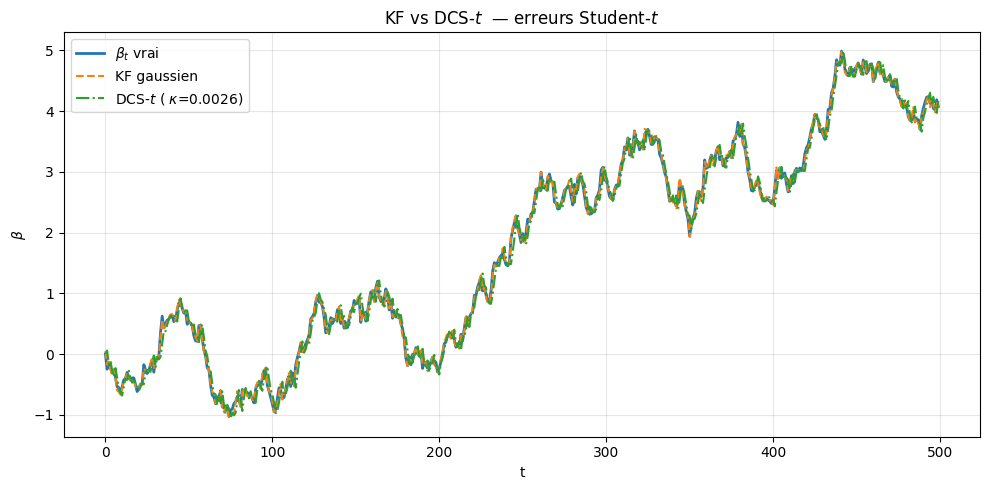

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_14848\3406543333.py:179: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mse_kf, mse_dcs], labels=["KF ", "DCS-t "], showmeans=True)


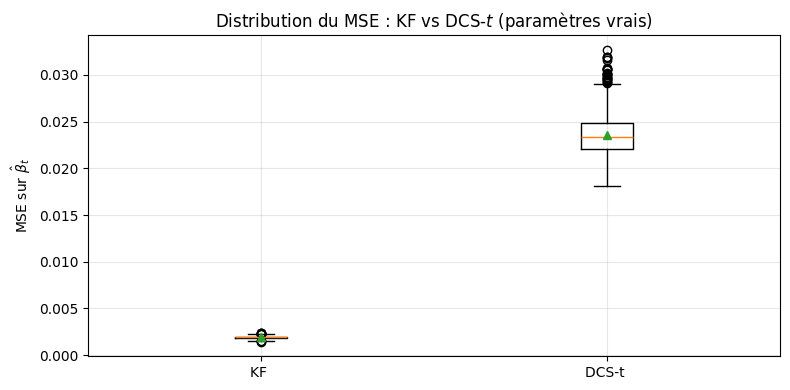

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# ---------- Simulation ----------
def simulate_panel_student_t_with_outliers(T, N, Q_true, sigma_v2_true, nu,
                                          seed=123):
    rng = np.random.default_rng(seed)
    seed_int = int(rng.integers(1, 1_000_000_000))

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))
    
    # inside simulate_panel_student_t_with_outliers
    
   
    scale = np.sqrt(sigma_v2_true )
    eps = student_t.rvs(df=nu, loc=0.0, scale=scale, size=(T, N), random_state=seed_int)

    # outliers rares EN PLUS


    Z = beta_true[:, None] + eps
    return beta_true, Z


# ---------- KF oracle (gaussien) ----------
def kf_oracle_panel(Z, Q_true, sigma_v2_true, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2_true + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2_true / denom

        beta_hat[t] = b
        P = P + Q_true

    return beta_hat

def dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=0.0):
    """
    Retourne (beta_pred, beta_post, u, zeta) :
      - beta_pred[t] = beta_{t|t-1} (avant mise à jour)
      - beta_post[t] = beta_{t|t}   (après mise à jour beta_t = beta_{t-1} + kappa u_{t-1})
      - u[t] = u_t calculé à partir de e_t = Z_t - 1_N * beta_t
      - zeta[t] = kappa * u_{t-1}
    Conventions: u_{-1} = 0, beta0 is used as b_{-1} (ou choix d'initialisation).
    """
    T, N = Z.shape
    # initialize
    b_prev = beta0         # represents beta_{t-1} at iteration t
    u_prev = 0.0           # u_{t-1}, start with 0
    beta_pred = np.zeros(T)
    beta_post = np.zeros(T)
    u = np.zeros(T)
    zeta = np.zeros(T)

    for t in range(T):
        # prior for time t
        beta_pred[t] = b_prev

        # apply state innovation from previous score: beta_t = beta_{t-1} + kappa * u_{t-1}
        beta_t = b_prev + kappa * u_prev
        beta_post[t] = beta_t

        # zeta_t = kappa * u_{t-1}
        zeta[t] = kappa * u_prev

        # compute residuals using beta_t (conformément aux eq. du papier)
        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        # omega_t and u_t per (20)-(21)
        omega = 1.0 + ee / (nu * sigma_v2_true)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2_true) * one_e
        u[t] = u_t

        # prepare for next iteration
        b_prev = beta_t
        u_prev = u_t

    return beta_pred, beta_post, u, zeta


def calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, beta0=0.0, kappa_init=0.01,
                         n_iter=100, burn_frac=0.2, var_floor=1e-8):
    """
    Calibre kappa pour sigma_xi^2 = kappa^2 Var(u_{t-1}).
    Utilise la signature mise à jour de dcs_t_filter_and_u.
    """
    T, _ = Z.shape
    burn = int(burn_frac * T)

    kappa = float(kappa_init)
    for _ in range(n_iter):
        # on récupère u via la nouvelle signature
        _, _, u, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=beta0)
       

        # pour aligner zeta_t = kappa u_{t-1}, on prend u[:-1] après burn
        #if T - burn - 1 > 0:
        u_use = u[burn:-1]
        #else:
        #u_use = u[burn:]

        # centrage + variance (MLE)
        
        u_use = u_use - u_use.mean()
        var_u = float(np.mean(u_use**2))
       

        

        kappa_new = np.sqrt(Q_true / var_u)
        kappa = kappa_new

    return kappa




# ---------- Comparaison MC ----------
def compare_oracle_kf_vs_dcs_panel(T=300, N=60, MC=2000, Q_true=0.04, sigma_v2_true=1.0,
                                  nu=5, seed=123, burn_frac=0.2, plot_one=True):
    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    mse_kf, mse_dcs = [], []
    saved = None

    for _ in range(MC):
        beta_true, Z = simulate_panel_student_t_with_outliers(
            T, N, Q_true, sigma_v2_true, nu, seed=int(rng.integers(1, 10_000_000))
        )
        
    
        beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)

        # kappa calibré "comme le prof"
                # kappa calibré "comme le prof"
        kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, kappa_init=0.01, n_iter=10)
        
        # <-- déballage : on récupère le posterior DCS (beta_post)
        _, beta_dcs_post, u, zeta = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)
       
        mse_kf.append(np.mean((beta_kf[burn:] - beta_true[burn:])**2))
        mse_dcs.append(np.mean((beta_dcs_post[burn:] - beta_true[burn:])**2))

        if plot_one and saved is None:
            saved = (beta_true, beta_kf, beta_dcs_post, u,kappa)

    mse_kf = np.array(mse_kf)
    mse_dcs = np.array(mse_dcs)

    print(f"nu={nu}, T={T}, N={N}, MC={MC}")
    print(f"KF  mean MSE={mse_kf.mean():.6f}, std={mse_kf.std():.6f}")
    print(f"DCS mean MSE={mse_dcs.mean():.6f}, std={mse_dcs.std():.6f}")

    if saved is not None:
        beta_true, beta_kf, beta_dcs, u,kappa = saved
        plt.figure(figsize=(10,5))
        plt.plot(beta_true, lw=2, label=r"$\beta_t$ vrai")
        plt.plot(beta_kf, "--", label="KF gaussien ")
        plt.plot(beta_dcs, "-.", label=rf"DCS-$t$ ( $\kappa$={kappa:.4f})")
        plt.title("KF vs DCS-$t$  — erreurs Student-$t$")
        plt.xlabel("t"); plt.ylabel(r"$\beta$")
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.boxplot([mse_kf, mse_dcs], labels=["KF ", "DCS-t "], showmeans=True)
        plt.ylabel("MSE sur $\\hat\\beta_t$ ")
        plt.title("Distribution du MSE : KF vs DCS-$t$ (paramètres vrais)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        

        burn = int(0.2 * len(beta_true))


        

    return mse_kf, mse_dcs

# ---- RUN ----
if __name__ == "__main__":
    compare_oracle_kf_vs_dcs_panel(T=500, N=5, MC=2000, Q_true=0.02, sigma_v2_true=0.01, nu=50)

In [21]:

def sweep_nu_N(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=200):
    out = {}
    Q_true = 0.04
    sigma_v2_true = 1.0
    for N in N_list:
        for nu in nu_list:
            mse_kf = []; mse_dcs = []
            for _ in range(MC):
                beta_true, Z = simulate_panel_student_t_with_outliers(T, N, Q_true, sigma_v2_true, nu,
                                                                      seed=None)
                beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)
                kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu,
                                             kappa_init=0.01, n_iter=10)
                _, beta_dcs_post, _, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)
                burn = int(0.2*T)
                mse_kf.append(np.mean((beta_kf[burn:]-beta_true[burn:])**2))
                mse_dcs.append(np.mean((beta_dcs_post[burn:]-beta_true[burn:])**2))
            out[(N,nu)] = (np.mean(mse_kf), np.mean(mse_dcs))
            print(f"N={N}, nu={nu}: KF={out[(N,nu)][0]:.4f}, DCS={out[(N,nu)][1]:.4f}")
    return out
sweep_nu_N(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=200)

N=5, nu=3: KF=0.1584, DCS=0.1522
N=5, nu=5: KF=0.0999, DCS=0.1358
N=5, nu=10: KF=0.0822, DCS=0.1237
N=5, nu=20: KF=0.0758, DCS=0.1162
N=5, nu=50: KF=0.0734, DCS=0.1147
N=20, nu=3: KF=0.0693, DCS=0.0961
N=20, nu=5: KF=0.0422, DCS=0.0842
N=20, nu=10: KF=0.0342, DCS=0.0763
N=20, nu=20: KF=0.0322, DCS=0.0740
N=20, nu=50: KF=0.0299, DCS=0.0700
N=40, nu=3: KF=0.0430, DCS=0.0769
N=40, nu=5: KF=0.0263, DCS=0.0685
N=40, nu=10: KF=0.0206, DCS=0.0625
N=40, nu=20: KF=0.0190, DCS=0.0611
N=40, nu=50: KF=0.0180, DCS=0.0595
N=60, nu=3: KF=0.0333, DCS=0.0701
N=60, nu=5: KF=0.0197, DCS=0.0615
N=60, nu=10: KF=0.0151, DCS=0.0576
N=60, nu=20: KF=0.0139, DCS=0.0548
N=60, nu=50: KF=0.0129, DCS=0.0535
N=100, nu=3: KF=0.0223, DCS=0.0624
N=100, nu=5: KF=0.0129, DCS=0.0537
N=100, nu=10: KF=0.0101, DCS=0.0518
N=100, nu=20: KF=0.0089, DCS=0.0497
N=100, nu=50: KF=0.0085, DCS=0.0490


{(5, 3): (np.float64(0.15838162733260566), np.float64(0.15220103961009912)),
 (5, 5): (np.float64(0.09992720438355923), np.float64(0.13577688036762203)),
 (5, 10): (np.float64(0.08222903114830488), np.float64(0.12366699448373641)),
 (5, 20): (np.float64(0.0758320435493562), np.float64(0.11615457052621272)),
 (5, 50): (np.float64(0.07341423264633525), np.float64(0.11473631318052437)),
 (20, 3): (np.float64(0.06927490514469069), np.float64(0.09611719662707756)),
 (20, 5): (np.float64(0.04224207564793469), np.float64(0.0841606503189216)),
 (20, 10): (np.float64(0.03420996191476235), np.float64(0.07630873774497583)),
 (20, 20): (np.float64(0.032166702837029784), np.float64(0.07402847277531042)),
 (20, 50): (np.float64(0.029895630366963015), np.float64(0.06996520653669767)),
 (40, 3): (np.float64(0.04301745206448974), np.float64(0.07691693424772582)),
 (40, 5): (np.float64(0.026316501080584774), np.float64(0.0684708099581802)),
 (40, 10): (np.float64(0.02055763508162809), np.float64(0.06248

In [ ]:
def sweep_nu_N(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=500):
    out = {}
    Q_true = 0.04
    sigma_v2_true = 1.0
    rng = np.random.default_rng(12345)

    for N in N_list:
        for nu in nu_list:

            err_kf = []
            err_dcs = []

            for _ in range(MC):
                seed_sim = int(rng.integers(1, 10_000_000))
                beta_true, Z = simulate_panel_student_t_coherent(
                    T, N, Q_true, sigma_v2_true, nu, seed=seed_sim
                )

                sigma_v2_eff = sigma_v2_true * nu / (nu - 2)
                beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_eff)

                kappa = calibrate_kappa_prof(
                    Z, Q_true, sigma_v2_true, nu,
                    kappa_init=0.01, n_iter=10
                )

                _, beta_dcs_post, _, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)

                burn = int(0.2 * T)

                err_kf.extend(beta_kf[burn:] - beta_true[burn:])
                err_dcs.extend(beta_dcs_post[burn:] - beta_true[burn:])

            err_kf = np.array(err_kf)
            err_dcs = np.array(err_dcs)

            mse_kf = np.mean(err_kf**2)
            bias_kf = np.mean(err_kf)
            var_kf = np.var(err_kf)

            mse_dcs = np.mean(err_dcs**2)
            bias_dcs = np.mean(err_dcs)
            var_dcs = np.var(err_dcs)

            out[(N,nu)] = (mse_kf, bias_kf, var_kf,
                           mse_dcs, bias_dcs, var_dcs)

            print(f"N={N}, nu={nu}")
            print(f" KF : MSE={mse_kf:.4f} Bias={bias_kf:.4f} Var={var_kf:.4f}")
            print(f" DCS : MSE={mse_dcs:.4f} Bias={bias_dcs:.4f} Var={var_dcs:.4f}")
            print("-"*50)

    return out

sweep_nu_N(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=1000)

N=5, nu=3
 KF : MSE=0.1330 Bias=-0.0015 Var=0.1330
 DCS : MSE=0.1363 Bias=0.0006 Var=0.1363
--------------------------------------------------
N=5, nu=5
 KF : MSE=0.0973 Bias=0.0020 Var=0.0973
 DCS : MSE=0.1263 Bias=0.0011 Var=0.1263
--------------------------------------------------
N=5, nu=10
 KF : MSE=0.0829 Bias=0.0028 Var=0.0829
 DCS : MSE=0.1214 Bias=0.0031 Var=0.1214
--------------------------------------------------
N=5, nu=20
 KF : MSE=0.0770 Bias=0.0000 Var=0.0770
 DCS : MSE=0.1180 Bias=0.0002 Var=0.1180
--------------------------------------------------
N=5, nu=50
 KF : MSE=0.0737 Bias=-0.0009 Var=0.0737
 DCS : MSE=0.1143 Bias=-0.0014 Var=0.1143
--------------------------------------------------
N=20, nu=3
 KF : MSE=0.0587 Bias=-0.0008 Var=0.0587
 DCS : MSE=0.0856 Bias=0.0011 Var=0.0856
--------------------------------------------------
N=20, nu=5
 KF : MSE=0.0404 Bias=0.0021 Var=0.0404
 DCS : MSE=0.0790 Bias=0.0031 Var=0.0790
------------------------------------------------

{(5, 3): (np.float64(0.13296143946851802),
  np.float64(-0.00148228509617856),
  np.float64(0.13295924229941167),
  np.float64(0.13625277533008084),
  np.float64(0.0005524842775872766),
  np.float64(0.13625247009120384)),
 (5, 5): (np.float64(0.09730255837704999),
  np.float64(0.001996435257992517),
  np.float64(0.09729857262331064),
  np.float64(0.12628847579634),
  np.float64(0.001061948993348285),
  np.float64(0.12628734806067551)),
 (5, 10): (np.float64(0.08293894860710452),
  np.float64(0.0027731225976196823),
  np.float64(0.08293125839816308),
  np.float64(0.12136400330372758),
  np.float64(0.0030640974607510983),
  np.float64(0.1213546146104786)),
 (5, 20): (np.float64(0.0769686065494931),
  np.float64(3.117718307157622e-05),
  np.float64(0.07696860557747635),
  np.float64(0.11803382726135837),
  np.float64(0.00020545017897900114),
  np.float64(0.11803378505158235)),
 (5, 50): (np.float64(0.07370944384981995),
  np.float64(-0.0009437667410944629),
  np.float64(0.0737085531541583

In [24]:
def sweep_nu_T(nu_list=[3,5,10,20,50],
               T_list=[50,100,200,400,800,1000],
               N=40, MC=500):

    out = {}
    Q_true = 0.04
    sigma_v2_true = 1.0

    for T in T_list:
        for nu in nu_list:

            err_kf = []
            err_dcs = []

            for _ in range(MC):

                beta_true, Z = simulate_panel_student_t_with_outliers(
                    T, N, Q_true, sigma_v2_true, nu, seed=None
                )

                # ---- Oracle KF
                beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)

                # ---- Oracle DCS
                kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu,
                                             kappa_init=0.01, n_iter=10)

                _, beta_dcs_post, _, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)

                burn = int(0.2*T)

                err_kf.extend(beta_kf[burn:] - beta_true[burn:])
                err_dcs.extend(beta_dcs_post[burn:] - beta_true[burn:])

            err_kf = np.array(err_kf)
            err_dcs = np.array(err_dcs)

            # ---- KF stats
            mse_kf = np.mean(err_kf**2)
            bias_kf = np.mean(err_kf)
            var_kf = np.var(err_kf)

            # ---- DCS stats
            mse_dcs = np.mean(err_dcs**2)
            bias_dcs = np.mean(err_dcs)
            var_dcs = np.var(err_dcs)

            out[(T,nu)] = (mse_kf, bias_kf, var_kf,
                           mse_dcs, bias_dcs, var_dcs)

            print(f"T={T}, nu={nu}")
            print(f" KF : MSE={mse_kf:.4f} Bias={bias_kf:.4f} Var={var_kf:.4f}")
            print(f" DCS : MSE={mse_dcs:.4f} Bias={bias_dcs:.4f} Var={var_dcs:.4f}")
            print("-"*50)

    return out
sweep_nu_T()

T=50, nu=3
 KF : MSE=0.0174 Bias=-0.0011 Var=0.0174
 DCS : MSE=0.0601 Bias=-0.0057 Var=0.0601
--------------------------------------------------
T=50, nu=5
 KF : MSE=0.0173 Bias=-0.0004 Var=0.0173
 DCS : MSE=0.0596 Bias=-0.0008 Var=0.0596
--------------------------------------------------
T=50, nu=10
 KF : MSE=0.0174 Bias=-0.0021 Var=0.0174
 DCS : MSE=0.0599 Bias=-0.0004 Var=0.0599
--------------------------------------------------
T=50, nu=20
 KF : MSE=0.0175 Bias=-0.0009 Var=0.0175
 DCS : MSE=0.0589 Bias=-0.0015 Var=0.0589
--------------------------------------------------
T=50, nu=50
 KF : MSE=0.0176 Bias=-0.0011 Var=0.0176
 DCS : MSE=0.0590 Bias=-0.0023 Var=0.0590
--------------------------------------------------
T=100, nu=3
 KF : MSE=0.0180 Bias=0.0015 Var=0.0180
 DCS : MSE=0.0603 Bias=0.0034 Var=0.0603
--------------------------------------------------
T=100, nu=5
 KF : MSE=0.0173 Bias=0.0000 Var=0.0173
 DCS : MSE=0.0603 Bias=-0.0011 Var=0.0603
----------------------------------

{(50, 3): (np.float64(0.0173929151020637),
  np.float64(-0.0011458918528914857),
  np.float64(0.017391602033925174),
  np.float64(0.0601408815030337),
  np.float64(-0.005674653198530206),
  np.float64(0.06010867981411011)),
 (50, 5): (np.float64(0.017281728373409338),
  np.float64(-0.0003582950857678572),
  np.float64(0.017281599998040856),
  np.float64(0.05962226367599275),
  np.float64(-0.0007892362507103668),
  np.float64(0.05962164078213332)),
 (50, 10): (np.float64(0.017376483426266038),
  np.float64(-0.0021314821307655044),
  np.float64(0.017371940210192265),
  np.float64(0.05993340427581637),
  np.float64(-0.000428660311884679),
  np.float64(0.05993322052615339)),
 (50, 20): (np.float64(0.017451372102602197),
  np.float64(-0.0009173871597472786),
  np.float64(0.017450530503401326),
  np.float64(0.05889075620739018),
  np.float64(-0.0015466297301442715),
  np.float64(0.05888836414386801)),
 (50, 50): (np.float64(0.01764409727323013),
  np.float64(-0.0011496245583181143),
  np.flo

# version mle safe explose pas mais prend bcp du temp

PARTIE 2 (MLE) — T=200, N=5, MC=300, nu_true=10000
KF mean MSE=0.070139, std=0.012176
DCS mean MSE=0.109673, std=0.019088


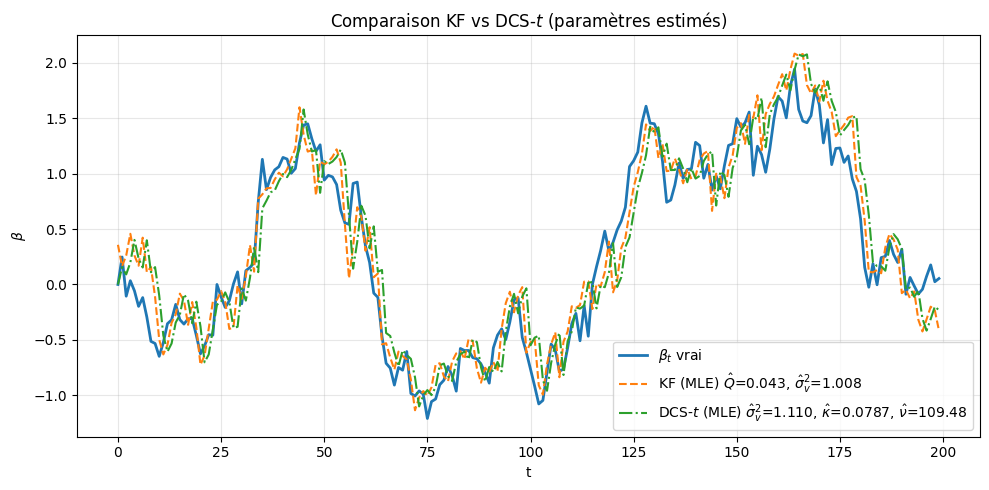

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_18048\581480238.py:445: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mse_kf, mse_dcs], labels=["KF (MLE)", "DCS-t (MLE)"], showmeans=True)


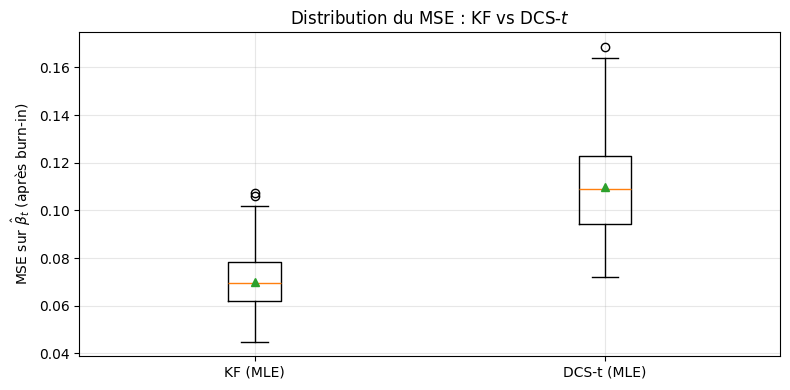

K_inf approx (dernier gain) = 0.073648
kappa_hat / sigma_v2_dcs = 0.070952


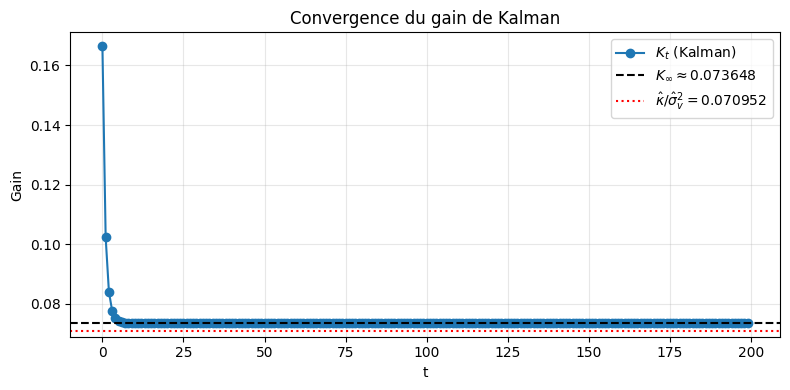

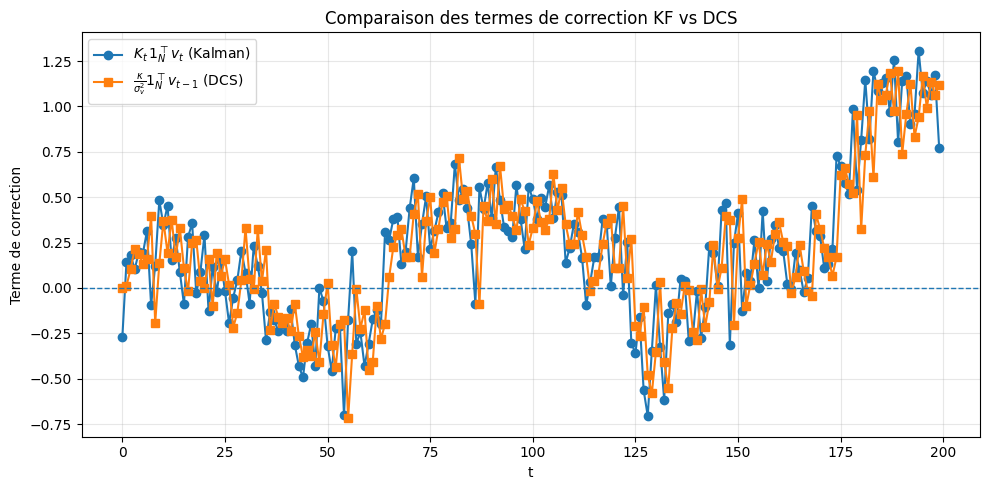

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln  # log Gamma
from scipy.stats import t as student_t

# =========================================================
# 0) Simulation panel (RW gaussien + erreurs Student-t + outliers optionnels)
# =========================================================
def contaminate_clusters(V, p_start=0.02, duration=6, mult=20.0, seed=None):
   
    rng = np.random.default_rng(seed)
    V2 = V.copy()
    T, N = V.shape
    t = 0
    while t < T:
        if rng.random() < p_start:
            end = min(T, t + duration)
            # contaminer toutes les observations (shock commun) pendant la crise
            V2[t:end, :] = V2[t:end, :] * mult
            t = end  # sauter jusqu'à la fin de la crise
        else:
            t += 1
    return V2

# =========================================================
# 0) Simulation panel : beta_t RW gaussien + erreurs Student-t multivariées cohérentes
# =========================================================
def simulate_panel_student_t_coherent(T, N, Q_true, sigma_v2_true, nu_true, seed=123):
    """
    Simulation cohérente avec la log-vraisemblance Student-t multivariée utilisée dans DCS.

    beta_t = beta_{t-1} + xi_t, xi_t ~ N(0, Q_true)

    v_t ~ t_nu(0, sigma_v2_true I_N) [Student-t multivariée elliptique]
    z_t = beta_t * 1_N + v_t
    """
    rng = np.random.default_rng(seed)

    # ---- état latent : random walk gaussien
    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))

    # ---- observations
    Z = np.zeros((T, N))
    for t in range(T):
        # Student-t multivariée elliptique
        g = rng.normal(0.0, 1.0, size=N)
        w = rng.chisquare(df=nu_true)
        v_t = np.sqrt(sigma_v2_true) * g / np.sqrt(w / nu_true)

        Z[t, :] = beta_true[t] + v_t

    return beta_true, Z


# =========================================================
# 1) KF gaussien (panel multivarié, état scalaire) + MLE(Q, sigma_v2)
# =========================================================
def kf_loglike_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        logdetS = (N - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        # update
        b = b + P * one_e / (sigma_v2 + N * P)
        P = P * sigma_v2 / (sigma_v2 + N * P)

        # predict
        P = P + Q

    return ll


def kf_filter_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2 + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2 / denom

        beta_hat[t] = b
        P = P + Q

    return beta_hat
def kf_filter_panel_gauss_with_gain(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    """
    Retourne :
      beta_hat[t] = estimation filtrée de beta_t
      K_path[t] = gain de Kalman à la date t
      P_pred_path[t] = variance prédite avant update
      P_filt_path[t] = variance filtrée après update
    """
    T, N = Z.shape
    b, P = beta0, P0

    beta_hat = np.zeros(T)
    K_path = np.zeros(T)
    P_pred_path = np.zeros(T)
    P_filt_path = np.zeros(T)

    for t in range(T):
        # variance prédite avant mise à jour
        P_pred = P
        P_pred_path[t] = P_pred

        # gain de Kalman scalaire devant 1_N' e_t
        K_t = P_pred / (sigma_v2 + N * P_pred)
        K_path[t] = K_t

        # innovation
        e = Z[t] - b
        one_e = e.sum()

        # update
        b = b + K_t * one_e
        P_filt = P_pred * sigma_v2 / (sigma_v2 + N * P_pred)
        P_filt_path[t] = P_filt

        beta_hat[t] = b

        # predict
        P = P_filt + Q

    return beta_hat, K_path, P_pred_path, P_filt_path

def mle_kf_gauss(Z, beta0=0.0, P0=1e6):
    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        return -kf_loglike_panel_gauss(Z, Q, sv2, beta0=beta0, P0=P0)

    x0 = np.log([0.02, 0.01])
    bounds = [(np.log(1e-10), np.log(10.0)), (np.log(1e-10), np.log(100.0))]
    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds)

    Q_hat = float(np.exp(res.x[0]))
    sv2_hat = float(np.exp(res.x[1]))
    return Q_hat, sv2_hat, res.success


# =========================================================
# 2) DCS-t (panel multivarié) : densité + filtre + loglik
# =========================================================
def logpdf_multiv_t_elliptical(e, sigma_v2, nu):
    """
    Log densité Student-t multivariée elliptique :
        e_t ~ t_nu(0, sigma_v2 I_N)
    """
    N = e.size
    ee = float(e @ e)

    term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))

    return term1 + term2 + term3


def dcs_t_filter_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(T)

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=1e-12):
    if not np.isfinite(sigma_v2) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf

    N = e.size
    ee = float(e @ e)

    try:
        term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
        term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
        term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))
        val = term1 + term2 + term3
        return val if np.isfinite(val) else -np.inf
    except Exception:
        return -np.inf


def dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=0.0, eps=1e-12):
    if not (np.isfinite(sigma_v2) and np.isfinite(kappa) and np.isfinite(nu)):
        return -np.inf
    if sigma_v2 <= eps or nu <= 2.0 + 1e-8 or kappa < 0:
        return -np.inf

    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        e = Z[t] - beta_t

        ll_t = safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=eps)
        if ll_t == -np.inf:
            return -np.inf
        ll += ll_t

        ee = float(e @ e)
        omega = 1.0 + ee / (nu * sigma_v2)
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        one_e = e.sum()
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def mle_dcs_t_multistart_safe(Z, beta0=0.0, n_starts=5, nu_init=5, rng_seed=123,
                              bounds_override=None, maxiter=300):

    def obj(theta):
        a = np.clip(theta[0], np.log(1e-12), np.log(1e12))
        b = np.clip(theta[1], np.log(1e-12), np.log(1e6))
        c = np.clip(theta[2], np.log(1e-6), np.log(1e6))

        sigma_v2 = float(np.exp(a))
        kappa = float(np.exp(b))
        nu = float(2.0 + np.exp(c))

        ll = dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=beta0)
        if not np.isfinite(ll):
            return 1e12
        return -ll

    if bounds_override is None:
        bounds = [
            (np.log(1e-8), np.log(50.0)), # sigma_v2
            (np.log(1e-8), np.log(0.2)), # kappa
            (np.log(1e-3), np.log(200.0)) # nu - 2
        ]
    else:
        bounds = bounds_override

    nu0 = float(nu_init)
    a0 = np.log(np.clip(np.var(Z), 1e-6, 1e6))
    b0 = np.log(0.01)
    c0 = np.log(nu0 - 2.0)
    x0_base = np.array([a0, b0, c0])

    rng = np.random.default_rng(rng_seed)
    inits = [x0_base]
    for _ in range(max(0, n_starts - 1)):
        jitter = rng.normal(scale=0.35, size=3)
        inits.append(x0_base + jitter)

    best_fun = 1e20
    best_x = None
    best_res = None

    for x0 in inits[:n_starts]:
        try:
            res = minimize(obj, x0, method='L-BFGS-B',
                           bounds=bounds,
                           options={'maxiter': maxiter})
            if np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_x = res.x
                best_res = res
        except Exception:
            continue

    if best_x is None or best_res is None:
        sigma_v2_hat = float(np.clip(np.var(Z), 1e-6, 10.0))
        kappa_hat = 0.01
        nu_hat = float(min(200.0, max(3.5, nu0)))
        return sigma_v2_hat, kappa_hat, nu_hat, False, None

    a_hat, b_hat, c_hat = best_x
    sigma_v2_hat = float(np.exp(np.clip(a_hat, np.log(1e-12), np.log(1e12))))
    kappa_hat = float(np.exp(np.clip(b_hat, np.log(1e-12), np.log(1e6))))
    nu_hat = float(2.0 + np.exp(np.clip(c_hat, np.log(1e-6), np.log(1e6))))

    if not (np.isfinite(sigma_v2_hat) and sigma_v2_hat > 0 and
            np.isfinite(kappa_hat) and np.isfinite(nu_hat) and nu_hat > 2.0):
        return float(np.clip(np.var(Z), 1e-6, 10.0)), 0.01, float(max(3.5, nu0)), False, best_res

    return sigma_v2_hat, kappa_hat, nu_hat, True, best_res

def plot_kalman_gain(K_path, kappa_hat=None, sigma_v2_dcs=None):
    plt.figure(figsize=(8, 4))
    plt.plot(K_path, marker="o", label=r"$K_t$ (Kalman)")
    plt.axhline(K_path[-1], linestyle="--", color="black",
                label=rf"$ K_\infty \approx {K_path[-1]:.6f}$")

    if (kappa_hat is not None) and (sigma_v2_dcs is not None):
        plt.axhline(kappa_hat / sigma_v2_dcs, linestyle=":",
                    color="red",
                    label=rf"$\hat{{\kappa}}/\hat{{\sigma}}_v^2 = {kappa_hat/sigma_v2_dcs:.6f}$")

    plt.xlabel("t")
    plt.ylabel("Gain")
    plt.title("Convergence du gain de Kalman")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compare_kf_dcs_correction_terms_strict(Z, beta_kf, K_path, beta_dcs, kappa_hat, sigma_v2_dcs):
    T, N = Z.shape

    corr_kf = np.zeros(T)
    for t in range(T):
        v_t_kf = Z[t] - beta_kf[t]
        corr_kf[t] = K_path[t] * v_t_kf.sum()

    coeff_dcs = kappa_hat / sigma_v2_dcs
    corr_dcs = np.zeros(T)
    for t in range(1, T):
        v_prev_dcs = Z[t-1] - beta_dcs[t-1]
        corr_dcs[t] = coeff_dcs * v_prev_dcs.sum()

    plt.figure(figsize=(10, 5))
    plt.plot(corr_kf, marker="o", label=r"$K_t\,1_N^\top v_t$ (Kalman)")
    plt.plot(corr_dcs, marker="s", label=r"$\frac{\kappa}{\sigma_v^2}1_N^\top v_{t-1}$ (DCS)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("t")
    plt.ylabel("Terme de correction")
    plt.title("Comparaison des termes de correction KF vs DCS")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
# =========================================================
# 3) Monte Carlo : RW gaussien + Student-t observations
# =========================================================
def mc_compare_part2(T=300, N=40, MC=200,
                     Q_true=0.04, sigma_v2_true=1.0, nu_true=5.0,
                     seed=123, burn_frac=0.2, plot_one=True,
                     n_starts_dcs=5):

    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    mse_kf = []
    mse_dcs = []
    saved = None

    for _ in range(MC):
        seed_sim = int(rng.integers(1, 10_000_000))

        beta_true, Z = simulate_panel_student_t_coherent(
            T, N, Q_true, sigma_v2_true, nu_true, seed=seed_sim
        )

        # --- KF
        Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
        if not ok_kf:
            # KF estime une variance gaussienne équivalente
            target_var_kf = sigma_v2_true * nu_true / (nu_true - 2)
            Q_hat, sv2_hat = Q_true, target_var_kf

        #beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)
        beta_kf, K_path, P_pred_path, P_filt_path = kf_filter_panel_gauss_with_gain(Z, Q_hat, sv2_hat,P0=1)
        # --- DCS-t
        sv2_dcs, kappa_hat, nu_hat, ok_dcs, res = mle_dcs_t_multistart_safe(
            Z,
            n_starts=n_starts_dcs,
            nu_init=nu_true,
            rng_seed=seed_sim
        )
        if not ok_dcs:
            sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu_true

        beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

        mse_kf.append(np.mean((beta_kf[burn:] - beta_true[burn:]) ** 2))
        mse_dcs.append(np.mean((beta_dcs[burn:] - beta_true[burn:]) ** 2))

        if plot_one and saved is None:
            #saved = (beta_true, beta_kf, beta_dcs,
                     #(Q_hat, sv2_hat),
                     #(sv2_dcs, kappa_hat, nu_hat))
            saved = (beta_true, beta_kf, beta_dcs, K_path,
         (Q_hat, sv2_hat),
         (sv2_dcs, kappa_hat, nu_hat))
    mse_kf = np.array(mse_kf)
    mse_dcs = np.array(mse_dcs)

    print(f"PARTIE 2 (MLE) — T={T}, N={N}, MC={MC}, nu_true={nu_true}")
    print(f"KF mean MSE={mse_kf.mean():.6f}, std={mse_kf.std():.6f}")
    print(f"DCS mean MSE={mse_dcs.mean():.6f}, std={mse_dcs.std():.6f}")

    if saved is not None:
        #beta_true, beta_kf, beta_dcs, (Q_hat, sv2_hat), (sv2_dcs, kappa_hat, nu_hat) = saved
        beta_true, beta_kf, beta_dcs, K_path, (Q_hat, sv2_hat), (sv2_dcs, kappa_hat, nu_hat) = saved
        plt.figure(figsize=(10, 5))
        plt.plot(beta_true, lw=2, label=r"$\beta_t$ vrai")
        plt.plot(beta_kf, "--",
                 label=rf"KF (MLE) $\hat{{Q}}$={Q_hat:.3f}, $\hat{{\sigma}}_v^2$={sv2_hat:.3f}")
        plt.plot(beta_dcs, "-.",
                 label=rf"DCS-$t$ (MLE) $\hat{{\sigma}}_v^2$={sv2_dcs:.3f}, $\hat{{\kappa}}$={kappa_hat:.4f}, $\hat{{\nu}}$={nu_hat:.2f}")
        plt.title("Comparaison KF vs DCS-$t$ (paramètres estimés)")
        plt.xlabel("t")
        plt.ylabel(r"$\beta$")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(8, 4))
    plt.boxplot([mse_kf, mse_dcs], labels=["KF (MLE)", "DCS-t (MLE)"], showmeans=True)
    plt.ylabel(r"MSE sur $\hat{\beta}_t$ (après burn-in)")
    plt.title("Distribution du MSE : KF vs DCS-$t$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"K_inf approx (dernier gain) = {K_path[-1]:.6f}")
    print(f"kappa_hat / sigma_v2_dcs = {kappa_hat / sv2_dcs:.6f}")

    plot_kalman_gain(K_path, kappa_hat=kappa_hat, sigma_v2_dcs=sv2_dcs)
    compare_kf_dcs_correction_terms_strict(Z, beta_kf, K_path, beta_dcs, kappa_hat, sv2_dcs)
    return mse_kf, mse_dcs


# =========================================================
# RUN
# =========================================================
if __name__ == "__main__":
    mc_compare_part2(
        T=200, N=5, MC=300,
        Q_true=0.04,
        sigma_v2_true=1,
        nu_true=10000,
        burn_frac=0.2,
        plot_one=True,
        n_starts_dcs=1
    )


In [ ]:
import numpy as np

def sweep_nu_N_estimated_full(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100],
                              T=200, MC=500, Q_true=0.04, sigma_v2_true=1.0,
                              n_starts_dcs=1, seed=12345, burn_frac=0.2,
                              verbose=True):
    """
    Sweep over (N, nu) and compute MC statistics for:
      - KF (MLE for Q and sigma_v2) + filtering
      - DCS-t (MLE for sigma_v2, kappa, nu) + filtering

    Returns dict 'out' keyed by (N,nu) with many statistics.
    """
    rng = np.random.default_rng(seed)
    out = {}

    for N in N_list:
        for nu in nu_list:
            # stockage par réplication
            mse_kf_list = []
            mse_dcs_list = []
            bias_kf_list = []
            bias_dcs_list = []
            var_kf_list = []
            var_dcs_list = []

            Q_hats = []
            sv2_hats = []
            sv2_dcs_hats = []
            kappa_hats = []
            nu_hats = []
            conv_kf = 0
            conv_dcs = 0

            # pour proportion DCS mieux que KF
            count_dcs_better = 0

            for sim in range(MC):
                seed_sim = int(rng.integers(1, 10_000_000))
                beta_true, Z = simulate_panel_student_t_coherent(
                T, N, Q_true, sigma_v2_true, nu, seed=seed_sim
                )


                # --- KF: MLE + filtre
                Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
                if ok_kf:
                    conv_kf += 1
                else:
                    # fallback : utiliser vrais paramètres si l'optim échoue
                    Q_hat, sv2_hat = Q_true, sigma_v2_true

                Q_hats.append(Q_hat)
                sv2_hats.append(sv2_hat)

                beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

                # --- DCS: MLE + filtre (multistart)
                sv2_dcs, kappa_hat, nu_hat, ok_dcs, res =mle_dcs_t_multistart_safe(Z, n_starts=1, nu_init=nu,rng_seed=seed_sim)
                if ok_dcs:
                    conv_dcs += 1
                else:
                    # fallback to sensible defaults if estimation fails
                    sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu

                sv2_dcs_hats.append(sv2_dcs)
                kappa_hats.append(kappa_hat)
                nu_hats.append(nu_hat)

                beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

                # erreurs après burn
                burn = int(burn_frac * T)
                err_kf = beta_kf[burn:] - beta_true[burn:]
                err_dcs = beta_dcs[burn:] - beta_true[burn:]

                mse_i_kf = float(np.mean(err_kf**2))
                bias_i_kf = float(np.mean(err_kf))
                var_i_kf = float(np.mean((err_kf - bias_i_kf)**2))

                mse_i_dcs = float(np.mean(err_dcs**2))
                bias_i_dcs = float(np.mean(err_dcs))
                var_i_dcs = float(np.mean((err_dcs - bias_i_dcs)**2))

                mse_kf_list.append(mse_i_kf)
                bias_kf_list.append(bias_i_kf)
                var_kf_list.append(var_i_kf)

                mse_dcs_list.append(mse_i_dcs)
                bias_dcs_list.append(bias_i_dcs)
                var_dcs_list.append(var_i_dcs)

                if mse_i_dcs < mse_i_kf:
                    count_dcs_better += 1

            # agrégation des résultats
            mse_kf_mean = float(np.mean(mse_kf_list))
            mse_kf_std  = float(np.std(mse_kf_list, ddof=1))
            mean_var_kf = float(np.mean(var_kf_list))
            mean_bias_sq_kf = float(np.mean(np.array(bias_kf_list)**2))

            mse_dcs_mean = float(np.mean(mse_dcs_list))
            mse_dcs_std  = float(np.std(mse_dcs_list, ddof=1))
            mean_var_dcs = float(np.mean(var_dcs_list))
            mean_bias_sq_dcs = float(np.mean(np.array(bias_dcs_list)**2))

            prop_dcs_better = float(count_dcs_better / MC)

            # paramètres estimés : moyennes et biais
            avg_Q_hat = float(np.mean(Q_hats)) if len(Q_hats)>0 else np.nan
            avg_sv2_hat = float(np.mean(sv2_hats)) if len(sv2_hats)>0 else np.nan

            avg_sv2_dcs = float(np.mean(sv2_dcs_hats)) if len(sv2_dcs_hats)>0 else np.nan
            avg_kappa = float(np.mean(kappa_hats)) if len(kappa_hats)>0 else np.nan
            avg_nu_hat = float(np.mean(nu_hats)) if len(nu_hats)>0 else np.nan

            bias_Q = avg_Q_hat - Q_true
            bias_sv2_kf = avg_sv2_hat - sigma_v2_true * nu / (nu - 2)  
            bias_sv2_dcs = avg_sv2_dcs - sigma_v2_true
            bias_nu = avg_nu_hat - nu

            conv_kf_rate = conv_kf / MC
            conv_dcs_rate = conv_dcs / MC

            # save to output
            out[(N,nu)] = {
                'mse_kf_mean': mse_kf_mean, 'mse_kf_std': mse_kf_std,
                'mse_dcs_mean': mse_dcs_mean, 'mse_dcs_std': mse_dcs_std,
                'mean_var_kf': mean_var_kf, 'mean_bias_sq_kf': mean_bias_sq_kf,
                'mean_var_dcs': mean_var_dcs, 'mean_bias_sq_dcs': mean_bias_sq_dcs,
                'avg_Q_hat': avg_Q_hat, 'avg_sv2_hat': avg_sv2_hat,
                'avg_sv2_dcs': avg_sv2_dcs, 'avg_kappa_hat': avg_kappa, 'avg_nu_hat': avg_nu_hat,
                'bias_Q_hat': bias_Q, 'bias_sv2_kf': bias_sv2_kf,
                'bias_sv2_dcs': bias_sv2_dcs, 'bias_nu_hat': bias_nu,
                'conv_kf_rate': conv_kf_rate, 'conv_dcs_rate': conv_dcs_rate,
                'prop_dcs_better': prop_dcs_better,
                # also store raw arrays if you want to post-process outside
                'mse_kf_list': np.array(mse_kf_list),
                'mse_dcs_list': np.array(mse_dcs_list),
                'Q_hats': np.array(Q_hats),
                'sv2_hats': np.array(sv2_hats),
                'sv2_dcs_hats': np.array(sv2_dcs_hats),
                'kappa_hats': np.array(kappa_hats),
                'nu_hats': np.array(nu_hats)
            }

            # affichage lisible
            if verbose:
                print(f"N={N}, nu={nu}")
                print(" KF: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_kf_mean, mean_var_kf + mean_bias_sq_kf, mean_var_kf, mean_bias_sq_kf))
                print(" DCS: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_dcs_mean, mean_var_dcs + mean_bias_sq_dcs, mean_var_dcs, mean_bias_sq_dcs))
                print(" PARAMETERS ESTIMATION:")
                print(f" KF : Q_hat mean={avg_Q_hat:.6f} (bias={bias_Q:.6f}), sigma_v2_hat mean={avg_sv2_hat:.6f} (bias={bias_sv2_kf:.6f})")
                print(f" DCS: sigma_v2_hat mean={avg_sv2_dcs:.6f} (bias={bias_sv2_dcs:.6f}), kappa mean={avg_kappa:.6f}, nu_hat mean={avg_nu_hat:.6f} (bias={bias_nu:.6f})")
                print(f" conv_kf_rate={conv_kf_rate:.3f}, conv_dcs_rate={conv_dcs_rate:.3f}, prop_dcs_better={prop_dcs_better:.3f}")
                print("-"*70)

    return out
sweep_nu_N_estimated_full(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=500,
                         Q_true=0.04, sigma_v2_true=1.0,
                         )

N=5, nu=3
 KF: mse_mean=0.147711, mean_var+mean_bias_sq=0.147711 (mean_var=0.141079, mean_bias_sq=0.006632)
 DCS: mse_mean=0.133989, mean_var+mean_bias_sq=0.133989 (mean_var=0.128798, mean_bias_sq=0.005191)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.057576 (bias=0.017576), sigma_v2_hat mean=2.879770 (bias=-0.120230)
 DCS: sigma_v2_hat mean=1.186576 (bias=0.186576), kappa mean=0.092053, nu_hat mean=3.555618 (bias=0.555618)
 conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.408
----------------------------------------------------------------------
N=5, nu=5
 KF: mse_mean=0.098033, mean_var+mean_bias_sq=0.098033 (mean_var=0.094805, mean_bias_sq=0.003229)
 DCS: mse_mean=0.125053, mean_var+mean_bias_sq=0.125053 (mean_var=0.120968, mean_bias_sq=0.004086)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.040720 (bias=0.000720), sigma_v2_hat mean=1.659671 (bias=-0.006996)
 DCS: sigma_v2_hat mean=1.148702 (bias=0.148702), kappa mean=0.089646, nu_hat mean=6.008942 (bias=1.008942)
 conv_kf_rate

KeyboardInterrupt: 

In [6]:
def simulate_panel_student_t_coherent(T, N, Q_true, sigma_v2_true, nu_true, seed=123):
    """
    Simulation cohérente avec la log-vraisemblance Student-t multivariée utilisée dans DCS.

    beta_t = beta_{t-1} + xi_t, xi_t ~ N(0, Q_true)

    v_t ~ t_nu(0, sigma_v2_true I_N) [Student-t multivariée elliptique]
    z_t = beta_t * 1_N + v_t
    """
    rng = np.random.default_rng(seed)

    # ---- état latent : random walk gaussien
    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))

    # ---- observations
    Z = np.zeros((T, N))
    for t in range(T):
        # Student-t multivariée elliptique
        g = rng.normal(0.0, 1.0, size=N)
        w = rng.chisquare(df=nu_true)
        v_t = np.sqrt(sigma_v2_true) * g / np.sqrt(w / nu_true)

        Z[t, :] = beta_true[t] + v_t

    return beta_true, Z


# =========================================================
# 1) KF gaussien (panel multivarié, état scalaire) + MLE(Q, sigma_v2)
# =========================================================
def kf_loglike_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        logdetS = (N - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        # update
        b = b + P * one_e / (sigma_v2 + N * P)
        P = P * sigma_v2 / (sigma_v2 + N * P)

        # predict
        P = P + Q

    return ll


def kf_filter_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2 + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2 / denom

        beta_hat[t] = b
        P = P + Q

    return beta_hat


def mle_kf_gauss(Z, beta0=0.0, P0=1e6):
    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        return -kf_loglike_panel_gauss(Z, Q, sv2, beta0=beta0, P0=P0)

    x0 = np.log([0.02, 0.01])
    bounds = [(np.log(1e-10), np.log(10.0)), (np.log(1e-10), np.log(100.0))]
    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds)

    Q_hat = float(np.exp(res.x[0]))
    sv2_hat = float(np.exp(res.x[1]))
    return Q_hat, sv2_hat, res.success


# =========================================================
# 2) DCS-t (panel multivarié) : densité + filtre + loglik
# =========================================================
def logpdf_multiv_t_elliptical(e, sigma_v2, nu):
    """
    Log densité Student-t multivariée elliptique :
        e_t ~ t_nu(0, sigma_v2 I_N)
    """
    N = e.size
    ee = float(e @ e)

    term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))

    return term1 + term2 + term3


def dcs_t_filter_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(T)

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=1e-12):
    if not np.isfinite(sigma_v2) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf

    N = e.size
    ee = float(e @ e)

    try:
        term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
        term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
        term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))
        val = term1 + term2 + term3
        return val if np.isfinite(val) else -np.inf
    except Exception:
        return -np.inf


def dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=0.0, eps=1e-12):
    if not (np.isfinite(sigma_v2) and np.isfinite(kappa) and np.isfinite(nu)):
        return -np.inf
    if sigma_v2 <= eps or nu <= 2.0 + 1e-8 or kappa < 0:
        return -np.inf

    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        e = Z[t] - beta_t

        ll_t = safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=eps)
        if ll_t == -np.inf:
            return -np.inf
        ll += ll_t

        ee = float(e @ e)
        omega = 1.0 + ee / (nu * sigma_v2)
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        one_e = e.sum()
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def mle_dcs_t_multistart_safe(Z, beta0=0.0, n_starts=5, nu_init=5, rng_seed=123,
                              bounds_override=None, maxiter=300):

    def obj(theta):
        a = np.clip(theta[0], np.log(1e-12), np.log(1e12))
        b = np.clip(theta[1], np.log(1e-12), np.log(1e6))
        c = np.clip(theta[2], np.log(1e-6), np.log(1e6))

        sigma_v2 = float(np.exp(a))
        kappa = float(np.exp(b))
        nu = float(2.0 + np.exp(c))

        ll = dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=beta0)
        if not np.isfinite(ll):
            return 1e12
        return -ll

    if bounds_override is None:
        bounds = [
            (np.log(1e-8), np.log(50.0)), # sigma_v2
            (np.log(1e-8), np.log(0.2)), # kappa
            (np.log(1e-3), np.log(70)) # nu - 2
        ]
    else:
        bounds = bounds_override

    nu0 = float(nu_init)
    a0 = np.log(np.clip(np.var(Z), 1e-6, 1e6))
    b0 = np.log(0.01)
    c0 = np.log(nu0 - 2.0)
    x0_base = np.array([a0, b0, c0])

    rng = np.random.default_rng(rng_seed)
    inits = [x0_base]
    for _ in range(max(0, n_starts - 1)):
        jitter = rng.normal(scale=0.35, size=3)
        inits.append(x0_base + jitter)

    best_fun = 1e20
    best_x = None
    best_res = None

    for x0 in inits[:n_starts]:
        try:
            res = minimize(obj, x0, method='L-BFGS-B',
                           bounds=bounds,
                           options={'maxiter': maxiter})
            if np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_x = res.x
                best_res = res
        except Exception:
            continue

    if best_x is None or best_res is None:
        sigma_v2_hat = float(np.clip(np.var(Z), 1e-6, 10.0))
        kappa_hat = 0.01
        nu_hat = float(min(200.0, max(3.5, nu0)))
        return sigma_v2_hat, kappa_hat, nu_hat, False, None

    a_hat, b_hat, c_hat = best_x
    sigma_v2_hat = float(np.exp(np.clip(a_hat, np.log(1e-12), np.log(1e12))))
    kappa_hat = float(np.exp(np.clip(b_hat, np.log(1e-12), np.log(1e6))))
    nu_hat = float(2.0 + np.exp(np.clip(c_hat, np.log(1e-6), np.log(1e6))))

    if not (np.isfinite(sigma_v2_hat) and sigma_v2_hat > 0 and
            np.isfinite(kappa_hat) and np.isfinite(nu_hat) and nu_hat > 2.0):
        return float(np.clip(np.var(Z), 1e-6, 10.0)), 0.01, float(max(3.5, nu0)), False, best_res

    return sigma_v2_hat, kappa_hat, nu_hat, True, best_res


# =========================================================
# 3) Monte Carlo : RW gaussien + Student-t observations
# =========================================================
def mc_compare_part2(T=300, N=40, MC=200,
                     Q_true=0.04, sigma_v2_true=1.0, nu_true=5.0,
                     seed=123, burn_frac=0.2, plot_one=True,
                     n_starts_dcs=5):

    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    mse_kf = []
    mse_dcs = []
    saved = None

    for _ in range(MC):
        seed_sim = int(rng.integers(1, 10_000_000))

        beta_true, Z = simulate_panel_student_t_coherent(
            T, N, Q_true, sigma_v2_true, nu_true, seed=seed_sim
        )

        # --- KF
        Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
        if not ok_kf:
            # KF estime une variance gaussienne équivalente
            target_var_kf = sigma_v2_true * nu_true / (nu_true - 2)
            Q_hat, sv2_hat = Q_true, target_var_kf

        beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

        # --- DCS-t
        sv2_dcs, kappa_hat, nu_hat, ok_dcs, res = mle_dcs_t_multistart_safe(
            Z,
            n_starts=n_starts_dcs,
            nu_init=nu_true,
            rng_seed=seed_sim
        )
        if not ok_dcs:
            sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu_true

        beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

        mse_kf.append(np.mean((beta_kf[burn:] - beta_true[burn:]) ** 2))
        mse_dcs.append(np.mean((beta_dcs[burn:] - beta_true[burn:]) ** 2))

        if plot_one and saved is None:
            saved = (beta_true, beta_kf, beta_dcs,
                     (Q_hat, sv2_hat),
                     (sv2_dcs, kappa_hat, nu_hat))

    mse_kf = np.array(mse_kf)
    mse_dcs = np.array(mse_dcs)

    print(f"PARTIE 2 (MLE) — T={T}, N={N}, MC={MC}, nu_true={nu_true}")
    print(f"KF mean MSE={mse_kf.mean():.6f}, std={mse_kf.std():.6f}")
    print(f"DCS mean MSE={mse_dcs.mean():.6f}, std={mse_dcs.std():.6f}")

    if saved is not None:
        beta_true, beta_kf, beta_dcs, (Q_hat, sv2_hat), (sv2_dcs, kappa_hat, nu_hat) = saved

        plt.figure(figsize=(10, 5))
        plt.plot(beta_true, lw=2, label=r"$\beta_t$ vrai")
        plt.plot(beta_kf, "--",
                 label=rf"KF (MLE) $\hat{{Q}}$={Q_hat:.3f}, $\hat{{\sigma}}_v^2$={sv2_hat:.3f}")
        plt.plot(beta_dcs, "-.",
                 label=rf"DCS-$t$ (MLE) $\hat{{\sigma}}_v^2$={sv2_dcs:.3f}, $\hat{{\kappa}}$={kappa_hat:.4f}, $\hat{{\nu}}$={nu_hat:.2f}")
        plt.title("Comparaison KF vs DCS-$t$ (paramètres estimés)")
        plt.xlabel("t")
        plt.ylabel(r"$\beta$")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(8, 4))
    plt.boxplot([mse_kf, mse_dcs], labels=["KF (MLE)", "DCS-t (MLE)"], showmeans=True)
    plt.ylabel(r"MSE sur $\hat{\beta}_t$ (après burn-in)")
    plt.title("Distribution du MSE : KF vs DCS-$t$")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return mse_kf, mse_dcs


import numpy as np

def sweep_nu_N_estimated_full(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100],
                              T=200, MC=500, Q_true=0.04, sigma_v2_true=1.0,
                              n_starts_dcs=1, seed=12345, burn_frac=0.2,
                              verbose=True):
    """
    Sweep over (N, nu) and compute MC statistics for:
      - KF (MLE for Q and sigma_v2) + filtering
      - DCS-t (MLE for sigma_v2, kappa, nu) + filtering

    Returns dict 'out' keyed by (N,nu) with many statistics.
    """
    rng = np.random.default_rng(seed)
    out = {}

    for N in N_list:
        for nu in nu_list:
            # stockage par réplication
            mse_kf_list = []
            mse_dcs_list = []
            bias_kf_list = []
            bias_dcs_list = []
            var_kf_list = []
            var_dcs_list = []

            Q_hats = []
            sv2_hats = []
            sv2_dcs_hats = []
            kappa_hats = []
            nu_hats = []
            conv_kf = 0
            conv_dcs = 0

            # pour proportion DCS mieux que KF
            count_dcs_better = 0

            for sim in range(MC):
                seed_sim = int(rng.integers(1, 10_000_000))
                beta_true, Z = simulate_panel_student_t_coherent(
                T, N, Q_true, sigma_v2_true, nu, seed=seed_sim
                )


                # --- KF: MLE + filtre
                Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
                if ok_kf:
                    conv_kf += 1
                else:
                    # fallback : utiliser vrais paramètres si l'optim échoue
                    Q_hat, sv2_hat = Q_true, sigma_v2_true

                Q_hats.append(Q_hat)
                sv2_hats.append(sv2_hat)

                beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

                # --- DCS: MLE + filtre (multistart)
                sv2_dcs, kappa_hat, nu_hat, ok_dcs, res =mle_dcs_t_multistart_safe(Z, n_starts=1, nu_init=nu,rng_seed=seed_sim)
                if ok_dcs:
                    conv_dcs += 1
                else:
                    # fallback to sensible defaults if estimation fails
                    sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu

                sv2_dcs_hats.append(sv2_dcs)
                kappa_hats.append(kappa_hat)
                nu_hats.append(nu_hat)

                beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

                # erreurs après burn
                burn = int(burn_frac * T)
                err_kf = beta_kf[burn:] - beta_true[burn:]
                err_dcs = beta_dcs[burn:] - beta_true[burn:]

                mse_i_kf = float(np.mean(err_kf**2))
                bias_i_kf = float(np.mean(err_kf))
                var_i_kf = float(np.mean((err_kf - bias_i_kf)**2))

                mse_i_dcs = float(np.mean(err_dcs**2))
                bias_i_dcs = float(np.mean(err_dcs))
                var_i_dcs = float(np.mean((err_dcs - bias_i_dcs)**2))

                mse_kf_list.append(mse_i_kf)
                bias_kf_list.append(bias_i_kf)
                var_kf_list.append(var_i_kf)

                mse_dcs_list.append(mse_i_dcs)
                bias_dcs_list.append(bias_i_dcs)
                var_dcs_list.append(var_i_dcs)

                if mse_i_dcs < mse_i_kf:
                    count_dcs_better += 1

            # agrégation des résultats
            mse_kf_mean = float(np.mean(mse_kf_list))
            mse_kf_std  = float(np.std(mse_kf_list, ddof=1))
            mean_var_kf = float(np.mean(var_kf_list))
            mean_bias_sq_kf = float(np.mean(np.array(bias_kf_list)**2))

            mse_dcs_mean = float(np.mean(mse_dcs_list))
            mse_dcs_std  = float(np.std(mse_dcs_list, ddof=1))
            mean_var_dcs = float(np.mean(var_dcs_list))
            mean_bias_sq_dcs = float(np.mean(np.array(bias_dcs_list)**2))

            prop_dcs_better = float(count_dcs_better / MC)

            # paramètres estimés : moyennes et biais
            avg_Q_hat = float(np.mean(Q_hats)) if len(Q_hats)>0 else np.nan
            avg_sv2_hat = float(np.mean(sv2_hats)) if len(sv2_hats)>0 else np.nan

            avg_sv2_dcs = float(np.mean(sv2_dcs_hats)) if len(sv2_dcs_hats)>0 else np.nan
            avg_kappa = float(np.mean(kappa_hats)) if len(kappa_hats)>0 else np.nan
            avg_nu_hat = float(np.mean(nu_hats)) if len(nu_hats)>0 else np.nan

            bias_Q = avg_Q_hat - Q_true
            bias_sv2_kf = avg_sv2_hat - sigma_v2_true * nu / (nu - 2)  
            bias_sv2_dcs = avg_sv2_dcs - sigma_v2_true
            bias_nu = avg_nu_hat - nu

            conv_kf_rate = conv_kf / MC
            conv_dcs_rate = conv_dcs / MC

            # save to output
            out[(N,nu)] = {
                'mse_kf_mean': mse_kf_mean, 'mse_kf_std': mse_kf_std,
                'mse_dcs_mean': mse_dcs_mean, 'mse_dcs_std': mse_dcs_std,
                'mean_var_kf': mean_var_kf, 'mean_bias_sq_kf': mean_bias_sq_kf,
                'mean_var_dcs': mean_var_dcs, 'mean_bias_sq_dcs': mean_bias_sq_dcs,
                'avg_Q_hat': avg_Q_hat, 'avg_sv2_hat': avg_sv2_hat,
                'avg_sv2_dcs': avg_sv2_dcs, 'avg_kappa_hat': avg_kappa, 'avg_nu_hat': avg_nu_hat,
                'bias_Q_hat': bias_Q, 'bias_sv2_kf': bias_sv2_kf,
                'bias_sv2_dcs': bias_sv2_dcs, 'bias_nu_hat': bias_nu,
                'conv_kf_rate': conv_kf_rate, 'conv_dcs_rate': conv_dcs_rate,
                'prop_dcs_better': prop_dcs_better,
                # also store raw arrays if you want to post-process outside
                'mse_kf_list': np.array(mse_kf_list),
                'mse_dcs_list': np.array(mse_dcs_list),
                'Q_hats': np.array(Q_hats),
                'sv2_hats': np.array(sv2_hats),
                'sv2_dcs_hats': np.array(sv2_dcs_hats),
                'kappa_hats': np.array(kappa_hats),
                'nu_hats': np.array(nu_hats)
            }

            # affichage lisible
            if verbose:
                print(f"N={N}, nu={nu}")
                print(" KF: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_kf_mean, mean_var_kf + mean_bias_sq_kf, mean_var_kf, mean_bias_sq_kf))
                print(" DCS: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_dcs_mean, mean_var_dcs + mean_bias_sq_dcs, mean_var_dcs, mean_bias_sq_dcs))
                print(" PARAMETERS ESTIMATION:")
                print(f" KF : Q_hat mean={avg_Q_hat:.6f} (bias={bias_Q:.6f}), sigma_v2_hat mean={avg_sv2_hat:.6f} (bias={bias_sv2_kf:.6f})")
                print(f" DCS: sigma_v2_hat mean={avg_sv2_dcs:.6f} (bias={bias_sv2_dcs:.6f}), kappa mean={avg_kappa:.6f}, nu_hat mean={avg_nu_hat:.6f} (bias={bias_nu:.6f})")
                print(f" conv_kf_rate={conv_kf_rate:.3f}, conv_dcs_rate={conv_dcs_rate:.3f}, prop_dcs_better={prop_dcs_better:.3f}")
                print("-"*70)

    return out
sweep_nu_N_estimated_full(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=500,
                         Q_true=0.04, sigma_v2_true=1.0,
                         )

N=5, nu=3
 KF: mse_mean=0.147711, mean_var+mean_bias_sq=0.147711 (mean_var=0.141079, mean_bias_sq=0.006632)
 DCS: mse_mean=0.133982, mean_var+mean_bias_sq=0.133982 (mean_var=0.128794, mean_bias_sq=0.005187)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.057576 (bias=0.017576), sigma_v2_hat mean=2.879770 (bias=-0.120230)
 DCS: sigma_v2_hat mean=1.186584 (bias=0.186584), kappa mean=0.091982, nu_hat mean=3.555611 (bias=0.555611)
 conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.408
----------------------------------------------------------------------
N=5, nu=5
 KF: mse_mean=0.098033, mean_var+mean_bias_sq=0.098033 (mean_var=0.094805, mean_bias_sq=0.003229)
 DCS: mse_mean=0.125053, mean_var+mean_bias_sq=0.125053 (mean_var=0.120968, mean_bias_sq=0.004086)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.040720 (bias=0.000720), sigma_v2_hat mean=1.659671 (bias=-0.006996)
 DCS: sigma_v2_hat mean=1.148703 (bias=0.148703), kappa mean=0.089646, nu_hat mean=6.008952 (bias=1.008952)
 conv_kf_rate

{(5, 3): {'mse_kf_mean': 0.14771146605900082,
  'mse_kf_std': 0.1732998096999272,
  'mse_dcs_mean': 0.13398177128402367,
  'mse_dcs_std': 0.027534288452437418,
  'mean_var_kf': 0.14107930631879337,
  'mean_bias_sq_kf': 0.0066321597402074885,
  'mean_var_dcs': 0.12879444124154055,
  'mean_bias_sq_dcs': 0.005187330042483105,
  'avg_Q_hat': 0.05757559010935628,
  'avg_sv2_hat': 2.879769886347223,
  'avg_sv2_dcs': 1.1865835945394063,
  'avg_kappa_hat': 0.09198227460685754,
  'avg_nu_hat': 3.5556107661417156,
  'bias_Q_hat': 0.017575590109356276,
  'bias_sv2_kf': -0.1202301136527768,
  'bias_sv2_dcs': 0.18658359453940632,
  'bias_nu_hat': 0.5556107661417156,
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'prop_dcs_better': 0.408,
  'mse_kf_list': array([0.13008867, 0.1393257 , 0.11398823, 0.12485132, 0.11138108,
         0.17099505, 0.11964081, 0.17362865, 0.21849214, 0.14304321,
         0.08807799, 0.14850698, 0.07716676, 0.10525318, 0.16925092,
         0.13678746, 0.1406691 , 0.101857

# Sénario 1

nu=5, T=200, N=40, MC=2000
KF  mean MSE=0.017383, std=0.002146
DCS mean MSE=0.059737, std=0.007979


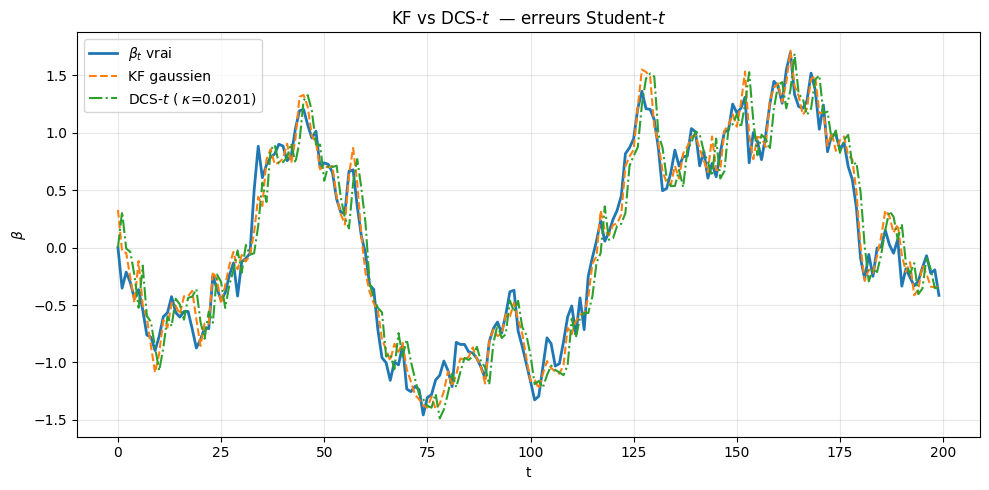

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_14848\1635316760.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mse_kf, mse_dcs], labels=["KF ", "DCS-t "], showmeans=True)


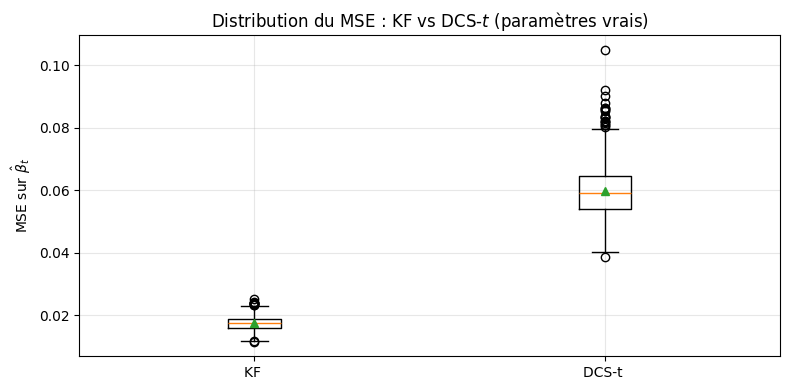

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# ---------- Simulation ----------
def simulate_panel_normal_with_outliers(T, N, Q_true, sigma_v2_true, nu,
                                          p_out=0.01, mult=20, seed=123):
    rng = np.random.default_rng(seed)
    seed_int = int(rng.integers(1, 1_000_000_000))

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))
    
    # inside simulate_panel_student_t_with_outliers
    
   
    eps = rng.normal(loc=0.0, scale=np.sqrt(sigma_v2_true), size=(T, N))
   

    Z = beta_true[:, None] + eps
    return beta_true, Z


# ---------- KF oracle (gaussien) ----------
def kf_oracle_panel(Z, Q_true, sigma_v2_true, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2_true + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2_true / denom

        beta_hat[t] = b
        P = P + Q_true

    return beta_hat

def dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=0.0):
  
    T, N = Z.shape
    # initialize
    b_prev = beta0         # represents beta_{t-1} at iteration t
    u_prev = 0.0           # u_{t-1}, start with 0
    beta_pred = np.zeros(T)
    beta_post = np.zeros(T)
    u = np.zeros(T)
    zeta = np.zeros(T)

    for t in range(T):
        # prior for time t
        beta_pred[t] = b_prev

        # apply state innovation from previous score: beta_t = beta_{t-1} + kappa * u_{t-1}
        beta_t = b_prev + kappa * u_prev
        beta_post[t] = beta_t

        # zeta_t = kappa * u_{t-1}
        zeta[t] = kappa * u_prev

        # compute residuals using beta_t (conformément aux eq. du papier)
        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        # omega_t and u_t per (20)-(21)
        omega = 1.0 + ee / (nu * sigma_v2_true)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2_true) * one_e
        u[t] = u_t

        # prepare for next iteration
        b_prev = beta_t
        u_prev = u_t

    return beta_pred, beta_post, u, zeta


def calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, beta0=0.0, kappa_init=0.01,
                         n_iter=100, burn_frac=0.2, var_floor=1e-8):
    """
    Calibre kappa pour sigma_xi^2 = kappa^2 Var(u_{t-1}).
    Utilise la signature mise à jour de dcs_t_filter_and_u.
    """
    T, _ = Z.shape
    burn = int(burn_frac * T)

    kappa = float(kappa_init)
    for _ in range(n_iter):
        # on récupère u via la nouvelle signature
        _, _, u, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa, beta0=beta0)
       

        # pour aligner zeta_t = kappa u_{t-1}, on prend u[:-1] après burn
        #if T - burn - 1 > 0:
        u_use = u[burn:-1]
        #else:
        #u_use = u[burn:]

        # centrage + variance (MLE)
        
        u_use = u_use - u_use.mean()
        var_u = float(np.mean(u_use**2))
       

        

        kappa_new = np.sqrt(Q_true / var_u)
        kappa = kappa_new

    return kappa




# ---------- Comparaison MC ----------
def compare_oracle_kf_vs_dcs_panel(T=300, N=60, MC=2000, Q_true=0.04, sigma_v2_true=1.0,
                                  nu=5, seed=123, burn_frac=0.2, plot_one=True):
    rng = np.random.default_rng(seed)
    burn = int(burn_frac * T)

    mse_kf, mse_dcs = [], []
    saved = None

    for _ in range(MC):
        beta_true, Z = simulate_panel_normal_with_outliers(
            T, N, Q_true, sigma_v2_true, nu, seed=int(rng.integers(1, 10_000_000))
        )
        
    
        beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)

        # kappa calibré "comme le prof"
                # kappa calibré "comme le prof"
        kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu, kappa_init=0.01, n_iter=10)
        
        # <-- déballage : on récupère le posterior DCS (beta_post)
        _, beta_dcs_post, _, zeta = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)
  
        mse_kf.append(np.mean((beta_kf[burn:] - beta_true[burn:])**2))
        mse_dcs.append(np.mean((beta_dcs_post[burn:] - beta_true[burn:])**2))

        if plot_one and saved is None:
            saved = (beta_true, beta_kf, beta_dcs_post, kappa)

    mse_kf = np.array(mse_kf)
    mse_dcs = np.array(mse_dcs)

    print(f"nu={nu}, T={T}, N={N}, MC={MC}")
    print(f"KF  mean MSE={mse_kf.mean():.6f}, std={mse_kf.std():.6f}")
    print(f"DCS mean MSE={mse_dcs.mean():.6f}, std={mse_dcs.std():.6f}")

    if saved is not None:
        beta_true, beta_kf, beta_dcs, kappa = saved
        plt.figure(figsize=(10,5))
        plt.plot(beta_true, lw=2, label=r"$\beta_t$ vrai")
        plt.plot(beta_kf, "--", label="KF gaussien ")
        plt.plot(beta_dcs, "-.", label=rf"DCS-$t$ ( $\kappa$={kappa:.4f})")
        plt.title("KF vs DCS-$t$  — erreurs Student-$t$")
        plt.xlabel("t"); plt.ylabel(r"$\beta$")
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.boxplot([mse_kf, mse_dcs], labels=["KF ", "DCS-t "], showmeans=True)
        plt.ylabel("MSE sur $\\hat\\beta_t$ ")
        plt.title("Distribution du MSE : KF vs DCS-$t$ (paramètres vrais)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return mse_kf, mse_dcs

# ---- RUN ----
if __name__ == "__main__":
    compare_oracle_kf_vs_dcs_panel(T=200, N=40, MC=2000, Q_true=0.04, sigma_v2_true=1, nu=5)

In [18]:
def sweep_nu_N_g(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=500):
    out = {}
    Q_true = 0.04
    sigma_v2_true = 1.0

    for N in N_list:
        for nu in nu_list:

            err_kf = []
            err_dcs = []

            for _ in range(MC):

                beta_true, Z = simulate_panel_normal_with_outliers(
                    T, N, Q_true, sigma_v2_true, nu, seed=None
                )

                beta_kf = kf_oracle_panel(Z, Q_true, sigma_v2_true)

                kappa = calibrate_kappa_prof(Z, Q_true, sigma_v2_true, nu,
                                             kappa_init=0.01, n_iter=10)

                _, beta_dcs_post, _, _ = dcs_t_filter_and_u(Z, sigma_v2_true, nu, kappa)

                burn = int(0.2*T)

                err_kf.extend(beta_kf[burn:] - beta_true[burn:])
                err_dcs.extend(beta_dcs_post[burn:] - beta_true[burn:])

            err_kf = np.array(err_kf)
            err_dcs = np.array(err_dcs)

            # ---- KF stats
            mse_kf = np.mean(err_kf**2)
            bias_kf = np.mean(err_kf)
            var_kf = np.var(err_kf)

            # ---- DCS stats
            mse_dcs = np.mean(err_dcs**2)
            bias_dcs = np.mean(err_dcs)
            var_dcs = np.var(err_dcs)

            out[(N,nu)] = (mse_kf, bias_kf, var_kf,
                           mse_dcs, bias_dcs, var_dcs)

            print(f"N={N}, nu={nu}")
            print(f"  KF  : MSE={mse_kf:.4f}  Bias={bias_kf:.4f}  Var={var_kf:.4f}")
            print(f"  DCS : MSE={mse_dcs:.4f}  Bias={bias_dcs:.4f}  Var={var_dcs:.4f}")
            print("-"*50)

    return out
sweep_nu_N_g(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100], T=200, MC=500)

N=5, nu=3
  KF  : MSE=0.0712  Bias=0.0022  Var=0.0712
  DCS : MSE=0.1235  Bias=0.0025  Var=0.1235
--------------------------------------------------
N=5, nu=5
  KF  : MSE=0.0725  Bias=-0.0015  Var=0.0725
  DCS : MSE=0.1199  Bias=-0.0033  Var=0.1199
--------------------------------------------------
N=5, nu=10
  KF  : MSE=0.0712  Bias=-0.0046  Var=0.0712
  DCS : MSE=0.1150  Bias=-0.0052  Var=0.1150
--------------------------------------------------
N=5, nu=20
  KF  : MSE=0.0720  Bias=0.0017  Var=0.0720
  DCS : MSE=0.1130  Bias=0.0030  Var=0.1130
--------------------------------------------------
N=5, nu=50
  KF  : MSE=0.0719  Bias=-0.0005  Var=0.0719
  DCS : MSE=0.1122  Bias=0.0001  Var=0.1122
--------------------------------------------------
N=20, nu=3
  KF  : MSE=0.0291  Bias=0.0005  Var=0.0291
  DCS : MSE=0.0746  Bias=0.0010  Var=0.0746
--------------------------------------------------
N=20, nu=5
  KF  : MSE=0.0289  Bias=0.0015  Var=0.0289
  DCS : MSE=0.0721  Bias=0.0018  Var=0.072

{(5, 3): (np.float64(0.07121584476425873),
  np.float64(0.002222430114213747),
  np.float64(0.07121090556864618),
  np.float64(0.12349316507390992),
  np.float64(0.00253776456958752),
  np.float64(0.12348672482489927)),
 (5, 5): (np.float64(0.07247238557645017),
  np.float64(-0.0015398004083373394),
  np.float64(0.07247001459115265),
  np.float64(0.11988135753863825),
  np.float64(-0.0033036673283682277),
  np.float64(0.11987044332082174)),
 (5, 10): (np.float64(0.07117829568863607),
  np.float64(-0.004582768830424915),
  np.float64(0.07115729391848295),
  np.float64(0.11501324216842546),
  np.float64(-0.005218399154150345),
  np.float64(0.11498601047869342)),
 (5, 20): (np.float64(0.07201487666835331),
  np.float64(0.0016958215421659353),
  np.float64(0.07201200085765044),
  np.float64(0.11302019429058173),
  np.float64(0.0029570983069772327),
  np.float64(0.11301144986018462)),
 (5, 50): (np.float64(0.07185831764071629),
  np.float64(-0.0005357202197957342),
  np.float64(0.0718580306

# sénario 2

In [19]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as student_t

# =========================================================
# 1) Simulation : RW gaussien + erreurs Student-t multivariées cohérentes
# =========================================================
def simulate_panel_student_t_coherent(T, N, Q_true, sigma_v2_true, nu_true, seed=123):
    """
    beta_t = beta_{t-1} + xi_t, xi_t ~ N(0, Q_true)
    v_t ~ t_nu(0, sigma_v2_true I_N) (Student-t multivariée elliptique)
    Z_t = beta_t + v_t
    """
    rng = np.random.default_rng(seed)

    beta_true = np.zeros(T)
    for t in range(1, T):
        beta_true[t] = beta_true[t-1] + rng.normal(0.0, np.sqrt(Q_true))

    Z = np.zeros((T, N))
    for t in range(T):
        g = rng.normal(0.0, 1.0, size=N)
        w = rng.chisquare(df=nu_true)
        v_t = np.sqrt(sigma_v2_true) * g / np.sqrt(w / nu_true)
        Z[t, :] = beta_true[t] + v_t

    return beta_true, Z


# =========================================================
# 2) KF gaussien : loglike + filtre + MLE
# =========================================================
def kf_loglike_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        logdetS = (N - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        b = b + P * one_e / (sigma_v2 + N * P)
        P = P * sigma_v2 / (sigma_v2 + N * P)
        P = P + Q

    return ll


def kf_filter_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2 + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2 / denom
        beta_hat[t] = b
        P = P + Q

    return beta_hat


def mle_kf_gauss(Z, beta0=0.0, P0=1e6, maxiter=300):
    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        ll = kf_loglike_panel_gauss(Z, Q, sv2, beta0=beta0, P0=P0)
        return -ll if np.isfinite(ll) else 1e20

    x0 = np.log([0.04, 1.0])
    bounds = [(np.log(1e-12), np.log(1e6)), (np.log(1e-12), np.log(1e6))]
    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": maxiter})

    Q_hat = float(np.exp(res.x[0]))
    sv2_hat = float(np.exp(res.x[1]))
    return Q_hat, sv2_hat, bool(res.success)


# =========================================================
# 3) DCS : filtre Student-t, mais estimation GAUSSIENNE
# =========================================================
def gaussian_logpdf_iid_scalar(e, sigma_v2):
    N = e.size
    ee = float(e @ e)
    return -0.5 * N * (np.log(2 * np.pi) + np.log(sigma_v2)) - 0.5 * ee / sigma_v2


def gaussian_dcs_loglike_panel_lag(Z, sigma_v2, kappa, nu_for_u, beta0=0.0, eps=1e-12):
    """
    Log-vraisemblance GAUSSIENNE pour DCS :
    - la densité des e_t est gaussienne
    - mais le score u_t garde la formule Student-t via nu_for_u
    """
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    if sigma_v2 <= eps or kappa <= 0.0 or nu_for_u <= 2.0:
        return -np.inf

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        e = Z[t] - beta_t

        ll_t = gaussian_logpdf_iid_scalar(e, sigma_v2)
        if not np.isfinite(ll_t):
            return -np.inf
        ll += ll_t

        ee = float(e @ e)
        omega = 1.0 + ee / (nu_for_u * sigma_v2)
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        one_e = e.sum()
        u_t = (1.0 / omega) * ((nu_for_u + N) / nu_for_u) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def mle_dcs_gauss_fast(Z, beta0=0.0, nu_for_u=5.0, maxiter=200):
    """
    Estime (sigma_v2, kappa) sous vraisemblance gaussienne,
    en gardant nu_for_u FIXE dans le score DCS.
    """
    sv2_init = max(1e-8, np.var(Z))
    kappa_init = 0.01
    x0 = np.array([np.log(sv2_init), np.log(kappa_init)])

    def obj(theta):
        sigma_v2 = np.exp(theta[0])
        kappa = np.exp(theta[1])
        ll = gaussian_dcs_loglike_panel_lag(Z, sigma_v2, kappa, nu_for_u, beta0=beta0)
        return -ll if np.isfinite(ll) else 1e20

    bounds = [(np.log(1e-12), np.log(1e6)), (np.log(1e-8), np.log(1.0))]

    try:
        res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": maxiter})
        sigma_v2_hat = float(np.exp(res.x[0]))
        kappa_hat = float(np.exp(res.x[1]))
        return sigma_v2_hat, kappa_hat, bool(res.success)
    except Exception:
        return sv2_init, kappa_init, False


def dcs_t_filter_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(T)

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = Z[t] - beta_t
        ee = float(e @ e)

        if sigma_v2 <= 0 or nu <= 2.0:
            u_t = 0.0
        else:
            omega = 1.0 + ee / (nu * sigma_v2)
            if omega <= 0 or not np.isfinite(omega):
                u_t = 0.0
            else:
                one_e = e.sum()
                u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


# =========================================================
# 4) Une simulation Monte Carlo
# =========================================================
def one_sim_run_gauss(seed_sim, T, N, Q_true, sigma_v2_true, nu_true,
                      burn_frac=0.2, maxiter_dcs=200):
    rng = np.random.default_rng(int(seed_sim))

    beta_true, Z = simulate_panel_student_t_coherent(
        T=T, N=N, Q_true=Q_true, sigma_v2_true=sigma_v2_true,
        nu_true=nu_true, seed=int(rng.integers(1, 1_000_000))
    )

    # ----- KF
    try:
        Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z, maxiter=300)
    except Exception:
        Q_hat, sv2_hat, ok_kf = Q_true, sigma_v2_true * nu_true / (nu_true - 2), False

    if not np.isfinite(Q_hat) or not np.isfinite(sv2_hat) or Q_hat <= 0 or sv2_hat <= 0:
        Q_hat, sv2_hat, ok_kf = Q_true, sigma_v2_true * nu_true / (nu_true - 2), False

    beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

    # ----- DCS estimé sous vraisemblance gaussienne
    sv2_dcs, kappa_hat, ok_dcs = mle_dcs_gauss_fast(
        Z, beta0=0.0, nu_for_u=nu_true, maxiter=maxiter_dcs
    )

    if not np.isfinite(sv2_dcs) or sv2_dcs <= 0:
        sv2_dcs, ok_dcs = sigma_v2_true, False
    if not np.isfinite(kappa_hat) or kappa_hat <= 0:
        kappa_hat, ok_dcs = 0.01, False

    beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_true)

    burn = int(burn_frac * T)
    if burn >= T:
        burn = int(0.2 * T)

    err_kf = beta_kf[burn:] - beta_true[burn:]
    err_dcs = beta_dcs[burn:] - beta_true[burn:]

    mse_kf = float(np.mean(err_kf**2))
    mse_dcs = float(np.mean(err_dcs**2))

    bias_kf = float(np.mean(err_kf))
    var_kf = float(np.mean((err_kf - bias_kf)**2))

    bias_dcs = float(np.mean(err_dcs))
    var_dcs = float(np.mean((err_dcs - bias_dcs)**2))

    return {
        "mse_kf": mse_kf,
        "mse_dcs": mse_dcs,
        "bias_kf": bias_kf,
        "var_kf": var_kf,
        "bias_dcs": bias_dcs,
        "var_dcs": var_dcs,
        "Q_hat": Q_hat,
        "sv2_hat": sv2_hat,
        "sv2_dcs": sv2_dcs,
        "kappa": kappa_hat,
        "nu_used": nu_true,
        "ok_kf": bool(ok_kf),
        "ok_dcs": bool(ok_dcs),
    }


# =========================================================
# 5) Sweep final cohérent
# =========================================================
def sweep_nu_N_estimated_gauss(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100],
                               T=200, MC=200, Q_true=0.04, sigma_v2_true=1.0,
                               maxiter_dcs=200, seed=12345):
    out = {}
    rng = np.random.default_rng(seed)

    for N in N_list:
        for nu in nu_list:
            results = []

            for _ in range(MC):
                seed_sim = int(rng.integers(1, 10_000_000))
                res = one_sim_run_gauss(
                    seed_sim=seed_sim,
                    T=T, N=N,
                    Q_true=Q_true,
                    sigma_v2_true=sigma_v2_true,
                    nu_true=nu,
                    burn_frac=0.2,
                    maxiter_dcs=maxiter_dcs
                )
                results.append(res)

            mse_kf_list = np.array([r["mse_kf"] for r in results])
            mse_dcs_list = np.array([r["mse_dcs"] for r in results])

            bias_kf_list = np.array([r["bias_kf"] for r in results])
            var_kf_list = np.array([r["var_kf"] for r in results])

            bias_dcs_list = np.array([r["bias_dcs"] for r in results])
            var_dcs_list = np.array([r["var_dcs"] for r in results])

            Q_hats = np.array([r["Q_hat"] for r in results])
            sv2_hats = np.array([r["sv2_hat"] for r in results])

            sv2_dcs_hats = np.array([r["sv2_dcs"] for r in results])
            kappa_hats = np.array([r["kappa"] for r in results])

            conv_kf = np.mean([r["ok_kf"] for r in results])
            conv_dcs = np.mean([r["ok_dcs"] for r in results])

            mse_kf_mean = float(np.mean(mse_kf_list))
            mse_dcs_mean = float(np.mean(mse_dcs_list))

            mean_var_kf = float(np.mean(var_kf_list))
            mean_bias_sq_kf = float(np.mean(bias_kf_list**2))

            mean_var_dcs = float(np.mean(var_dcs_list))
            mean_bias_sq_dcs = float(np.mean(bias_dcs_list**2))

            out[(N, nu)] = {
                "mse_kf_mean": mse_kf_mean,
                "mse_dcs_mean": mse_dcs_mean,
                "avg_Q_hat": float(np.mean(Q_hats)),
                "avg_sv2_hat": float(np.mean(sv2_hats)),
                "avg_sv2_dcs": float(np.mean(sv2_dcs_hats)),
                "avg_kappa": float(np.mean(kappa_hats)),
                "kf_bias_mean": float(np.mean(bias_kf_list)),
                "kf_var_mean": mean_var_kf,
                "kf_mean_bias_sq": mean_bias_sq_kf,
                "dcs_bias_mean": float(np.mean(bias_dcs_list)),
                "dcs_var_mean": mean_var_dcs,
                "dcs_mean_bias_sq": mean_bias_sq_dcs,
                "conv_kf_rate": conv_kf,
                "conv_dcs_rate": conv_dcs,
            }

            print(f"N={N}, nu={nu}")
            print(" KF: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                mse_kf_mean, mean_var_kf + mean_bias_sq_kf, mean_var_kf, mean_bias_sq_kf
            ))
            print(" DCS-gauss: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                mse_dcs_mean, mean_var_dcs + mean_bias_sq_dcs, mean_var_dcs, mean_bias_sq_dcs
            ))
            print(" params KF : Q_hat={:.6f}, sv2_hat={:.6f}".format(
                float(np.mean(Q_hats)), float(np.mean(sv2_hats))
            ))
            print(" params DCS : sv2_hat={:.6f}, kappa_hat={:.6f}, nu fixé={:.2f}".format(
                float(np.mean(sv2_dcs_hats)), float(np.mean(kappa_hats)), float(nu)
            ))
            print("-" * 60)

    return out


# RUN
sweep_nu_N_estimated_gauss(
    nu_list=[3,5,10,20,50],
    N_list=[5,20,40,60,100],
    T=200,
    MC=200,
    Q_true=0.04,
    sigma_v2_true=1.0,
    maxiter_dcs=200,
    seed=12345
)


N=5, nu=3
 KF: mse_mean=0.139677, mean_var+mean_bias_sq=0.139677 (mean_var=0.133471, mean_bias_sq=0.006206)
 DCS-gauss: mse_mean=0.667023, mean_var+mean_bias_sq=0.667023 (mean_var=0.368043, mean_bias_sq=0.298979)
 params KF : Q_hat=0.050742, sv2_hat=2.886044
 params DCS : sv2_hat=3.484423, kappa_hat=0.097113, nu fixé=3.00
------------------------------------------------------------
N=5, nu=5
 KF: mse_mean=0.098975, mean_var+mean_bias_sq=0.098975 (mean_var=0.095782, mean_bias_sq=0.003193)
 DCS-gauss: mse_mean=0.695424, mean_var+mean_bias_sq=0.695424 (mean_var=0.342340, mean_bias_sq=0.353083)
 params KF : Q_hat=0.042174, sv2_hat=1.672501
 params DCS : sv2_hat=2.341191, kappa_hat=0.064358, nu fixé=5.00
------------------------------------------------------------
N=5, nu=10
 KF: mse_mean=0.086232, mean_var+mean_bias_sq=0.086232 (mean_var=0.084030, mean_bias_sq=0.002202)
 DCS-gauss: mse_mean=1.136327, mean_var+mean_bias_sq=1.136327 (mean_var=0.476721, mean_bias_sq=0.659606)
 params KF : Q_h

{(5, 3): {'mse_kf_mean': 0.13967668452452459,
  'mse_dcs_mean': 0.6670227758950306,
  'avg_Q_hat': 0.050741934406846226,
  'avg_sv2_hat': 2.886044127900239,
  'avg_sv2_dcs': 3.484423293005824,
  'avg_kappa': 0.09711345912773896,
  'kf_bias_mean': 0.007834526930419165,
  'kf_var_mean': 0.13347073311374122,
  'kf_mean_bias_sq': 0.006205951410783397,
  'dcs_bias_mean': -0.02332414337156357,
  'dcs_var_mean': 0.36804333367914027,
  'dcs_mean_bias_sq': 0.2989794422158903,
  'conv_kf_rate': np.float64(1.0),
  'conv_dcs_rate': np.float64(1.0)},
 (5, 5): {'mse_kf_mean': 0.09897528518491243,
  'mse_dcs_mean': 0.6954235632049389,
  'avg_Q_hat': 0.04217430198505852,
  'avg_sv2_hat': 1.6725007116809871,
  'avg_sv2_dcs': 2.341191461694953,
  'avg_kappa': 0.06435840495640414,
  'kf_bias_mean': 0.00016124524876780843,
  'kf_var_mean': 0.09578245666948487,
  'kf_mean_bias_sq': 0.0031928285154275626,
  'dcs_bias_mean': 0.04728651300165133,
  'dcs_var_mean': 0.34234039527653803,
  'dcs_mean_bias_sq': 0.

# scénario 3: génerer panel dcst

In [5]:
from scipy.stats import t as student_t
import matplotlib.pyplot as plt

def simulate_panel_dcs(T, N,
                       sigma_v2=1.0,   # variance observation
                       nu=5.0,         # degrés de liberté si obs t
                       kappa=0.02,     # paramètre DCS (gain)
                       obs_dist='t',   # 't' or 'gauss' for observation noise
                       beta0=0.0,
                       seed=12345):

  

    rng = np.random.default_rng(seed)
    beta = np.zeros(T)
    u = np.zeros(T)

    beta_prev = float(beta0)
    u_prev = 0.0

    # scale pour student-t : Var = scale^2 * nu/(nu-2)
    if obs_dist == 't':
        scale = np.sqrt(sigma_v2 )
    else:
        scale = None

    for t in range(T):

        # 1) construire beta_t à partir des états précédents
        beta_t = beta_prev + kappa * u_prev

        

        beta[t] = beta_t

        # 2) simuler observations Z_t
        if obs_dist == 't':
            g=rng.normal(0.0, 1.0, size=N)
            w=rng.chisquare(nu, size=N)
            v = scale * g / np.sqrt(w / nu)
        else:
            v = rng.normal(0.0, np.sqrt(sigma_v2), size=N)

       
        Zt = beta_t + v

        # 3) calcul du score u_t
        e = Zt - beta_t
        one_e = e.sum()
        ee = float(e @ e)


        omega = 1.0 + ee / (nu * sigma_v2) 

        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e 

        u[t] = u_t

        # shift pour next iter
        beta_prev = beta_t
        u_prev = u_t

        # store Z
        if t == 0:
            Z = np.zeros((T, N))

        Z[t, :] = Zt

    return beta, Z, u

def simulate_panel_dcs_coherent(
    T, N,
    sigma_v2=1.0,
    nu=5.0,
    kappa=0.02,
    Q=0.0,
    obs_dist='t',
    beta0=0.0,
    seed=12345
):
    """
    Simulation STRICTEMENT cohérente avec :
      - dcs_t_filter_panel
      - dcs_t_loglike_panel_lag_safe

    Important :
      * sigma_v2 est le paramètre d'échelle de la Student-t
      * si obs_dist='t', on génère une Student-t multivariée elliptique
        cohérente avec la log-likelihood :
            v_t ~ t_nu(0, sigma_v2 I_N)
    """

    rng = np.random.default_rng(seed)

    beta = np.zeros(T)
    u = np.zeros(T)
    Z = np.zeros((T, N))

    b_prev = float(beta0)
    u_prev = 0.0

    for t in range(T):
        # 1) état latent : même convention lag que dans le filtre
        beta_t = b_prev + kappa * u_prev

        # bruit d'état optionnel
        if Q > 0:
            beta_t = beta_t + rng.normal(0.0, np.sqrt(Q))

        beta[t] = beta_t

        # 2) observations
        if obs_dist == 't':
            # Student-t multivariée elliptique cohérente avec la densité
            g = rng.normal(0.0, 1.0, size=N)
            w = rng.chisquare(df=nu)
            v_t = np.sqrt(sigma_v2) * g / np.sqrt(w / nu)
        else:
            v_t = rng.normal(0.0, np.sqrt(sigma_v2), size=N)

        Z_t = beta_t + v_t
        Z[t, :] = Z_t

        # 3) score EXACTEMENT identique à la version estimation/filtre
        e = Z_t - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        if obs_dist == 't':
            omega = 1.0 + ee / (nu * sigma_v2)
            u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e
        else:
            # score gaussien analogue
            u_t = (1.0 / sigma_v2) * one_e

        u[t] = u_t

        # 4) shift
        b_prev = beta_t
        u_prev = u_t

    return beta, Z, u

def kf_loglike_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    """
    Log-vraisemblance KF (innovations) pour :
      z_t = 1_N beta_t + v_t, v_t ~ N(0, sigma_v2 I_N)
      beta_t = beta_{t-1} + xi_t, xi_t ~ N(0, Q)
    Formules fermées (pas d'inversion).
    """
    T, N = Z.shape
    b, P = beta0, P0
    ll = 0.0
    const = -0.5 * N * np.log(2*np.pi)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        # S = sigma_v2 I + P 11'
        logdetS = (N - 1)*np.log(sigma_v2) + np.log(sigma_v2 + N*P)
        quad = (ee / sigma_v2) - (P / (sigma_v2*(sigma_v2 + N*P))) * (one_e**2)

        ll += const - 0.5*(logdetS + quad)

        # update
        b = b + P*one_e / (sigma_v2 + N*P)
        P = P * sigma_v2 / (sigma_v2 + N*P)
        # predict
        P = P + Q

    return ll

def kf_filter_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2 + N*P

        b = b + P*one_e / denom
        P = P * sigma_v2 / denom

        beta_hat[t] = b
        P = P + Q

    return beta_hat

def mle_kf_gauss(Z, beta0=0.0, P0=1e6):
    # optimise sur log(Q), log(sigma_v2)
    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        return -kf_loglike_panel_gauss(Z, Q, sv2, beta0=beta0, P0=P0)

    x0 = np.log([0.04, 1.0])
    res = minimize(obj, x0, method="L-BFGS-B")
    Q_hat = float(np.exp(res.x[0]))
    sv2_hat = float(np.exp(res.x[1]))
    return Q_hat, sv2_hat, res.success


# =========================================================
# 2) DCS-t (panel multivarié) : loglike + filtre + MLE(sigma_v2, kappa, nu)
#    Formules du prof (avec omega_t)
# =========================================================

def logpdf_multiv_t_iid(e, sigma_v2, nu):
    """
    Log densité Student-t multivariée (dimension N) avec matrice sigma_v2 I:
      f(e) = Gamma((nu+N)/2)/Gamma(nu/2) * (nu*pi*sigma_v2)^(-N/2) *
             (1 + (e'e)/(nu*sigma_v2))^(-(nu+N)/2)
    """
    N = e.size
    ee = float(e @ e)
    term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N) * np.log(1.0 + ee / (nu * sigma_v2))
    return term1 + term2 + term3

def dcs_t_filter_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    """
    DCS-t implementing beta_t = beta_{t-1} + kappa * u_{t-1},
    then compute u_t from e_t = Z_t - beta_t.
    Returns beta_post (beta_t after applying kappa*u_{t-1}).
    """
    T, N = Z.shape
    b_prev = beta0        # beta_{t-1}
    u_prev = 0.0          # u_{t-1}, initialize at 0
    beta_hat = np.zeros(T)

    for t in range(T):
        # 1) apply innovation from previous score
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        # 2) compute residuals and score for this period (will be used at t+1)
        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        # 3) shift for next iteration
        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def dcs_t_loglike_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    """
    Log-likelihood conditional for DCS-t following the lag convention:
      beta_t = beta_{t-1} + kappa * u_{t-1}
    and e_t = Z_t - beta_t is used in the t-density.
    """
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for t in range(T):
        # apply previous innovation
        beta_t = b_prev + kappa * u_prev

        # compute logpdf at e_t = Z_t - beta_t
        e = Z[t] - beta_t
        ll += logpdf_multiv_t_iid(e, sigma_v2=sigma_v2, nu=nu)

        # compute score u_t
        one_e = e.sum()
        ee = float(e @ e)
        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        # shift
        b_prev = beta_t
        u_prev = u_t

    return ll
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln

# ---------- utilitaires sûrs ----------
def safe_logpdf_multiv_t_iid(e, sigma_v2, nu, eps=1e-12):
    """Log-pdf multivariate t iid with sigma_v2 * I. Return -inf on invalid params."""
    if not np.isfinite(sigma_v2) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf
    N = e.size
    ee = float(e @ e)
    try:
        term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
        term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
        term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))
        val = term1 + term2 + term3
        return val if np.isfinite(val) else -np.inf
    except Exception:
        return -np.inf

def dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=0.0, eps=1e-12):
    """
    Log-likelihood conditional for lag DCS (beta_t = beta_{t-1} + kappa u_{t-1}),
    but with many guards returning -inf on invalid intermediate values.
    """
    if not (np.isfinite(sigma_v2) and np.isfinite(kappa) and np.isfinite(nu)):
        return -np.inf
    if sigma_v2 <= eps or nu <= 2.0 + 1e-8 or kappa < 0:
        return -np.inf

    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        e = Z[t] - beta_t
        ll_t = safe_logpdf_multiv_t_iid(e, sigma_v2, nu, eps=eps)
        if ll_t == -np.inf:
            return -np.inf
        ll += ll_t

        ee = float(e @ e)
        denom = (nu * sigma_v2)
        if denom <= 0:
            return -np.inf
        omega = 1.0 + ee / denom
        if (omega <= 0) or (not np.isfinite(omega)):
            return -np.inf
        one_e = e.sum()
        # score u_t
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


# ---------- fonction principale robuste ----------
def mle_dcs_t_multistart_safe(Z, beta0=0.0, n_starts=1, nu_init=5,rng_seed=123,
                              bounds_override=None, maxiter=200):
  
    T, N = Z.shape

    # Objective (neg loglike). Clip exponentials to avoid overflow in optimizer calls.
    def obj(theta):
        a = np.clip(theta[0], np.log(1e-12), np.log(1e12))
        b = np.clip(theta[1], np.log(1e-12), np.log(1e6))
        c = np.clip(theta[2], np.log(1e-6), np.log(1e6))
        sigma_v2 = float(np.exp(a))
        kappa = float(np.exp(b))
        nu = float(2.0 + np.exp(c))
        ll = dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=beta0)
        if not np.isfinite(ll):
            return 1e12
        return -ll

    # sensible bounds (on log-scale)
    if bounds_override is None:
        bounds = [
            (np.log(1e-8), np.log(50.0)),    # sigma_v2
            (np.log(1e-8), np.log(0.2)),     # kappa (cap to 0.2)
            (np.log(1e-3), np.log(70))    # nu-2
        ]
    else:
        bounds = bounds_override

    # data-driven initial guess
    
    nu0=float(nu_init )
    a0 = np.log(1)   # rough obs variance
    b0 = np.log(0.01)
    #c0 = np.log(max(3.5, nu0) - 2.0)
    c0 = np.log(nu0-2.0)
    x0_base = np.array([a0, b0, c0])

    # build multistart initial points (base + jittered)
    rng = np.random.default_rng(rng_seed)
    inits = [x0_base]
    for i in range(max(0, n_starts-1)):
        jitter = rng.normal(scale=0.35, size=3)
        inits.append(x0_base + jitter)

    best_fun = 1e20
    best_x = None
    best_res = None

    for x0 in inits[:n_starts]:
        try:
            res = minimize(obj, x0, method='L-BFGS-B', bounds=bounds, options={'maxiter': maxiter})
            if not np.isfinite(res.fun):
                continue
            if res.fun < best_fun:
                best_fun = res.fun
                best_x = res.x
                best_res = res
        except Exception:
            continue

    if best_x is None or best_res is None:
        # no successful start -> return conservative fallback values and ok=False
        sigma_v2_hat = float(np.clip(1, 1e-6, 10.0))
        kappa_hat = 0.01
        nu_hat = float(min(200.0, max(3.5, nu0)))
        return sigma_v2_hat, kappa_hat, nu_hat, False, None

    # reconstruct parameters and basic validation
    a_hat, b_hat, c_hat = best_x
    sigma_v2_hat = float(np.exp(np.clip(a_hat, np.log(1e-12), np.log(1e12))))
    kappa_hat = float(np.exp(np.clip(b_hat, np.log(1e-12), np.log(1e6))))
    nu_hat = float(2.0 + np.exp(np.clip(c_hat, np.log(1e-6), np.log(1e6))))

    # sanity checks: ensure feasible
    if not (np.isfinite(sigma_v2_hat) and sigma_v2_hat>0 and np.isfinite(kappa_hat) and np.isfinite(nu_hat) and nu_hat>2.0):
        return float(np.clip(1,1e-6,10.0)), 0.01, float(max(3.5,nu0)), False, best_res

    return sigma_v2_hat, kappa_hat, nu_hat, True, best_res

def sweep_nu_N_estimated_e(nu_list=[3,5,10,20,50], N_list=[5,20,40,60,100],
                              T=200, MC=500, Q_true=0.04, sigma_v2_true=1.0,
                              n_starts_dcs=1, seed=12345, burn_frac=0.2,
                              verbose=True):
  
    rng = np.random.default_rng(seed)
    out = {}

    for N in N_list:
        for nu in nu_list:
            # stockage par réplication
            mse_kf_list = []
            mse_dcs_list = []
            bias_kf_list = []
            bias_dcs_list = []
            var_kf_list = []
            var_dcs_list = []

            Q_hats = []
            sv2_hats = []
            sv2_dcs_hats = []
            kappa_hats = []
            nu_hats = []
            conv_kf = 0
            conv_dcs = 0

            # pour proportion DCS mieux que KF
            count_dcs_better = 0

            for sim in range(MC):
                seed_sim= int(rng.integers(1, 10_000_000))
                beta_true, Z, _ = simulate_panel_dcs_coherent(T, N,sigma_v2=sigma_v2_true,nu=nu,kappa=0.01,Q=0.0,obs_dist='t',beta0=0.0,seed=seed_sim)
                # --- KF: MLE + filtre
                Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
                if ok_kf:
                    conv_kf += 1
                else:
                    # fallback : utiliser vrais paramètres si l'optim échoue
                    Q_hat, sv2_hat = Q_true, sigma_v2_true

                Q_hats.append(Q_hat)
                sv2_hats.append(sv2_hat)

                beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

                # --- DCS: MLE + filtre (multistart)
                
                sv2_dcs, kappa_hat, nu_hat, ok_dcs, res =mle_dcs_t_multistart_safe(Z, n_starts=1, nu_init=nu,rng_seed=seed_sim)
                if ok_dcs:
                    conv_dcs += 1
                else:
                    # fallback to sensible defaults if estimation fails
                    sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu

                sv2_dcs_hats.append(sv2_dcs)
                kappa_hats.append(kappa_hat)
                nu_hats.append(nu_hat)

                beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

                # erreurs après burn
                burn = int(burn_frac * T)
                err_kf = beta_kf[burn:] - beta_true[burn:]
                err_dcs = beta_dcs[burn:] - beta_true[burn:]

                mse_i_kf = float(np.mean(err_kf**2))
                bias_i_kf = float(np.mean(err_kf))
                var_i_kf = float(np.mean((err_kf - bias_i_kf)**2))

                mse_i_dcs = float(np.mean(err_dcs**2))
                bias_i_dcs = float(np.mean(err_dcs))
                var_i_dcs = float(np.mean((err_dcs - bias_i_dcs)**2))

                mse_kf_list.append(mse_i_kf)
                bias_kf_list.append(bias_i_kf)
                var_kf_list.append(var_i_kf)

                mse_dcs_list.append(mse_i_dcs)
                bias_dcs_list.append(bias_i_dcs)
                var_dcs_list.append(var_i_dcs)

                if mse_i_dcs < mse_i_kf:
                    count_dcs_better += 1

            # agrégation des résultats
            mse_kf_mean = float(np.mean(mse_kf_list))
            mse_kf_std  = float(np.std(mse_kf_list, ddof=1))
            mean_var_kf = float(np.mean(var_kf_list))
            mean_bias_sq_kf = float(np.mean(np.array(bias_kf_list)**2))

            mse_dcs_mean = float(np.mean(mse_dcs_list))
            mse_dcs_std  = float(np.std(mse_dcs_list, ddof=1))
            mean_var_dcs = float(np.mean(var_dcs_list))
            mean_bias_sq_dcs = float(np.mean(np.array(bias_dcs_list)**2))

            prop_dcs_better = float(count_dcs_better / MC)

            # paramètres estimés : moyennes et biais
            avg_Q_hat = float(np.mean(Q_hats)) if len(Q_hats)>0 else np.nan
            avg_sv2_hat = float(np.mean(sv2_hats)) if len(sv2_hats)>0 else np.nan

            avg_sv2_dcs = float(np.mean(sv2_dcs_hats)) if len(sv2_dcs_hats)>0 else np.nan
            avg_kappa = float(np.mean(kappa_hats)) if len(kappa_hats)>0 else np.nan
            avg_nu_hat = float(np.mean(nu_hats)) if len(nu_hats)>0 else np.nan

            bias_Q = avg_Q_hat - Q_true
            bias_sv2_kf = avg_sv2_hat - sigma_v2_true
            bias_sv2_dcs = avg_sv2_dcs - sigma_v2_true
            bias_nu = avg_nu_hat - nu

            conv_kf_rate = conv_kf / MC
            conv_dcs_rate = conv_dcs / MC

            # save to output
            out[(N,nu)] = {
                'mse_kf_mean': mse_kf_mean, 'mse_kf_std': mse_kf_std,
                'mse_dcs_mean': mse_dcs_mean, 'mse_dcs_std': mse_dcs_std,
                'mean_var_kf': mean_var_kf, 'mean_bias_sq_kf': mean_bias_sq_kf,
                'mean_var_dcs': mean_var_dcs, 'mean_bias_sq_dcs': mean_bias_sq_dcs,
                'avg_Q_hat': avg_Q_hat, 'avg_sv2_hat': avg_sv2_hat,
                'avg_sv2_dcs': avg_sv2_dcs, 'avg_kappa_hat': avg_kappa, 'avg_nu_hat': avg_nu_hat,
                'bias_Q_hat': bias_Q, 'bias_sv2_kf': bias_sv2_kf,
                'bias_sv2_dcs': bias_sv2_dcs, 'bias_nu_hat': bias_nu,
                'conv_kf_rate': conv_kf_rate, 'conv_dcs_rate': conv_dcs_rate,
                'prop_dcs_better': prop_dcs_better,
                # also store raw arrays if you want to post-process outside
                'mse_kf_list': np.array(mse_kf_list),
                'mse_dcs_list': np.array(mse_dcs_list),
                'Q_hats': np.array(Q_hats),
                'sv2_hats': np.array(sv2_hats),
                'sv2_dcs_hats': np.array(sv2_dcs_hats),
                'kappa_hats': np.array(kappa_hats),
                'nu_hats': np.array(nu_hats)
            }

            # affichage lisible
            if verbose:
                print(f"N={N}, nu={nu}")
                print(" KF: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_kf_mean, mean_var_kf + mean_bias_sq_kf, mean_var_kf, mean_bias_sq_kf))
                print(" DCS: mse_mean={:.6f}, mean_var+mean_bias_sq={:.6f} (mean_var={:.6f}, mean_bias_sq={:.6f})".format(
                    mse_dcs_mean, mean_var_dcs + mean_bias_sq_dcs, mean_var_dcs, mean_bias_sq_dcs))
                print(" PARAMETERS ESTIMATION:")
                print(f" KF : Q_hat mean={avg_Q_hat:.6f} (bias={bias_Q:.6f}), sigma_v2_hat mean={avg_sv2_hat:.6f} (bias={bias_sv2_kf:.6f})")
                print(f" DCS: sigma_v2_hat mean={avg_sv2_dcs:.6f} (bias={bias_sv2_dcs:.6f}), kappa mean={avg_kappa:.6f}, nu_hat mean={avg_nu_hat:.6f} (bias={bias_nu:.6f})")
                print(f" conv_kf_rate={conv_kf_rate:.3f}, conv_dcs_rate={conv_dcs_rate:.3f}, prop_dcs_better={prop_dcs_better:.3f}")
                print("-"*70)

    return out


# =========================================================
# RUN
# =========================================================
if __name__ == "__main__":
    
  sweep_nu_N_estimated_e(nu_list=[50], N_list=[5,20], T=200, MC=500,
                         Q_true=0.04, sigma_v2_true=1.0,
                         )    



N=5, nu=50
 KF: mse_mean=0.001694, mean_var+mean_bias_sq=0.001694 (mean_var=0.001464, mean_bias_sq=0.000230)
 DCS: mse_mean=0.001402, mean_var+mean_bias_sq=0.001402 (mean_var=0.001148, mean_bias_sq=0.000254)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.000458 (bias=-0.039542), sigma_v2_hat mean=1.032136 (bias=0.032136)
 DCS: sigma_v2_hat mean=0.993217 (bias=-0.006783), kappa mean=0.008666, nu_hat mean=53.010412 (bias=3.010412)
 conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.758
----------------------------------------------------------------------
N=20, nu=50
 KF: mse_mean=0.001831, mean_var+mean_bias_sq=0.001831 (mean_var=0.001802, mean_bias_sq=0.000029)
 DCS: mse_mean=0.000284, mean_var+mean_bias_sq=0.000284 (mean_var=0.000267, mean_bias_sq=0.000017)
 PARAMETERS ESTIMATION:
 KF : Q_hat mean=0.001652 (bias=-0.038348), sigma_v2_hat mean=1.031292 (bias=0.031292)
 DCS: sigma_v2_hat mean=0.997499 (bias=-0.002501), kappa mean=0.009879, nu_hat mean=53.184882 (bias=3.184882)
 conv_

# scénario 4: une crise

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln


# =========================================================
# 1) Simulation cohérente : RW gaussien + Student-t elliptique
# + contamination en clusters temporels
# =========================================================
def simulate_panel_student_t_clusters(
    T, N, Q_true, sigma_v2_true, nu,
    p_start=0.02, duration=6, mult=20.0,
    beta0=0.0, seed=None
):
    """
    Génère :
      beta_t = beta_{t-1} + xi_t, xi_t ~ N(0,Q_true)
      v_t ~ t_nu(0, sigma_v2_true I_N) (Student-t multivariée elliptique)
      z_t = beta_t + v_t

    Puis applique des clusters temporels :
      sur certaines périodes consécutives, toutes les observations sont multipliées par 'mult'.

    Retourne :
      beta_true : (T,)
      Z : (T,N)
      crisis_indicator : (T,) indicateur des périodes contaminées
    """
    rng = np.random.default_rng(seed)

    # -------- état latent
    beta_true = np.zeros(T)
    beta_true[0] = beta0
    for t in range(1, T):
        beta_true[t] = beta_true[t - 1] + rng.normal(0.0, np.sqrt(Q_true))

    # -------- erreurs Student-t elliptiques cohérentes
    V = np.zeros((T, N))
    for t in range(T):
        g = rng.normal(0.0, 1.0, size=N)
        w = rng.chisquare(df=nu)
        V[t, :] = np.sqrt(sigma_v2_true) * g / np.sqrt(w / nu)

    # -------- contamination en clusters temporels
    V_cont = V.copy()
    crisis_indicator = np.zeros(T, dtype=int)

    t = 0
    while t < T:
        if rng.random() < p_start:
            end = min(T, t + duration)
            V_cont[t:end, :] *= mult
            crisis_indicator[t:end] = 1
            t = end
        else:
            t += 1

    # -------- observations
    Z = beta_true[:, None] + V_cont

    return beta_true, Z, crisis_indicator


# =========================================================
# 2) KF gaussien : loglike + filtre + MLE
# =========================================================
def kf_loglike_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    ll = 0.0
    const = -0.5 * N * np.log(2 * np.pi)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        ee = float(e @ e)

        logdetS = (N - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        b = b + P * one_e / (sigma_v2 + N * P)
        P = P * sigma_v2 / (sigma_v2 + N * P)
        P = P + Q

    return ll


def kf_filter_panel_gauss(Z, Q, sigma_v2, beta0=0.0, P0=1e6):
    T, N = Z.shape
    b, P = beta0, P0
    beta_hat = np.zeros(T)

    for t in range(T):
        e = Z[t] - b
        one_e = e.sum()
        denom = sigma_v2 + N * P

        b = b + P * one_e / denom
        P = P * sigma_v2 / denom
        beta_hat[t] = b
        P = P + Q

    return beta_hat


def mle_kf_gauss(Z, beta0=0.0, P0=1e6, maxiter=300):
    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        ll = kf_loglike_panel_gauss(Z, Q, sv2, beta0=beta0, P0=P0)
        return -ll if np.isfinite(ll) else 1e20

    x0 = np.log([0.04, 1.0])
    bounds = [(np.log(1e-12), np.log(1e6)), (np.log(1e-12), np.log(1e6))]
    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": maxiter})

    Q_hat = float(np.exp(res.x[0]))
    sv2_hat = float(np.exp(res.x[1]))
    return Q_hat, sv2_hat, bool(res.success)

# =========================================================
# 3) DCS-t : densité + filtre + loglike + MLE
# =========================================================
def logpdf_multiv_t_elliptical(e, sigma_v2, nu):
    """
    Log densité Student-t multivariée elliptique :
      e_t ~ t_nu(0, sigma_v2 I_N)
    """
    N = e.size
    ee = float(e @ e)

    term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))

    return term1 + term2 + term3


def dcs_t_filter_panel(Z, sigma_v2, kappa, nu, beta0=0.0):
    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(T)

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = Z[t] - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=1e-12):
    if not np.isfinite(sigma_v2) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf

    N = e.size
    ee = float(e @ e)

    try:
        term1 = gammaln((nu + N) / 2.0) - gammaln(nu / 2.0)
        term2 = -0.5 * N * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
        term3 = -0.5 * (nu + N) * np.log1p(ee / (nu * sigma_v2))
        val = term1 + term2 + term3
        return val if np.isfinite(val) else -np.inf
    except Exception:
        return -np.inf


def dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=0.0, eps=1e-12):
    if not (np.isfinite(sigma_v2) and np.isfinite(kappa) and np.isfinite(nu)):
        return -np.inf
    if sigma_v2 <= eps or nu <= 2.0 + 1e-8 or kappa < 0:
        return -np.inf

    T, N = Z.shape
    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for t in range(T):
        beta_t = b_prev + kappa * u_prev
        e = Z[t] - beta_t

        ll_t = safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=eps)
        if ll_t == -np.inf:
            return -np.inf
        ll += ll_t

        ee = float(e @ e)
        denom = nu * sigma_v2
        if denom <= 0:
            return -np.inf

        omega = 1.0 + ee / denom
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        one_e = e.sum()
        u_t = (1.0 / omega) * ((nu + N) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def mle_dcs_t_multistart_safe(
    Z, beta0=0.0, n_starts=5, nu_init=5, rng_seed=123,
    bounds_override=None, maxiter=300
):
    def obj(theta):
        a = np.clip(theta[0], np.log(1e-12), np.log(1e12))
        b = np.clip(theta[1], np.log(1e-12), np.log(1e6))
        c = np.clip(theta[2], np.log(1e-6), np.log(1e6))

        sigma_v2 = float(np.exp(a))
        kappa = float(np.exp(b))
        nu = float(2.0 + np.exp(c))

        ll = dcs_t_loglike_panel_lag_safe(Z, sigma_v2, kappa, nu, beta0=beta0)
        return -ll if np.isfinite(ll) else 1e12

    if bounds_override is None:
        bounds = [
            (np.log(1e-4), np.log(3)), # sigma_v2
            (np.log(1e-8), np.log(0.04)), # kappa
            (np.log(0.2), np.log(50)) # nu-2 => nu >= 2.2
        ]
    else:
        bounds = bounds_override

    nu0 = float(nu_init)
    a0 = np.log(1.0)
    b0 = np.log(0.01)
    c0 = np.log(max(nu0 - 2.0, 0.2))
    x0_base = np.array([a0, b0, c0])

    rng = np.random.default_rng(rng_seed)
    inits = [x0_base]
    for _ in range(max(0, n_starts - 1)):
        jitter = rng.normal(scale=0.25, size=3)
        inits.append(x0_base + jitter)

    best_fun = 1e20
    best_x = None
    best_res = None

    for x0 in inits:
        try:
            res = minimize(
                obj,
                x0,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": maxiter}
            )
            if np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_x = res.x
                best_res = res
        except Exception:
            continue

    if best_x is None or best_res is None:
        sigma_v2_hat = float(np.clip(np.var(Z), 1e-4, 10.0))
        kappa_hat = 0.01
        nu_hat = float(max(2.2, nu0))
        return sigma_v2_hat, kappa_hat, nu_hat, False, None

    a_hat, b_hat, c_hat = best_x
    sigma_v2_hat = float(np.exp(a_hat))
    kappa_hat = float(np.exp(b_hat))
    nu_hat = float(2.0 + np.exp(c_hat))

    if not (np.isfinite(sigma_v2_hat) and sigma_v2_hat > 0 and
            np.isfinite(kappa_hat) and kappa_hat > 0 and
            np.isfinite(nu_hat) and nu_hat > 2.0):
        sigma_v2_hat = float(np.clip(np.var(Z), 1e-4, 10.0))
        kappa_hat = 0.01
        nu_hat = float(max(2.2, nu0))
        return sigma_v2_hat, kappa_hat, nu_hat, False, best_res

    return sigma_v2_hat, kappa_hat, nu_hat, True, best_res


# =========================================================
# 4) Une réplication Monte Carlo
# =========================================================
def one_sim_run_clusters(
    seed_sim,
    T, N, Q_true, sigma_v2_true, nu_true,
    p_start=0.02, duration=6, mult=20.0,
    burn_frac=0.2, n_starts_dcs=3
):
    beta_true, Z, crisis_indicator = simulate_panel_student_t_clusters(
        T=T, N=N, Q_true=Q_true, sigma_v2_true=sigma_v2_true, nu=nu_true,
        p_start=p_start, duration=duration, mult=mult,
        beta0=0.0, seed=seed_sim
    )

    # ----- KF
    try:
        Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
    except Exception:
        Q_hat, sv2_hat, ok_kf = Q_true, sigma_v2_true * nu_true / (nu_true - 2), False

    if not np.isfinite(Q_hat) or not np.isfinite(sv2_hat) or Q_hat <= 0 or sv2_hat <= 0:
        Q_hat, sv2_hat, ok_kf = Q_true, sigma_v2_true * nu_true / (nu_true - 2), False

    beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

    # ----- DCS-t
    sv2_dcs, kappa_hat, nu_hat, ok_dcs, _ = mle_dcs_t_multistart_safe(
        Z, n_starts=n_starts_dcs, nu_init=nu_true, rng_seed=seed_sim
    )

    if not ok_dcs:
        sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu_true

    beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

    burn = int(burn_frac * T)
    if burn >= T:
        burn = int(0.2 * T)

    err_kf = beta_kf[burn:] - beta_true[burn:]
    err_dcs = beta_dcs[burn:] - beta_true[burn:]

    mse_kf = float(np.mean(err_kf**2))
    mse_dcs = float(np.mean(err_dcs**2))

    bias_kf = float(np.mean(err_kf))
    var_kf = float(np.mean((err_kf - bias_kf)**2))

    bias_dcs = float(np.mean(err_dcs))
    var_dcs = float(np.mean((err_dcs - bias_dcs)**2))

    return {
        "mse_kf": mse_kf,
        "mse_dcs": mse_dcs,
        "bias_kf": bias_kf,
        "var_kf": var_kf,
        "bias_dcs": bias_dcs,
        "var_dcs": var_dcs,
        "Q_hat": Q_hat,
        "sv2_hat": sv2_hat,
        "sv2_dcs": sv2_dcs,
        "kappa_hat": kappa_hat,
        "nu_hat": nu_hat,
        "ok_kf": bool(ok_kf),
        "ok_dcs": bool(ok_dcs),
        "crisis_share": float(np.mean(crisis_indicator))
    }


# =========================================================
# 5) Sweep
# =========================================================
def sweep_nu_N_clusters(
    nu_list=[3, 5, 10, 20, 50],
    N_list=[ 60, 100,5, 20, 40,],
    T=200,
    MC=200,
    Q_true=0.04,
    sigma_v2_true=1.0,
    p_start=0.02,
    duration=6,
    mult=20.0,
    burn_frac=0.2,
    n_starts_dcs=3,
    seed=12345
):
    out = {}
    rng = np.random.default_rng(seed)

    for N in N_list:
        for nu in nu_list:
            results = []

            for _ in range(MC):
                seed_sim = int(rng.integers(1, 10_000_000))
                res = one_sim_run_clusters(
                    seed_sim=seed_sim,
                    T=T, N=N,
                    Q_true=Q_true,
                    sigma_v2_true=sigma_v2_true,
                    nu_true=nu,
                    p_start=p_start,
                    duration=duration,
                    mult=mult,
                    burn_frac=burn_frac,
                    n_starts_dcs=n_starts_dcs
                )
                results.append(res)

            mse_kf = np.array([r["mse_kf"] for r in results])
            mse_dcs = np.array([r["mse_dcs"] for r in results])

            bias_kf = np.array([r["bias_kf"] for r in results])
            bias_dcs = np.array([r["bias_dcs"] for r in results])

            var_kf = np.array([r["var_kf"] for r in results])
            var_dcs = np.array([r["var_dcs"] for r in results])

            Q_hats = np.array([r["Q_hat"] for r in results])
            sv2_hats = np.array([r["sv2_hat"] for r in results])

            sv2_dcs_hats = np.array([r["sv2_dcs"] for r in results])
            kappa_hats = np.array([r["kappa_hat"] for r in results])
            nu_hats = np.array([r["nu_hat"] for r in results])

            conv_kf = np.mean([r["ok_kf"] for r in results])
            conv_dcs = np.mean([r["ok_dcs"] for r in results])
            crisis_share = np.mean([r["crisis_share"] for r in results])

            out[(N, nu)] = {
                "mse_kf_mean": float(np.mean(mse_kf)),
                "mse_dcs_mean": float(np.mean(mse_dcs)),
                "kf_bias_mean": float(np.mean(bias_kf)),
                "dcs_bias_mean": float(np.mean(bias_dcs)),
                "kf_var_mean": float(np.mean(var_kf)),
                "dcs_var_mean": float(np.mean(var_dcs)),
                "avg_Q_hat": float(np.mean(Q_hats)),
                "avg_sv2_hat": float(np.mean(sv2_hats)),
                "avg_sv2_dcs": float(np.mean(sv2_dcs_hats)),
                "avg_kappa_hat": float(np.mean(kappa_hats)),
                "avg_nu_hat": float(np.mean(nu_hats)),
                "conv_kf_rate": float(conv_kf),
                "conv_dcs_rate": float(conv_dcs),
                "avg_crisis_share": float(crisis_share),
            }

            print(f"N={N}, nu={nu}")
            print(f" KF : MSE={np.mean(mse_kf):.6f}, Bias={np.mean(bias_kf):.6f}, Var={np.mean(var_kf):.6f}")
            print(f" DCS : MSE={np.mean(mse_dcs):.6f}, Bias={np.mean(bias_dcs):.6f}, Var={np.mean(var_dcs):.6f}")
            print(f" KF params : Q_hat={np.mean(Q_hats):.6f}, sv2_hat={np.mean(sv2_hats):.6f}")
            print(f" DCS params : sv2_hat={np.mean(sv2_dcs_hats):.6f}, kappa_hat={np.mean(kappa_hats):.6f}, nu_hat={np.mean(nu_hats):.6f}")
            print(f" crisis share ≈ {crisis_share:.3f}")
            print("-" * 70)

    return out 

sweep_nu_N_clusters(
    nu_list=[3, 5, 10, 20, 50],
    N_list=[ 5, 20, 40,60, 100],
    T=200,
    MC=200,
    Q_true=0.04,
    sigma_v2_true=1.0,
    p_start=0.02,
    duration=6,
    mult=20.0,
    burn_frac=0.2,
    n_starts_dcs=1,
    seed=12345
)


N=5, nu=3
 KF : MSE=3.156918, Bias=0.041887, Var=2.916432
 DCS : MSE=0.253950, Bias=0.027056, Var=0.223896
 KF params : Q_hat=1.894638, sv2_hat=121.820716
 DCS params : sv2_hat=1.245373, kappa_hat=0.039977, nu_hat=2.259156
 crisis share ≈ 0.110
----------------------------------------------------------------------
N=5, nu=5
 KF : MSE=1.190804, Bias=0.007800, Var=1.028968
 DCS : MSE=0.227163, Bias=-0.002557, Var=0.202341
 KF params : Q_hat=0.384762, sv2_hat=72.562291
 DCS params : sv2_hat=1.141802, kappa_hat=0.039915, nu_hat=2.324676
 crisis share ≈ 0.108
----------------------------------------------------------------------
N=5, nu=10
 KF : MSE=1.107879, Bias=0.052147, Var=0.969346
 DCS : MSE=0.221846, Bias=0.007638, Var=0.193478
 KF params : Q_hat=0.357711, sv2_hat=56.435276
 DCS params : sv2_hat=1.067379, kappa_hat=0.039895, nu_hat=2.549073
 crisis share ≈ 0.110
----------------------------------------------------------------------
N=5, nu=20
 KF : MSE=0.926824, Bias=0.016914, Var=0.

{(5, 3): {'mse_kf_mean': 3.1569175320931913,
  'mse_dcs_mean': 0.25394982860129195,
  'kf_bias_mean': 0.041887278838281326,
  'dcs_bias_mean': 0.027056257191583707,
  'kf_var_mean': 2.916431995983822,
  'dcs_var_mean': 0.22389640721082443,
  'avg_Q_hat': 1.8946378865297344,
  'avg_sv2_hat': 121.82071628316466,
  'avg_sv2_dcs': 1.2453731342413321,
  'avg_kappa_hat': 0.03997734110588375,
  'avg_nu_hat': 2.2591562869868973,
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'avg_crisis_share': 0.10980000000000001},
 (5, 5): {'mse_kf_mean': 1.1908035621116413,
  'mse_dcs_mean': 0.22716291387875479,
  'kf_bias_mean': 0.007800075719089746,
  'dcs_bias_mean': -0.0025572524648763474,
  'kf_var_mean': 1.0289675261937352,
  'dcs_var_mean': 0.20234112943842908,
  'avg_Q_hat': 0.3847616527350505,
  'avg_sv2_hat': 72.56229063189349,
  'avg_sv2_dcs': 1.1418020826693258,
  'avg_kappa_hat': 0.039914634102328296,
  'avg_nu_hat': 2.32467597676086,
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'avg_cris

L=25
  KF  : MSE=0.489544  Bias=0.009933  Var=0.489445
  DCS : MSE=0.254701  Bias=0.020445  Var=0.254283
  conv_kf_rate=0.998, conv_dcs_rate=1.000, prop_dcs_better=0.852
------------------------------------------------------------
L=30
  KF  : MSE=0.525483  Bias=-0.015077  Var=0.525256
  DCS : MSE=0.294952  Bias=0.002167  Var=0.294947
  conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.792
------------------------------------------------------------
L=40
  KF  : MSE=0.570975  Bias=0.003832  Var=0.570960
  DCS : MSE=0.444052  Bias=0.009365  Var=0.443964
  conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.682
------------------------------------------------------------


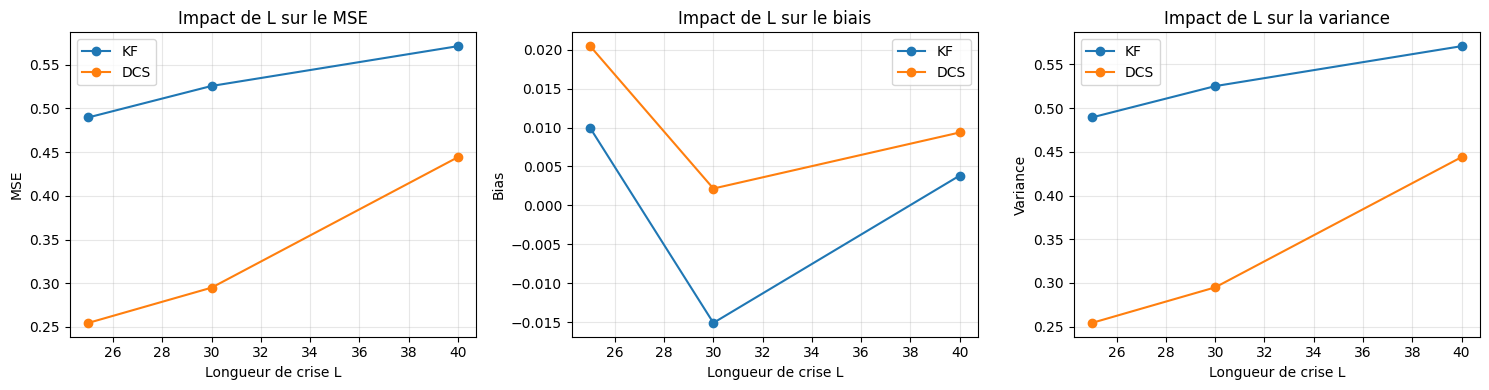

{25: {'mse_kf': np.float64(0.48954408848653064),
  'bias_kf': np.float64(0.00993313069933626),
  'var_kf': np.float64(0.4894454214010406),
  'mse_dcs': np.float64(0.2547011607919381),
  'bias_dcs': np.float64(0.020444587246053584),
  'var_dcs': np.float64(0.2542831796442766),
  'conv_kf_rate': 0.998,
  'conv_dcs_rate': 1.0,
  'prop_dcs_better': 0.852},
 30: {'mse_kf': np.float64(0.5254832842599689),
  'bias_kf': np.float64(-0.015076859468197538),
  'var_kf': np.float64(0.5252559725685451),
  'mse_dcs': np.float64(0.2949515467046086),
  'bias_dcs': np.float64(0.0021670737332495802),
  'var_dcs': np.float64(0.2949468504960433),
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'prop_dcs_better': 0.792},
 40: {'mse_kf': np.float64(0.5709746566893413),
  'bias_kf': np.float64(0.003831863282013049),
  'var_kf': np.float64(0.5709599735131292),
  'mse_dcs': np.float64(0.44405165428922794),
  'bias_dcs': np.float64(0.009364756309667639),
  'var_dcs': np.float64(0.44396395562848845),
  'conv_kf_

In [29]:
def sweep_duration_L(L_list=[1, 2, 4, 6, 10, 15, 20],
                     T=200, N=40, MC=500,
                     Q_true=0.04, sigma_v2_true=1.0, nu=5,
                     p_start=0.02, mult=20.0,
                     burn_frac=0.2, seed=12345,
                     plot=True):

    rng = np.random.default_rng(seed)
    out = {}

    for L in L_list:
        err_kf_all = []
        err_dcs_all = []

        conv_kf = 0
        conv_dcs = 0
        count_dcs_better = 0

        for _ in range(MC):
            seed_sim = int(rng.integers(1, 10_000_000))

            # ---- simulation avec clusters de crise ----
            beta_true, Z, crisis_indicator = simulate_panel_student_t_clusters(
               T=T, N=N, Q_true=Q_true, sigma_v2_true=sigma_v2_true, nu=nu,
               p_start=p_start, duration=L, mult=mult, beta0=0.0, seed=seed_sim)

            # ---- KF : MLE + filtre ----
            Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
            if ok_kf:
                conv_kf += 1
            else:
                Q_hat, sv2_hat = Q_true, sigma_v2_true

            beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

            # ---- DCS : MLE + filtre ----
            sv2_dcs, kappa_hat, nu_hat, ok_dcs, res = mle_dcs_t_multistart_safe(
                Z, n_starts=1, nu_init=nu, rng_seed=123
            )
            if ok_dcs:
                conv_dcs += 1
            else:
                sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu

            beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

            burn = int(burn_frac * T)

            err_kf = beta_kf[burn:] - beta_true[burn:]
            err_dcs = beta_dcs[burn:] - beta_true[burn:]

            # ---- stocker toutes les erreurs ----
            err_kf_all.extend(err_kf)
            err_dcs_all.extend(err_dcs)

            # ---- comparer run par run ----
            mse_kf_i = np.mean(err_kf**2)
            mse_dcs_i = np.mean(err_dcs**2)
            if mse_dcs_i < mse_kf_i:
                count_dcs_better += 1

        err_kf_all = np.array(err_kf_all)
        err_dcs_all = np.array(err_dcs_all)

        mse_kf = np.mean(err_kf_all**2)
        bias_kf = np.mean(err_kf_all)
        var_kf = np.var(err_kf_all)

        mse_dcs = np.mean(err_dcs_all**2)
        bias_dcs = np.mean(err_dcs_all)
        var_dcs = np.var(err_dcs_all)

        out[L] = {
            "mse_kf": mse_kf,
            "bias_kf": bias_kf,
            "var_kf": var_kf,
            "mse_dcs": mse_dcs,
            "bias_dcs": bias_dcs,
            "var_dcs": var_dcs,
            "conv_kf_rate": conv_kf / MC,
            "conv_dcs_rate": conv_dcs / MC,
            "prop_dcs_better": count_dcs_better / MC
        }

        print(f"L={L}")
        print(f"  KF  : MSE={mse_kf:.6f}  Bias={bias_kf:.6f}  Var={var_kf:.6f}")
        print(f"  DCS : MSE={mse_dcs:.6f}  Bias={bias_dcs:.6f}  Var={var_dcs:.6f}")
        print(f"  conv_kf_rate={conv_kf/MC:.3f}, conv_dcs_rate={conv_dcs/MC:.3f}, prop_dcs_better={count_dcs_better/MC:.3f}")
        print("-"*60)

    if plot:
        L_vals = list(out.keys())

        mse_kf_vals = [out[L]["mse_kf"] for L in L_vals]
        mse_dcs_vals = [out[L]["mse_dcs"] for L in L_vals]

        bias_kf_vals = [out[L]["bias_kf"] for L in L_vals]
        bias_dcs_vals = [out[L]["bias_dcs"] for L in L_vals]

        var_kf_vals = [out[L]["var_kf"] for L in L_vals]
        var_dcs_vals = [out[L]["var_dcs"] for L in L_vals]

        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.plot(L_vals, mse_kf_vals, marker="o", label="KF")
        plt.plot(L_vals, mse_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Longueur de crise L")
        plt.ylabel("MSE")
        plt.title("Impact de L sur le MSE")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(L_vals, bias_kf_vals, marker="o", label="KF")
        plt.plot(L_vals, bias_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Longueur de crise L")
        plt.ylabel("Bias")
        plt.title("Impact de L sur le biais")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(L_vals, var_kf_vals, marker="o", label="KF")
        plt.plot(L_vals, var_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Longueur de crise L")
        plt.ylabel("Variance")
        plt.title("Impact de L sur la variance")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.tight_layout()
        plt.show()

    return out

sweep_duration_L(L_list=[25,30,40],
                     T=200, N=40, MC=500,
                     Q_true=0.04, sigma_v2_true=1.0, nu=5,
                     p_start=0.02, mult=20.0,
                     burn_frac=0.2, seed=12345,
                     plot=True)

m=5
  KF  : MSE=0.078165  Bias=0.001836  Var=0.078162
  DCS : MSE=0.098569  Bias=0.002204  Var=0.098564
  conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.240
------------------------------------------------------------
m=10
  KF  : MSE=0.184792  Bias=-0.006145  Var=0.184754
  DCS : MSE=0.105480  Bias=-0.000023  Var=0.105480
  conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.770
------------------------------------------------------------
m=20
  KF  : MSE=0.369992  Bias=-0.007825  Var=0.369931
  DCS : MSE=0.111067  Bias=0.000268  Var=0.111067
  conv_kf_rate=0.998, conv_dcs_rate=1.000, prop_dcs_better=0.960
------------------------------------------------------------
m=30
  KF  : MSE=0.614587  Bias=0.001265  Var=0.614586
  DCS : MSE=0.112356  Bias=0.002264  Var=0.112351
  conv_kf_rate=1.000, conv_dcs_rate=1.000, prop_dcs_better=0.984
------------------------------------------------------------
m=40
  KF  : MSE=0.887354  Bias=0.017108  Var=0.887062
  DCS : MSE=0.11482

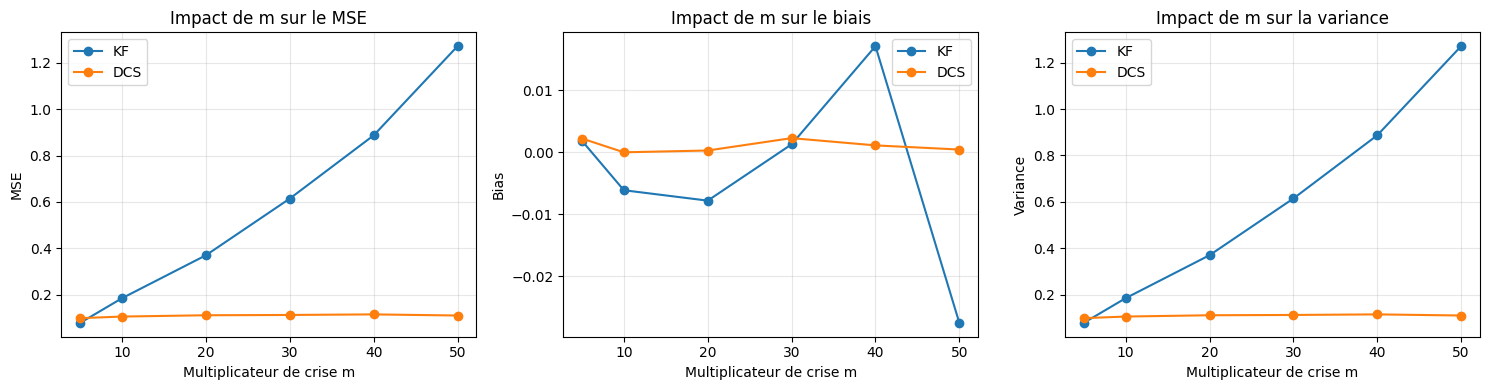

{5: {'mse_kf': np.float64(0.07816509445700402),
  'bias_kf': np.float64(0.0018364973678748832),
  'var_kf': np.float64(0.07816172173442182),
  'mse_dcs': np.float64(0.0985685611786522),
  'bias_dcs': np.float64(0.002203581135700815),
  'var_dcs': np.float64(0.09856370540883058),
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'prop_dcs_better': 0.24},
 10: {'mse_kf': np.float64(0.18479200308316204),
  'bias_kf': np.float64(-0.00614530905824769),
  'var_kf': np.float64(0.18475423825974066),
  'mse_dcs': np.float64(0.10548035612912587),
  'bias_dcs': np.float64(-2.3483191207033017e-05),
  'var_dcs': np.float64(0.10548035557766561),
  'conv_kf_rate': 1.0,
  'conv_dcs_rate': 1.0,
  'prop_dcs_better': 0.77},
 20: {'mse_kf': np.float64(0.3699921020798105),
  'bias_kf': np.float64(-0.007824812269619612),
  'var_kf': np.float64(0.3699308743927557),
  'mse_dcs': np.float64(0.11106720928856982),
  'bias_dcs': np.float64(0.0002675231508856164),
  'var_dcs': np.float64(0.11106713771993357),
  'co

In [31]:

def sweep_mult_m(mult_list=[1, 2, 5, 10, 15, 20, 30, 40],
                 T=200, N=40, MC=500,
                 Q_true=0.04, sigma_v2_true=1.0, nu=5,
                 p_start=0.02, L=6,
                 burn_frac=0.2, seed=12345,
                 plot=True):

    rng = np.random.default_rng(seed)
    out = {}

    for m in mult_list:
        err_kf_all = []
        err_dcs_all = []

        conv_kf = 0
        conv_dcs = 0
        count_dcs_better = 0

        for _ in range(MC):
            seed_sim = int(rng.integers(1, 10_000_000))

            # ---- simulation avec clusters de crise ----
            beta_true, Z, crisis_indicator = simulate_panel_student_t_clusters(T=T, N=N, Q_true=Q_true, sigma_v2_true=sigma_v2_true, nu=nu,
               p_start=p_start, duration=L, mult=m, beta0=0.0, seed=seed_sim)
            # ---- KF : MLE + filtre ----
            Q_hat, sv2_hat, ok_kf = mle_kf_gauss(Z)
            if ok_kf:
                conv_kf += 1
            else:
                Q_hat, sv2_hat = Q_true, sigma_v2_true

            beta_kf = kf_filter_panel_gauss(Z, Q_hat, sv2_hat)

            # ---- DCS : MLE + filtre ----
            sv2_dcs, kappa_hat, nu_hat, ok_dcs, res = mle_dcs_t_multistart_safe(
                Z, n_starts=1, nu_init=nu, rng_seed=123
            )
            if ok_dcs:
                conv_dcs += 1
            else:
                sv2_dcs, kappa_hat, nu_hat = sigma_v2_true, 0.01, nu

            beta_dcs = dcs_t_filter_panel(Z, sv2_dcs, kappa_hat, nu_hat)

            burn = int(burn_frac * T)

            err_kf = beta_kf[burn:] - beta_true[burn:]
            err_dcs = beta_dcs[burn:] - beta_true[burn:]

            err_kf_all.extend(err_kf)
            err_dcs_all.extend(err_dcs)

            mse_kf_i = np.mean(err_kf**2)
            mse_dcs_i = np.mean(err_dcs**2)
            if mse_dcs_i < mse_kf_i:
                count_dcs_better += 1

        err_kf_all = np.array(err_kf_all)
        err_dcs_all = np.array(err_dcs_all)

        mse_kf = np.mean(err_kf_all**2)
        bias_kf = np.mean(err_kf_all)
        var_kf = np.var(err_kf_all)

        mse_dcs = np.mean(err_dcs_all**2)
        bias_dcs = np.mean(err_dcs_all)
        var_dcs = np.var(err_dcs_all)

        out[m] = {
            "mse_kf": mse_kf,
            "bias_kf": bias_kf,
            "var_kf": var_kf,
            "mse_dcs": mse_dcs,
            "bias_dcs": bias_dcs,
            "var_dcs": var_dcs,
            "conv_kf_rate": conv_kf / MC,
            "conv_dcs_rate": conv_dcs / MC,
            "prop_dcs_better": count_dcs_better / MC
        }

        print(f"m={m}")
        print(f"  KF  : MSE={mse_kf:.6f}  Bias={bias_kf:.6f}  Var={var_kf:.6f}")
        print(f"  DCS : MSE={mse_dcs:.6f}  Bias={bias_dcs:.6f}  Var={var_dcs:.6f}")
        print(f"  conv_kf_rate={conv_kf/MC:.3f}, conv_dcs_rate={conv_dcs/MC:.3f}, prop_dcs_better={count_dcs_better/MC:.3f}")
        print("-"*60)

    if plot:
        m_vals = list(out.keys())

        mse_kf_vals = [out[m]["mse_kf"] for m in m_vals]
        mse_dcs_vals = [out[m]["mse_dcs"] for m in m_vals]

        bias_kf_vals = [out[m]["bias_kf"] for m in m_vals]
        bias_dcs_vals = [out[m]["bias_dcs"] for m in m_vals]

        var_kf_vals = [out[m]["var_kf"] for m in m_vals]
        var_dcs_vals = [out[m]["var_dcs"] for m in m_vals]

        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.plot(m_vals, mse_kf_vals, marker="o", label="KF")
        plt.plot(m_vals, mse_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Multiplicateur de crise m")
        plt.ylabel("MSE")
        plt.title("Impact de m sur le MSE")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(m_vals, bias_kf_vals, marker="o", label="KF")
        plt.plot(m_vals, bias_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Multiplicateur de crise m")
        plt.ylabel("Bias")
        plt.title("Impact de m sur le biais")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(m_vals, var_kf_vals, marker="o", label="KF")
        plt.plot(m_vals, var_dcs_vals, marker="o", label="DCS")
        plt.xlabel("Multiplicateur de crise m")
        plt.ylabel("Variance")
        plt.title("Impact de m sur la variance")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.tight_layout()
        plt.show()

    return out
sweep_mult_m(
     mult_list=[ 5, 10,  20, 30, 40, 50],
     T=200, N=40, MC=500,
     Q_true=0.04, sigma_v2_true=1.0, nu=5,
     p_start=0.02, L=10,
     burn_frac=0.2, seed=12345,
     plot=True
)

# application

In [ ]:
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "openpyxl"])
import pandas as pd
import numpy as np
import sys
import subprocess
import matplotlib.pyplot as plt


# =========================
# 1) LOAD DATA
# =========================
df = pd.read_excel(r"C:\\Users\\ReMarkt\\Downloads\wine.xlsx")

print("Aperçu des données :")
print(df.head())

print("\nDimensions :", df.shape)

print("\nColonnes :")
print(df.columns)


# =========================
# 3) STATISTIQUES DESCRIPTIVES
# =========================
print("\nStatistiques sur le rating :")
print(df['rating'].describe())

# =========================
# 4) DISTRIBUTION DES RATINGS
# =========================
plt.hist(df['rating'], bins=30)
plt.title("Distribution des ratings")
plt.xlabel("Rating")
plt.ylabel("Fréquence")
plt.show()

# =========================
# 5) NOMBRE DE VINS ET ANNÉES
# =========================
n_wines = df['chateau'].nunique()
n_years = df['year'].nunique()

print("\nNombre de vins :", n_wines)
print("Nombre d'années :", n_years)

# =========================
# 6) OBSERVATIONS PAR ANNÉE
# =========================
obs_per_year = df.groupby('year').size()

plt.plot(obs_per_year.index, obs_per_year.values)
plt.title("Nombre d'observations par année")
plt.xlabel("Year")
plt.ylabel("Nombre de vins")
plt.show()

# =========================
# 7) PANEL STRUCTURE
# =========================
panel = df.pivot_table(index='year', columns='chateau', values='rating')

print("\nTaille du panel brut :", panel.shape)

# taux de données manquantes
missing_rate = panel.isna().mean().mean()
print("Taux de valeurs manquantes :", missing_rate)

# =========================
# 8) PANEL ÉQUILIBRÉ
# =========================
panel_clean = panel.dropna(axis=1).dropna(axis=0)

print("\nTaille du panel équilibré :", panel_clean.shape)

T, N = panel_clean.shape
print("T (années) =", T)
print("N (vins) =", N)

# =========================
# 9) MOYENNE PAR ANNÉE
# =========================
mean_rating = panel.mean(axis=1)

plt.plot(mean_rating.index, mean_rating.values)
plt.title("Rating moyen par année")
plt.xlabel("Year")
plt.ylabel("Rating moyen")
plt.show()

# =========================
# 10) VARIABILITÉ
# =========================
std_rating = panel.std(axis=1)

plt.plot(std_rating.index, std_rating.values)
plt.title("Volatilité des ratings par année")
plt.xlabel("Year")
plt.ylabel("Écart-type")
plt.show()


ModuleNotFoundError: No module named 'pandas'

1    860
Name: count, dtype: int64
count    860.000000
mean       8.545233
std        2.979941
min        2.990000
25%        6.280000
50%        7.990000
75%       10.492500
max       16.290000
Name: prix, dtype: float64
count    860.000000
mean       2.083272
std        0.357919
min        1.095273
25%        1.837366
50%        2.078191
75%        2.350661
max        2.790551
Name: log_price, dtype: float64


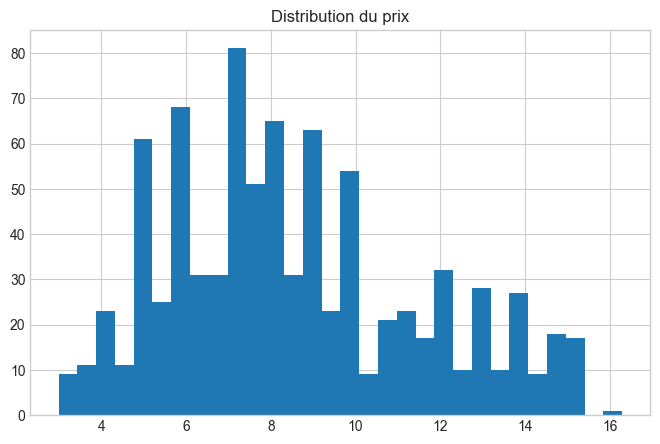

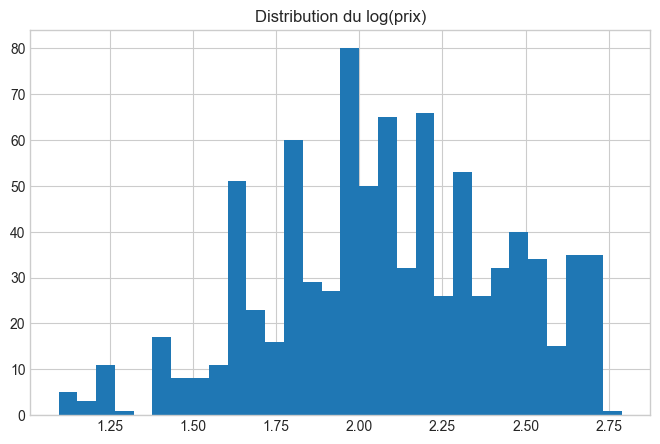

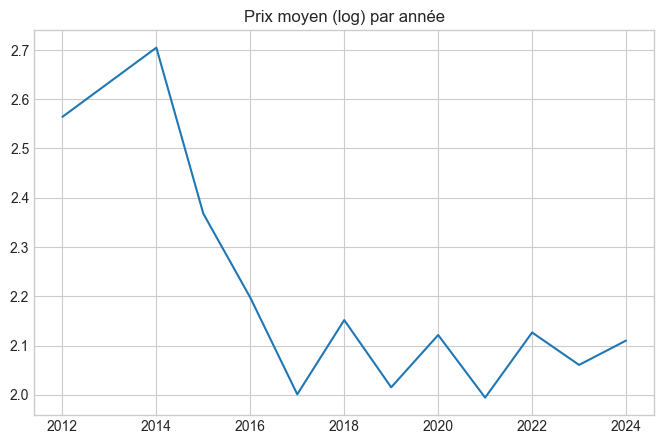

In [12]:
# =========================
# ANALYSE PRIX
# =========================

df['log_price'] = np.log(df['prix'])
print(df[[
    "plein charpenté", "souple et rond", "riche et puissant",
    "léger et fruité", "sec et épicé"
]].sum(axis=1).value_counts())
print(df['prix'].describe())
print(df['log_price'].describe())

# distribution prix
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8,5))
plt.hist(df['prix'], bins=30)
plt.title("Distribution du prix")
plt.show()

# distribution log prix
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8,5))
plt.hist(df['log_price'], bins=30)
plt.title("Distribution du log(prix)")
plt.show()

# moyenne par année
mean_price = df.groupby('year')['log_price'].mean()
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8,5))
plt.plot(mean_price.index, mean_price.values)
plt.title("Prix moyen (log) par année")
plt.show()


In [19]:
print(df.columns)
summary = []
qual_vars = [
    "bio",
    "plein charpenté",
    "souple et rond",
    "riche et puissant",
    "léger et fruité",
    "sec et épicé",'Bordeaux', 'Loire', 'Rhone',
       'Languedoc', 'Bourgogne', 'Alsace'
]
for col in qual_vars:
    counts = df[col].value_counts()
    perc = df[col].value_counts(normalize=True) * 100

    summary.append({
        "Variable": col,
        "Nombre (1)": counts.get(1, 0),
        "Pourcentage (1)": round(perc.get(1, 0), 2)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)
summary_df.to_latex(
    index=False,
    caption="Fréquences des variables qualitatives",
    label="tab:qual"
)






Index(['chateau', 'rating', 'white', 'red', 'Bordeaux', 'Loire', 'Rhone',
       'Languedoc', 'Bourgogne', 'Alsace', 'year', 'prix', 'alcool', 'sucres',
       'acidité', 'volatile', 'sorbique', 'SO2 libre', 'SO2 total',
       'plein charpenté', 'souple et rond', 'riche et puissant',
       'léger et fruité', 'sec et épicé', 'bio', 'number', 'log_price',
       'log_prix'],
      dtype='object')
             Variable  Nombre (1)  Pourcentage (1)
0                 bio         119            13.84
1     plein charpenté         363            42.21
2      souple et rond         183            21.28
3   riche et puissant          58             6.74
4     léger et fruité         244            28.37
5        sec et épicé          12             1.40
6            Bordeaux         206            23.95
7               Loire          74             8.60
8               Rhone         176            20.47
9           Languedoc         176            20.47
10          Bourgogne         148      

'\\begin{table}\n\\caption{Fréquences des variables qualitatives}\n\\label{tab:qual}\n\\begin{tabular}{lrr}\n\\toprule\nVariable & Nombre (1) & Pourcentage (1) \\\\\n\\midrule\nbio & 119 & 13.840000 \\\\\nplein charpenté & 363 & 42.210000 \\\\\nsouple et rond & 183 & 21.280000 \\\\\nriche et puissant & 58 & 6.740000 \\\\\nléger et fruité & 244 & 28.370000 \\\\\nsec et épicé & 12 & 1.400000 \\\\\nBordeaux & 206 & 23.950000 \\\\\nLoire & 74 & 8.600000 \\\\\nRhone & 176 & 20.470000 \\\\\nLanguedoc & 176 & 20.470000 \\\\\nBourgogne & 148 & 17.210000 \\\\\nAlsace & 80 & 9.300000 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.special import gammaln


FILEPATH = r"C:\Users\ReMarkt\Downloads\wine.xlsx"

PRICE_COL = "prix"
YEAR_COL = "year"
ID_COL = "chateau"

HEDONIC_VARS = [
    "rating", "red",
     "Loire", "Rhone", "Languedoc", "Bourgogne", "Alsace",
    "alcool", "sucres", "acidité", "volatile", "sorbique",
    "SO2 libre", "SO2 total",
    "souple et rond", "riche et puissant",
    "léger et fruité", "sec et épicé", "bio"
]

MAXITER_KF = 300
MAXITER_DCS = 300


def load_wine_data(filepath: str) -> pd.DataFrame:
    return pd.read_excel(filepath)


def prepare_hedonic_dataset(df, price_col, year_col, id_col, hedonic_vars):
    needed_cols = [id_col, year_col, price_col] + hedonic_vars
    missing = [c for c in needed_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")

    out = df[needed_cols].copy().dropna()
    out = out[out[price_col] > 0].copy()
    out["log_price"] = np.log(out[price_col].astype(float))

    for c in hedonic_vars:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna()
    out[year_col] = out[year_col].astype(int)
    return out


def fit_hedonic_model(df, hedonic_vars):
    X = sm.add_constant(df[hedonic_vars], has_constant="add")
    y = df["log_price"].astype(float)
    return sm.OLS(y, X).fit()


def add_hedonic_residuals(df, hedonic_model, hedonic_vars):
    X = sm.add_constant(df[hedonic_vars], has_constant="add")
    out = df.copy()
    out["hedonic_fitted"] = hedonic_model.predict(X)
    out["z"] = out["log_price"] - out["hedonic_fitted"]
    return out


# =========================================================
# Panel non équilibré : liste de vecteurs z_t
# =========================================================
def build_unbalanced_panel(df, year_col="year", value_col="z"):
    tmp = df[[year_col, value_col]].copy().dropna()
    tmp[year_col] = tmp[year_col].astype(int)
    tmp = tmp.sort_values(year_col)

    years = np.array(sorted(tmp[year_col].unique()))
    Z_list = []
    Nt_list = []

    for y in years:
        z_t = tmp.loc[tmp[year_col] == y, value_col].to_numpy(dtype=float)
        z_t = z_t[np.isfinite(z_t)]
        if len(z_t) > 0:
            Z_list.append(z_t)
            Nt_list.append(len(z_t))

    years = np.array([y for y, z in zip(years, Z_list)])
    Nt_list = np.array(Nt_list)

    print("==================================================")
    print("PANEL NON ÉQUILIBRÉ")
    print("==================================================")
    print(f"Nombre d'années T = {len(years)}")
    print("Nombre d'observations par année :")
    for y, nt in zip(years, Nt_list):
        print(f" {y}: {nt}")
    print("==================================================")

    return Z_list, years, Nt_list

def init_kf_params(Z_list):
    """
    Initialise les paramètres du filtre de Kalman :
        Q_init : variance d'état initiale
        sigma_v2_init: variance d'observation initiale
        beta0 : état initial
        P0 : variance initiale de l'état
    """
    z_all = np.concatenate(Z_list)

    sigma_v2_init = max(np.var(z_all), 1e-6)

    # moyenne par année pour approximer la dynamique de beta_t
    mean_by_year = np.array([np.mean(z_t) for z_t in Z_list])

    if len(mean_by_year) >= 2:
        Q_init = max(np.var(np.diff(mean_by_year)), 1e-6)
    else:
        Q_init = 0.01

    beta0 = float(mean_by_year[0]) if len(mean_by_year) > 0 else 0.0
    P0 = 10

    return {
        "Q_init": Q_init,
        "sigma_v2_init": sigma_v2_init,
        "beta0": beta0,
        "P0": P0
    }


# =========================================================
# Initialisation DCS-t
# =========================================================
def init_dcs_params(Z_list, nu_init=5.0):
    """
    Initialise les paramètres du modèle DCS-t :
        sigma_v2_init : scale initial
        kappa_init : coefficient d'ajustement initial
        nu_init : ddl initiaux
        beta0 : état initial
    """
    z_all = np.concatenate(Z_list)

    sigma_v2_init = max(np.var(z_all), 1e-6)

    mean_by_year = np.array([np.mean(z_t) for z_t in Z_list])
    beta0 = float(mean_by_year[0]) if len(mean_by_year) > 0 else 0.0

    # petite valeur au départ pour stabilité
    kappa_init = 0.005

    return {
        "sigma_v2_init": sigma_v2_init,
        "kappa_init": kappa_init,
        "nu_init": nu_init,
        "beta0": beta0
    }


# =========================================================
# KF avec N_t variable
# =========================================================
def kf_loglike_panel_gauss_unbalanced(Z_list, Q, sigma_v2, beta0=0.0, P0=10):
    b, P = beta0, P0
    ll = 0.0

    for z_t in Z_list:
        N_t = len(z_t)
        e = z_t - b
        one_e = e.sum()
        ee = float(e @ e)

        const = -0.5 * N_t * np.log(2 * np.pi)
        logdetS = (N_t - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N_t * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N_t * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        b = b + P * one_e / (sigma_v2 + N_t * P)
        P = P * sigma_v2 / (sigma_v2 + N_t * P)
        P = P + Q

    return ll


def kf_filter_panel_gauss_unbalanced(Z_list, Q, sigma_v2, beta0=0.0, P0=1e6):
    b, P = beta0, P0
    beta_hat = np.zeros(len(Z_list))

    for t, z_t in enumerate(Z_list):
        N_t = len(z_t)
        e = z_t - b
        one_e = e.sum()

        denom = sigma_v2 + N_t * P
        b = b + P * one_e / denom
        P = P * sigma_v2 / denom

        beta_hat[t] = b
        P = P + Q

    return beta_hat


def mle_kf_gauss_unbalanced(Z_list, beta0=None, P0=None, maxiter=300):
    init = init_kf_params(Z_list)

    if beta0 is None:
        beta0 = init["beta0"]
    if P0 is None:
        P0 = init["P0"]

    Q_init = init["Q_init"]
    sigma_v2_init = init["sigma_v2_init"]

    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        ll = kf_loglike_panel_gauss_unbalanced(Z_list, Q, sv2, beta0=beta0, P0=P0)
        return -ll if np.isfinite(ll) else 1e20

    x0 = np.log([Q_init, sigma_v2_init])
    bounds = [
        (np.log(1e-12), np.log(1e6)),
        (np.log(1e-12), np.log(1e6))
    ]

    res = minimize(
        obj,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter}
    )

    Q_hat = float(np.exp(res.x[0]))
    sigma_v2_hat = float(np.exp(res.x[1]))

    return Q_hat, sigma_v2_hat, bool(res.success), res

# =========================================================
# DCS-t avec N_t variable
# =========================================================
def safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=1e-12):
    if (not np.isfinite(sigma_v2)) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf

    N_t = e.size
    ee = float(e @ e)

    term1 = gammaln((nu + N_t) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N_t * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N_t) * np.log1p(ee / (nu * sigma_v2))
    val = term1 + term2 + term3
    return val if np.isfinite(val) else -np.inf


def dcs_t_loglike_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=0.0):
    if sigma_v2 <= 0 or kappa < 0 or nu <= 2:
        return -np.inf

    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for z_t in Z_list:
        N_t = len(z_t)
        beta_t = b_prev + kappa * u_prev
        e = z_t - beta_t

        ll_t = safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu)
        if not np.isfinite(ll_t):
            return -np.inf
        ll += ll_t

        one_e = e.sum()
        ee = float(e @ e)
        omega = 1.0 + ee / (nu * sigma_v2)
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        u_t = (1.0 / omega) * ((nu + N_t) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def dcs_t_filter_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=0.0):
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(len(Z_list))

    for t, z_t in enumerate(Z_list):
        N_t = len(z_t)
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = z_t - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N_t) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def mle_dcs_t_unbalanced_multistart(Z_list, beta0=None, nu_init=5.0, n_starts=10, maxiter=500, seed=123):
    rng = np.random.default_rng(seed)

    init = init_dcs_params(Z_list, nu_init=nu_init)

    
    beta0 = init["beta0"]

    sigma_v2_init = init["sigma_v2_init"]
    kappa_init = init["kappa_init"]
    nu_init = init["nu_init"]

    def obj(theta):
        sigma_v2 = np.exp(theta[0])
        kappa = np.exp(theta[1])
        nu = 2.0 + np.exp(theta[2])

        ll = dcs_t_loglike_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=beta0)
        return -ll if np.isfinite(ll) else 1e12

    bounds = [
        (np.log(1e-3), np.log(5.0)), # sigma_v2
        (np.log(1e-6), np.log(0.2)), # kappa
        (np.log(1e-3), np.log(200.0)) # nu - 2
    ]

    base = np.array([
        np.log(sigma_v2_init),
        np.log(kappa_init),
        np.log(max(nu_init - 2.0, 1e-3))
    ])

    starts = [base]
    for _ in range(n_starts - 1):
        jitter = rng.normal(scale=[0.5, 1.0, 0.8], size=3)
        starts.append(base + jitter)

    best_res = None
    best_fun = np.inf

    for x0 in starts:
        try:
            res = minimize(
                obj,
                x0,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": maxiter}
            )
            if np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_res = res
        except Exception:
            pass

    if best_res is None:
        return np.nan, np.nan, np.nan, False, None

    sigma_v2_hat = float(np.exp(best_res.x[0]))
    kappa_hat = float(np.exp(best_res.x[1]))
    nu_hat = float(2.0 + np.exp(best_res.x[2]))

    return sigma_v2_hat, kappa_hat, nu_hat, bool(best_res.success), best_res


# =========================================================
# Pipeline
# =========================================================
def run_full_wine_pipeline_clean(filepath):
    raw = load_wine_data(filepath)
    print("Dimensions brutes :", raw.shape)

    df = prepare_hedonic_dataset(raw, PRICE_COL, YEAR_COL, ID_COL, HEDONIC_VARS)
    print("Dimensions après nettoyage :", df.shape)

    hedonic_model = fit_hedonic_model(df, HEDONIC_VARS)
    print(hedonic_model.summary())

    df = add_hedonic_residuals(df, hedonic_model, HEDONIC_VARS)

    Z_list, years, Nt_list = build_unbalanced_panel(df, year_col=YEAR_COL, value_col="z")
    print("initialisation kf params :", init_kf_params(Z_list))
    print("initialisation dcs params :", init_dcs_params(Z_list, nu_init=5.0))    
    Q_hat, sv2_hat_kf, ok_kf, _ = mle_kf_gauss_unbalanced(Z_list, maxiter=MAXITER_KF)
    beta_kf = kf_filter_panel_gauss_unbalanced(Z_list, Q_hat, sv2_hat_kf)
    beta0=np.mean(Z_list[0]) 
    sv2_hat_dcs, kappa_hat, nu_hat, ok_dcs, _ = mle_dcs_t_unbalanced_multistart(Z_list, beta0=beta0, maxiter=MAXITER_DCS)
    beta_dcs = dcs_t_filter_panel_unbalanced(Z_list, sv2_hat_dcs, kappa_hat, nu_hat, beta0=beta0)

    return {
        "clean_df": df,
        "years": years,
        "Nt_list": Nt_list,
        "kf": {
            "Q_hat": Q_hat,
            "sigma_v2_hat": sv2_hat_kf,
            "beta_hat": beta_kf,
            "success": ok_kf
        },
        "dcs": {
            "sigma_v2_hat": sv2_hat_dcs,
            "kappa_hat": kappa_hat,
            "nu_hat": nu_hat,
            "beta_hat": beta_dcs,
            "success": ok_dcs
        }
    }


def plot_factors(results):
    years = results["years"]
    beta_kf = results["kf"]["beta_hat"]
    beta_dcs = results["dcs"]["beta_hat"]

    plt.figure(figsize=(10, 5))
    plt.plot(years, beta_kf, marker="o", label="Kalman")
    plt.plot(years, beta_dcs, marker="s", label="DCS-t")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Année")
    plt.ylabel(r"$\hat{\beta}_t$")
    plt.title("Facteur latent estimé")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    results_clean = run_full_wine_pipeline_clean(FILEPATH)
    print(results_clean["kf"])
    print(results_clean["dcs"])
    plot_factors(results_clean)

ModuleNotFoundError: No module named 'pandas'

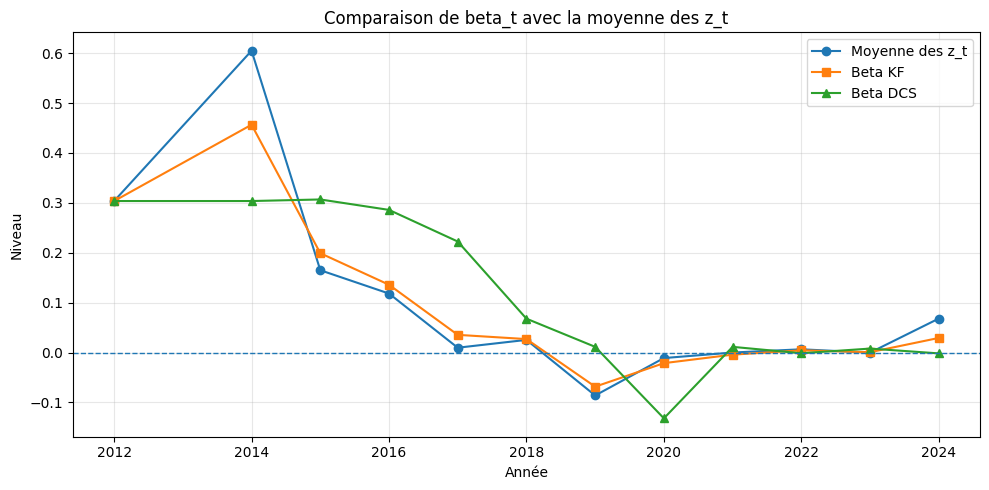

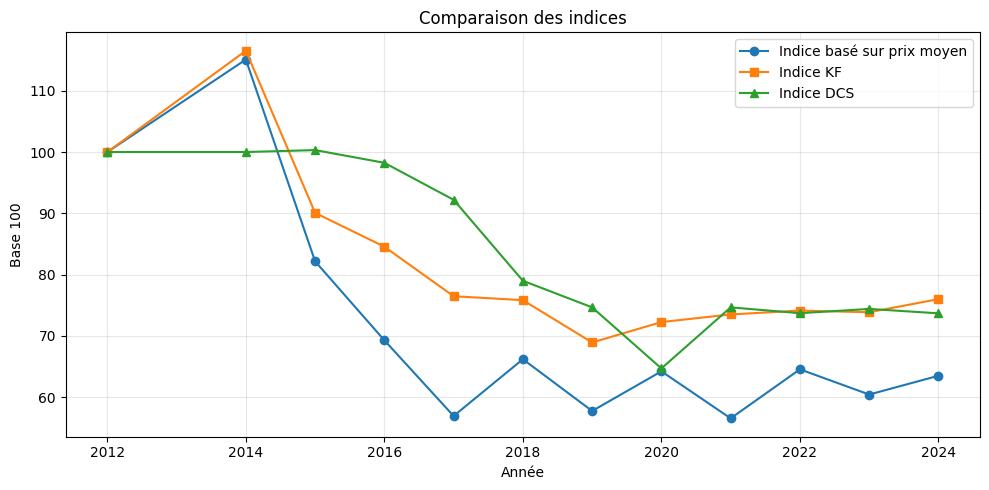

In [19]:
def compare_beta_to_mean_residual(results):
    df = results["clean_df"].copy()
    years = results["years"]
    beta_kf = results["kf"]["beta_hat"]
    beta_dcs = results["dcs"]["beta_hat"]

    mean_z = df.groupby("year")["z"].mean().reindex(years)

    plt.figure(figsize=(10, 5))
    plt.plot(years, mean_z.values, marker="o", label="Moyenne des z_t")
    plt.plot(years, beta_kf, marker="s", label="Beta KF")
    plt.plot(years, beta_dcs, marker="^", label="Beta DCS")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Année")
    plt.ylabel("Niveau")
    plt.title("Comparaison de beta_t avec la moyenne des z_t")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def build_price_index(beta_hat):
    return 100 * np.exp(beta_hat - beta_hat[0])
def compare_index_to_mean_price(results):
    df = results["clean_df"].copy()
    years = results["years"]

    beta_kf = results["kf"]["beta_hat"]
    beta_dcs = results["dcs"]["beta_hat"]

    index_kf = 100 * np.exp(beta_kf - beta_kf[0])
    index_dcs = 100 * np.exp(beta_dcs - beta_dcs[0])

    mean_log_price = df.groupby("year")["log_price"].mean().reindex(years)
    mean_price_index = 100 * np.exp(mean_log_price - mean_log_price.iloc[0])

    plt.figure(figsize=(10, 5))
    plt.plot(years, mean_price_index.values, marker="o", label="Indice basé sur prix moyen")
    plt.plot(years, index_kf, marker="s", label="Indice KF")
    plt.plot(years, index_dcs, marker="^", label="Indice DCS")
    plt.xlabel("Année")
    plt.ylabel("Base 100")
    plt.title("Comparaison des indices")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_beta_to_mean_residual(results_clean)
compare_index_to_mean_price(results_clean)

Dimensions brutes : (860, 26)
Dimensions après nettoyage : (860, 23)

RÉSULTATS MODÈLE HÉDONIQUE
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     22.22
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           9.25e-62
Time:                        18:56:08   Log-Likelihood:                -161.09
No. Observations:                 860   AIC:                             362.2
Df Residuals:                     840   BIC:                             457.3
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

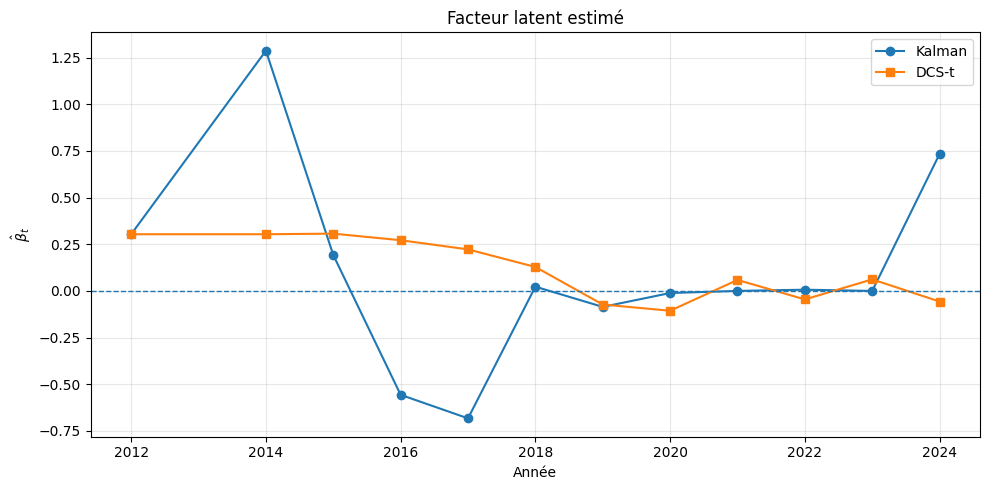

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.special import gammaln


# =========================================================
# PARAMÈTRES GÉNÉRAUX
# =========================================================
FILEPATH = r"C:\Users\ReMarkt\Downloads\wine.xlsx"

PRICE_COL = "prix"
YEAR_COL = "year"
ID_COL = "chateau"

HEDONIC_VARS = [
    "rating", "red",
    "Loire", "Rhone", "Languedoc", "Bourgogne", "Alsace",
    "alcool", "sucres", "acidité", "volatile", "sorbique",
    "SO2 libre", "SO2 total",
    "souple et rond", "riche et puissant",
    "léger et fruité", "sec et épicé", "bio"
]

MAXITER_KF = 300
MAXITER_DCS = 300


# =========================================================
# 1) CHARGEMENT ET PRÉPARATION DES DONNÉES
# =========================================================
def load_wine_data(filepath: str) -> pd.DataFrame:
    return pd.read_excel(filepath)


def prepare_hedonic_dataset(df, price_col, year_col, id_col, hedonic_vars):
    needed_cols = [id_col, year_col, price_col] + hedonic_vars
    missing = [c for c in needed_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes manquantes : {missing}")

    out = df[needed_cols].copy().dropna()
    out = out[out[price_col] > 0].copy()
    out["log_price"] = np.log(out[price_col].astype(float))

    for c in hedonic_vars:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna()
    out[year_col] = out[year_col].astype(int)
    return out


# =========================================================
# 2) MODÈLE HÉDONIQUE
# =========================================================
def fit_hedonic_model(df, hedonic_vars):
    X = sm.add_constant(df[hedonic_vars], has_constant="add")
    y = df["log_price"].astype(float)
    return sm.OLS(y, X).fit()


def add_hedonic_residuals(df, hedonic_model, hedonic_vars):
    X = sm.add_constant(df[hedonic_vars], has_constant="add")
    out = df.copy()
    out["hedonic_fitted"] = hedonic_model.predict(X)
    out["z"] = out["log_price"] - out["hedonic_fitted"]
    return out


# =========================================================
# 3) PANEL NON ÉQUILIBRÉ
# =========================================================
def build_unbalanced_panel(df, year_col="year", value_col="z"):
    tmp = df[[year_col, value_col]].copy().dropna()
    tmp[year_col] = tmp[year_col].astype(int)
    tmp = tmp.sort_values(year_col)

    years = np.array(sorted(tmp[year_col].unique()))
    Z_list = []
    Nt_list = []

    for y in years:
        z_t = tmp.loc[tmp[year_col] == y, value_col].to_numpy(dtype=float)
        z_t = z_t[np.isfinite(z_t)]
        if len(z_t) > 0:
            Z_list.append(z_t)
            Nt_list.append(len(z_t))

    years = np.array([y for y, z in zip(years, Z_list)])
    Nt_list = np.array(Nt_list)

    print("==================================================")
    print("PANEL NON ÉQUILIBRÉ")
    print("==================================================")
    print(f"Nombre d'années T = {len(years)}")
    print("Nombre d'observations par année :")
    for y, nt in zip(years, Nt_list):
        print(f" {y}: {nt}")
    print("==================================================")

    return Z_list, years, Nt_list


# =========================================================
# 4) INITIALISATION DES PARAMÈTRES
# =========================================================
def init_kf_params(Z_list):
    """
    Initialise les paramètres du filtre de Kalman :
      Q_init, sigma_v2_init, beta0, P0
    """
    z_all = np.concatenate(Z_list)
    sigma_v2_init = max(np.var(z_all), 1e-6)

    mean_by_year = np.array([np.mean(z_t) for z_t in Z_list])
    if len(mean_by_year) >= 2:
        Q_init = max(np.var(np.diff(mean_by_year)), 1e-6)
    else:
        Q_init = 0.01

    beta0 = float(mean_by_year[0]) if len(mean_by_year) > 0 else 0.0
    P0 = 10.0

    return {
        "Q_init": Q_init,
        "sigma_v2_init": sigma_v2_init,
        "beta0": beta0,
        "P0": P0
    }


def init_dcs_params(Z_list, nu_init=5.0):
    """
    Initialise les paramètres du DCS-t :
      sigma_v2_init, kappa_init, nu_init, beta0
    """
    z_all = np.concatenate(Z_list)
    sigma_v2_init = max(np.var(z_all), 1e-6)

    mean_by_year = np.array([np.mean(z_t) for z_t in Z_list])
    beta0 = float(mean_by_year[0]) if len(mean_by_year) > 0 else 0.0

    kappa_init = 0.005

    return {
        "sigma_v2_init": sigma_v2_init,
        "kappa_init": kappa_init,
        "nu_init": nu_init,
        "beta0": beta0
    }


# =========================================================
# 5) FILTRE DE KALMAN NON ÉQUILIBRÉ
# =========================================================
def kf_loglike_panel_gauss_unbalanced(Z_list, Q, sigma_v2, beta0=0.0, P0=10.0):
    b, P = beta0, P0
    ll = 0.0

    for z_t in Z_list:
        N_t = len(z_t)
        e = z_t - b
        one_e = e.sum()
        ee = float(e @ e)

        const = -0.5 * N_t * np.log(2 * np.pi)
        logdetS = (N_t - 1) * np.log(sigma_v2) + np.log(sigma_v2 + N_t * P)
        quad = (ee / sigma_v2) - (P / (sigma_v2 * (sigma_v2 + N_t * P))) * (one_e ** 2)

        ll += const - 0.5 * (logdetS + quad)

        b = b + P * one_e / (sigma_v2 + N_t * P)
        P = P * sigma_v2 / (sigma_v2 + N_t * P)
        P = P + Q

    return ll


def kf_filter_panel_gauss_unbalanced(Z_list, Q, sigma_v2, beta0=0.0, P0=10.0):
    b, P = beta0, P0
    beta_hat = np.zeros(len(Z_list))

    for t, z_t in enumerate(Z_list):
        N_t = len(z_t)
        e = z_t - b
        one_e = e.sum()

        denom = sigma_v2 + N_t * P
        b = b + P * one_e / denom
        P = P * sigma_v2 / denom

        beta_hat[t] = b
        P = P + Q

    return beta_hat


def mle_kf_gauss_unbalanced(Z_list, beta0=None, P0=None, maxiter=300):
    init = init_kf_params(Z_list)

    if beta0 is None:
        beta0 = init["beta0"]
    if P0 is None:
        P0 = init["P0"]

    Q_init = init["Q_init"]
    sigma_v2_init = init["sigma_v2_init"]

    def obj(theta):
        Q = np.exp(theta[0])
        sv2 = np.exp(theta[1])
        ll = kf_loglike_panel_gauss_unbalanced(Z_list, Q, sv2, beta0=beta0, P0=P0)
        return -ll if np.isfinite(ll) else 1e20

    x0 = np.log([Q_init, sigma_v2_init])
    bounds = [
        (np.log(1e-12), np.log(1e6)),
        (np.log(1e-12), np.log(1e6))
    ]

    res = minimize(
        obj,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter}
    )

    Q_hat = float(np.exp(res.x[0]))
    sigma_v2_hat = float(np.exp(res.x[1]))

    return Q_hat, sigma_v2_hat, bool(res.success), res


# =========================================================
# 6) DCS-t NON ÉQUILIBRÉ
# =========================================================
def safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu, eps=1e-12):
    if (not np.isfinite(sigma_v2)) or sigma_v2 <= eps or nu <= 2.0 + 1e-8:
        return -np.inf

    N_t = e.size
    ee = float(e @ e)

    term1 = gammaln((nu + N_t) / 2.0) - gammaln(nu / 2.0)
    term2 = -0.5 * N_t * (np.log(nu) + np.log(np.pi) + np.log(sigma_v2))
    term3 = -0.5 * (nu + N_t) * np.log1p(ee / (nu * sigma_v2))
    val = term1 + term2 + term3
    return val if np.isfinite(val) else -np.inf


def dcs_t_loglike_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=0.0):
    if sigma_v2 <= 0 or kappa < 0 or nu <= 2:
        return -np.inf

    b_prev = beta0
    u_prev = 0.0
    ll = 0.0

    for z_t in Z_list:
        N_t = len(z_t)
        beta_t = b_prev + kappa * u_prev
        e = z_t - beta_t

        ll_t = safe_logpdf_multiv_t_elliptical(e, sigma_v2, nu)
        if not np.isfinite(ll_t):
            return -np.inf
        ll += ll_t

        one_e = e.sum()
        ee = float(e @ e)
        omega = 1.0 + ee / (nu * sigma_v2)
        if omega <= 0 or not np.isfinite(omega):
            return -np.inf

        u_t = (1.0 / omega) * ((nu + N_t) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return ll


def dcs_t_filter_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=0.0):
    b_prev = beta0
    u_prev = 0.0
    beta_hat = np.zeros(len(Z_list))

    for t, z_t in enumerate(Z_list):
        N_t = len(z_t)
        beta_t = b_prev + kappa * u_prev
        beta_hat[t] = beta_t

        e = z_t - beta_t
        one_e = e.sum()
        ee = float(e @ e)

        omega = 1.0 + ee / (nu * sigma_v2)
        u_t = (1.0 / omega) * ((nu + N_t) / nu) * (1.0 / sigma_v2) * one_e

        b_prev = beta_t
        u_prev = u_t

    return beta_hat


def mle_dcs_t_unbalanced_multistart(Z_list, beta0=None, nu_init=5.0, n_starts=10, maxiter=500, seed=123):
    rng = np.random.default_rng(seed)

    init = init_dcs_params(Z_list, nu_init=nu_init)

    if beta0 is None:
        beta0 = init["beta0"]

    sigma_v2_init = init["sigma_v2_init"]
    kappa_init = init["kappa_init"]
    nu_init = init["nu_init"]

    def obj(theta):
        sigma_v2 = np.exp(theta[0])
        kappa = np.exp(theta[1])
        nu = 2.0 + np.exp(theta[2])

        ll = dcs_t_loglike_panel_unbalanced(Z_list, sigma_v2, kappa, nu, beta0=beta0)
        return -ll if np.isfinite(ll) else 1e12

    bounds = [
        (np.log(1e-3), np.log(5.0)), # sigma_v2
        (np.log(1e-6), np.log(0.2)), # kappa
        (np.log(1e-3), np.log(200.0)) # nu - 2
    ]

    base = np.array([
        np.log(sigma_v2_init),
        np.log(kappa_init),
        np.log(max(nu_init - 2.0, 1e-3))
    ])

    starts = [base]
    for _ in range(n_starts - 1):
        jitter = rng.normal(scale=[0.5, 1.0, 0.8], size=3)
        starts.append(base + jitter)

    best_res = None
    best_fun = np.inf

    for x0 in starts:
        try:
            res = minimize(
                obj,
                x0,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": maxiter}
            )
            if np.isfinite(res.fun) and res.fun < best_fun:
                best_fun = res.fun
                best_res = res
        except Exception:
            pass

    if best_res is None:
        return np.nan, np.nan, np.nan, False, None

    sigma_v2_hat = float(np.exp(best_res.x[0]))
    kappa_hat = float(np.exp(best_res.x[1]))
    nu_hat = float(2.0 + np.exp(best_res.x[2]))

    return sigma_v2_hat, kappa_hat, nu_hat, bool(best_res.success), best_res


# =========================================================
# 7) ÉCARTS-TYPES APPROXIMATIFS DES PARAMÈTRES
# =========================================================
def extract_kf_std(res):
    """
    Pour KF :
      Q = exp(theta0)
      sigma_v2 = exp(theta1)

    Retourne des écarts-types approximatifs via la Hessienne inverse.
    """
    if res is None or not hasattr(res, "hess_inv"):
        return None

    try:
        cov_theta = np.array(res.hess_inv.todense(), dtype=float)
    except Exception:
        try:
            cov_theta = np.array(res.hess_inv, dtype=float)
        except Exception:
            return None

    theta_hat = np.array(res.x, dtype=float)
    var_theta = np.diag(cov_theta)

    if np.any(var_theta < 0):
        return None

    se_theta = np.sqrt(var_theta)

    Q_hat = np.exp(theta_hat[0])
    sigma_v2_hat = np.exp(theta_hat[1])

    se_Q = Q_hat * se_theta[0]
    se_sigma_v2 = sigma_v2_hat * se_theta[1]

    return {
        "Q_hat": Q_hat,
        "sigma_v2_hat": sigma_v2_hat,
        "se_Q": se_Q,
        "se_sigma_v2": se_sigma_v2
    }


def extract_dcs_std(res):
    """
    Pour DCS :
      sigma_v2 = exp(theta0)
      kappa = exp(theta1)
      nu = 2 + exp(theta2)

    Retourne des écarts-types approximatifs via la Hessienne inverse.
    """
    if res is None or not hasattr(res, "hess_inv"):
        return None

    try:
        cov_theta = np.array(res.hess_inv.todense(), dtype=float)
    except Exception:
        try:
            cov_theta = np.array(res.hess_inv, dtype=float)
        except Exception:
            return None

    theta_hat = np.array(res.x, dtype=float)
    var_theta = np.diag(cov_theta)

    if np.any(var_theta < 0):
        return None

    se_theta = np.sqrt(var_theta)

    sigma_v2_hat = np.exp(theta_hat[0])
    kappa_hat = np.exp(theta_hat[1])
    nu_hat = 2.0 + np.exp(theta_hat[2])

    se_sigma_v2 = sigma_v2_hat * se_theta[0]
    se_kappa = kappa_hat * se_theta[1]
    se_nu = np.exp(theta_hat[2]) * se_theta[2]

    return {
        "sigma_v2_hat": sigma_v2_hat,
        "kappa_hat": kappa_hat,
        "nu_hat": nu_hat,
        "se_sigma_v2": se_sigma_v2,
        "se_kappa": se_kappa,
        "se_nu": se_nu
    }


# =========================================================
# 8) PIPELINE COMPLET
# =========================================================
def run_full_wine_pipeline(filepath):
    raw = load_wine_data(filepath)
    print("Dimensions brutes :", raw.shape)

    df = prepare_hedonic_dataset(raw, PRICE_COL, YEAR_COL, ID_COL, HEDONIC_VARS)
    print("Dimensions après nettoyage :", df.shape)

    hedonic_model = fit_hedonic_model(df, HEDONIC_VARS)
    print("\n==================================================")
    print("RÉSULTATS MODÈLE HÉDONIQUE")
    print("==================================================")
    print(hedonic_model.summary())

    df = add_hedonic_residuals(df, hedonic_model, HEDONIC_VARS)
    df_out, crisis_years =  inject_partial_same_sign_crisis(df, magnitude=1,seed=1)
    Z_list, years, Nt_list = build_unbalanced_panel(df_out, year_col=YEAR_COL, value_col="z")

    print("initialisation kf params :", init_kf_params(Z_list))
    print("initialisation dcs params :", init_dcs_params(Z_list, nu_init=5.0))

    # ----- KF
    Q_hat, sv2_hat_kf, ok_kf, res_kf = mle_kf_gauss_unbalanced(Z_list, maxiter=MAXITER_KF)
    beta_kf = kf_filter_panel_gauss_unbalanced(
        Z_list,
        Q_hat,
        sv2_hat_kf,
        beta0=init_kf_params(Z_list)["beta0"],
        P0=init_kf_params(Z_list)["P0"]
    )
    kf_std_info = extract_kf_std(res_kf)

    # ----- DCS
    beta0_dcs = np.mean(Z_list[0])
    sv2_hat_dcs, kappa_hat, nu_hat, ok_dcs, res_dcs = mle_dcs_t_unbalanced_multistart(
        Z_list,
        beta0=beta0_dcs,
        maxiter=MAXITER_DCS
    )
    beta_dcs = dcs_t_filter_panel_unbalanced(
        Z_list,
        sv2_hat_dcs,
        kappa_hat,
        nu_hat,
        beta0=beta0_dcs
    )
    dcs_std_info = extract_dcs_std(res_dcs)

    return {
        "clean_df": df,
        "hedonic_model": hedonic_model,
        "years": years,
        "Nt_list": Nt_list,
        "kf": {
            "Q_hat": Q_hat,
            "sigma_v2_hat": sv2_hat_kf,
            "beta_hat": beta_kf,
            "success": ok_kf,
            "opt_result": res_kf,
            "std_info": kf_std_info
        },
        "dcs": {
            "sigma_v2_hat": sv2_hat_dcs,
            "kappa_hat": kappa_hat,
            "nu_hat": nu_hat,
            "beta_hat": beta_dcs,
            "success": ok_dcs,
            "opt_result": res_dcs,
            "std_info": dcs_std_info
        }
    }


# =========================================================
# 9) GRAPHIQUE
# =========================================================
def plot_factors(results):
    years = results["years"]
    beta_kf = results["kf"]["beta_hat"]
    beta_dcs = results["dcs"]["beta_hat"]

    plt.figure(figsize=(10, 5))
    plt.plot(years, beta_kf, marker="o", label="Kalman")
    plt.plot(years, beta_dcs, marker="s", label="DCS-t")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Année")
    plt.ylabel(r"$\hat{\beta}_t$")
    plt.title("Facteur latent estimé")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 10) TABLEAU RÉSUMÉ DES PARAMÈTRES
# =========================================================
def summary_table(results):
    kf_std = results["kf"]["std_info"]
    dcs_std = results["dcs"]["std_info"]

    return pd.DataFrame([
        {
            "Modèle": "Kalman",
            "Q_hat": results["kf"]["Q_hat"],
            "Std(Q_hat)": np.nan if kf_std is None else kf_std["se_Q"],
            "sigma_v2_hat": results["kf"]["sigma_v2_hat"],
            "Std(sigma_v2_hat)": np.nan if kf_std is None else kf_std["se_sigma_v2"],
            "kappa_hat": np.nan,
            "Std(kappa_hat)": np.nan,
            "nu_hat": np.nan,
            "Std(nu_hat)": np.nan,
            "Convergence": results["kf"]["success"]
        },
        {
            "Modèle": "DCS-t",
            "Q_hat": np.nan,
            "Std(Q_hat)": np.nan,
            "sigma_v2_hat": results["dcs"]["sigma_v2_hat"],
            "Std(sigma_v2_hat)": np.nan if dcs_std is None else dcs_std["se_sigma_v2"],
            "kappa_hat": results["dcs"]["kappa_hat"],
            "Std(kappa_hat)": np.nan if dcs_std is None else dcs_std["se_kappa"],
            "nu_hat": results["dcs"]["nu_hat"],
            "Std(nu_hat)": np.nan if dcs_std is None else dcs_std["se_nu"],
            "Convergence": results["dcs"]["success"]
        }
    ])


# =========================================================
# 11) RUN
# =========================================================
if __name__ == "__main__":
    results = run_full_wine_pipeline(FILEPATH)

    print("\n==================================================")
    print("RÉSULTATS KF")
    print("==================================================")
    print(f"Q_hat = {results['kf']['Q_hat']:.6f}")
    print(f"sigma_v2_hat = {results['kf']['sigma_v2_hat']:.6f}")
    if results["kf"]["std_info"] is not None:
        print(f"Std(Q_hat) = {results['kf']['std_info']['se_Q']:.6f}")
        print(f"Std(sigma_v2_hat) = {results['kf']['std_info']['se_sigma_v2']:.6f}")
    else:
        print("Écarts-types KF non disponibles")

    print("\n==================================================")
    print("RÉSULTATS DCS")
    print("==================================================")
    print(f"sigma_v2_hat = {results['dcs']['sigma_v2_hat']:.6f}")
    print(f"kappa_hat = {results['dcs']['kappa_hat']:.6f}")
    print(f"nu_hat = {results['dcs']['nu_hat']:.6f}")
    if results["dcs"]["std_info"] is not None:
        print(f"Std(sigma_v2_hat) = {results['dcs']['std_info']['se_sigma_v2']:.6f}")
        print(f"Std(kappa_hat) = {results['dcs']['std_info']['se_kappa']:.6f}")
        print(f"Std(nu_hat) = {results['dcs']['std_info']['se_nu']:.6f}")
    else:
        print("Écarts-types DCS non disponibles")

    print("\n==================================================")
    print("TABLEAU RÉSUMÉ")
    print("==================================================")
    print(summary_table(results))

    plot_factors(results)


Dimensions brutes : (860, 26)
Dimensions après nettoyage : (860, 23)
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     22.22
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           9.25e-62
Time:                        18:58:09   Log-Likelihood:                -161.09
No. Observations:                 860   AIC:                             362.2
Df Residuals:                     840   BIC:                             457.3
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

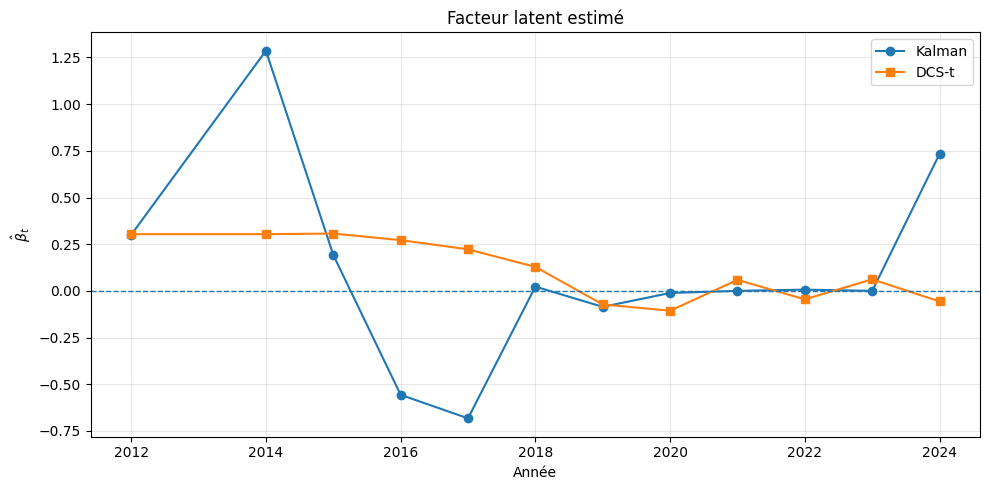

In [99]:


def inject_partial_same_sign_crisis(df, year_col="year", col="z",
                                   frac_years=0.4, frac_obs=0.7,
                                   magnitude=0.2, seed=42):
    df_out = df.copy()
    rng = np.random.default_rng(seed)
    years = df_out[year_col].unique()

    crisis_years = rng.choice(
        years,
        size=max(1, int(frac_years * len(years))),
        replace=False
    )

    for y in crisis_years:
        idx = df_out.index[df_out[year_col] == y].to_numpy()
        n_shock = max(1, int(frac_obs * len(idx)))
        chosen = rng.choice(idx, size=n_shock, replace=False)
        sign = rng.choice([-1, 1])
        df_out.loc[chosen, col] += sign * magnitude

    print("Années avec crise partielle :", crisis_years)
    return df_out, crisis_years


def run_full_wine_pipeline_shock(filepath):
    raw = load_wine_data(filepath)
    print("Dimensions brutes :", raw.shape)

    df = prepare_hedonic_dataset(raw, PRICE_COL, YEAR_COL, ID_COL, HEDONIC_VARS)
    print("Dimensions après nettoyage :", df.shape)

    hedonic_model = fit_hedonic_model(df, HEDONIC_VARS)
    print(hedonic_model.summary())

    df = add_hedonic_residuals(df, hedonic_model, HEDONIC_VARS)

# injecter outliers
    #df_out = inject_common_crisis(df, magnitude=0.8)
    df_out, crisis_years   =  inject_partial_same_sign_crisis(df, magnitude=1,seed=1)
# reconstruire panel
    Z_list, years, Nt_list = build_unbalanced_panel(df_out)
    print("initialisation kf params :", init_kf_params(Z_list))
    print("initialisation dcs params :", init_dcs_params(Z_list, nu_init=5.0))
    beta0=np.mean(Z_list[0])
    Q_hat, sv2_hat_kf, ok_kf, _ = mle_kf_gauss_unbalanced(Z_list,beta0=beta0, maxiter=MAXITER_KF)
    beta_kf = kf_filter_panel_gauss_unbalanced(Z_list, Q_hat, sv2_hat_kf)
    
    sv2_hat_dcs, kappa_hat, nu_hat, ok_dcs, _ = mle_dcs_t_unbalanced_multistart(Z_list,beta0=beta0 ,maxiter=MAXITER_DCS)
    beta_dcs = dcs_t_filter_panel_unbalanced(Z_list, sv2_hat_dcs, kappa_hat, nu_hat, beta0=beta0)

    return {
        "clean_df": df,
        "df_out": df_out,
        "crisis_years": crisis_years,
        "years": years,
        "Nt_list": Nt_list,
        "kf": {
            "Q_hat": Q_hat,
            "sigma_v2_hat": sv2_hat_kf,
            "beta_hat": beta_kf,
            "success": ok_kf
        },
        "dcs": {
            "sigma_v2_hat": sv2_hat_dcs,
            "kappa_hat": kappa_hat,
            "nu_hat": nu_hat,
            "beta_hat": beta_dcs,
            "success": ok_dcs
        }
    }


def plot_factors(results):
    years = results["years"]
    beta_kf = results["kf"]["beta_hat"]
    beta_dcs = results["dcs"]["beta_hat"]

    plt.figure(figsize=(10, 5))
    plt.plot(years, beta_kf, marker="o", label="Kalman")
    plt.plot(years, beta_dcs, marker="s", label="DCS-t")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Année")
    plt.ylabel(r"$\hat{\beta}_t$")
    plt.title("Facteur latent estimé")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    results_shock = run_full_wine_pipeline_shock(FILEPATH)
    print(results_shock["kf"])
    print(results_shock["dcs"])
    plot_factors(results_shock)

Dimensions brutes : (860, 26)
Dimensions après nettoyage : (860, 23)
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     22.22
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           9.25e-62
Time:                        18:58:25   Log-Likelihood:                -161.09
No. Observations:                 860   AIC:                             362.2
Df Residuals:                     840   BIC:                             457.3
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

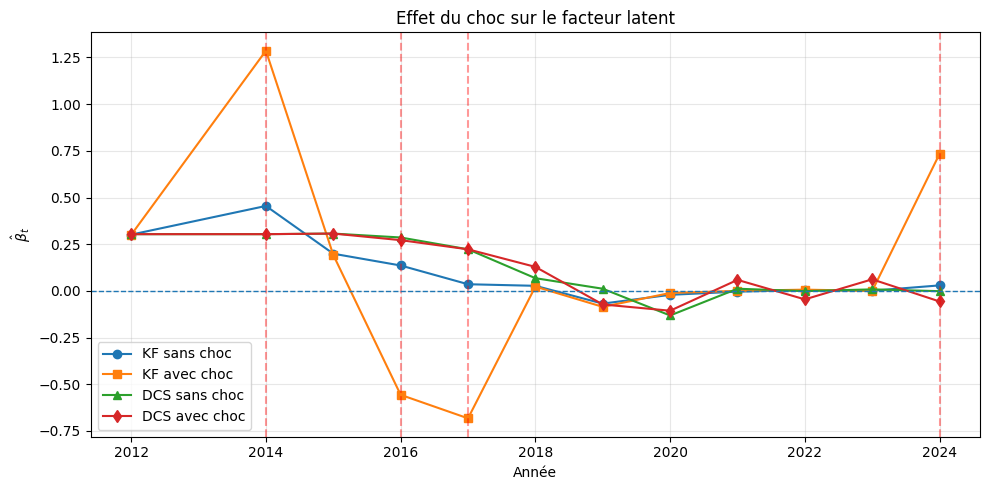

In [100]:


def compare_clean_vs_shock(results_clean, results_shock, crisis_years):
    years = results_clean["years"]

    beta_kf_clean = results_clean["kf"]["beta_hat"]
    beta_kf_shock = results_shock["kf"]["beta_hat"]

    beta_dcs_clean = results_clean["dcs"]["beta_hat"]
    beta_dcs_shock = results_shock["dcs"]["beta_hat"]

    plt.figure(figsize=(10, 5))

    plt.plot(years, beta_kf_clean, marker="o", label="KF sans choc")
    plt.plot(years, beta_kf_shock, marker="s", label="KF avec choc")

    plt.plot(years, beta_dcs_clean, marker="^", label="DCS sans choc")
    plt.plot(years, beta_dcs_shock, marker="d", label="DCS avec choc")

    # 🔥 Ajout des années de crise
    for y in crisis_years:
        plt.axvline(x=y, color='red', linestyle='--', alpha=0.4)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Année")
    plt.ylabel(r"$\hat{\beta}_t$")
    plt.title("Effet du choc sur le facteur latent")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


results_clean = run_full_wine_pipeline_clean(FILEPATH)
results_shock = run_full_wine_pipeline_shock(FILEPATH)
crisis_years = results_shock["crisis_years"]
compare_clean_vs_shock(results_clean, results_shock, crisis_years)
